# Milestone 4 — Final Modeling + Deliverables

**Canvas Project Number:** 36

---

## Notebook overview

This is the main MS4 notebook for the Short-Volatility Calendar Spread project. It runs end-to-end from raw data to the final EV-aware results.

- **Part I — Milestone 2: Data, target construction, and EDA.** Loads the calendar-spread CSV, handles missing values, reconstructs the canonical *quarter-spread* P&L target, performs exploratory analysis, and exports the model-ready dataset.
- **Part II — Milestone 3: Modeling pipeline.** Chronological train/val/test splits, baseline (Logistic Regression) and tree (LightGBM) models, three neural networks (MLP, MLP+Embeddings, Two-Stream GRU), rank ensembles, and a worst-case execution stress test.
- **Part III — Milestone 4: Interpretability and EV-aware pipeline.** LightGBM feature importance, a magnitude-weighted classifier, a loss-avoider model, and a 7-ranker × 3-scenario sensitivity grid that evaluates expected value per trade under realistic execution assumptions with validation-tuned cutoffs.

## Reproducibility

- Restart kernel + Run All should succeed top-to-bottom on a Colab GPU runtime.
- Required libraries are installed in the first code cell. The data file `calendar_spread_model_ready_raw.csv` is read from a Google Drive path; adjust that path if running locally.
- Random seed is fixed at `SEED = 42` for NumPy, Python `random`, and TensorFlow.


# Part I — Data, Target Construction, and EDA

This part loads the options calendar-spread dataset, handles missing values, reconstructs the canonical quarter-spread P&L target, performs exploratory analysis, and exports the model-ready dataset used by Part II. The "quarter-spread" assumption models a patient retail trader who works limit orders and captures roughly the midpoint of each bid-ask, which is more realistic than the worst-case CSV target while remaining conservative enough to be defensible.


## Introduction and Motivation

Retail option trading has increased significantly since 2019 following the elimination of commissions by brokerages such as Charles Schwab and Robinhood. According to 2024 Options Clearing Corporation data, about 48 million options now trade each day, up from 3.6 million in 2008.

This surge in retail participation has increased demand for short-dated call options, often raising Implied Volatility (IV). Implied volatility is the market's best guess (derived from stock option prices) of how wildly a stock might swing in a given period. Higher IV means traders expect bigger stock price moves, so option premiums become more expensive. IV is usually quoted as an annualized percentage (%).

Research by Barclays (2020) suggests that for certain stocks, IV systematically exceeds Subsequent Realized Volatility (SRV), creating a Volatility Risk Premium (VRP). When IV overestimates realized movement, option sellers can potentially capture excess premium.

This project explores whether a neural network can systematically learn patterns in volatility term structure, liquidity, and order flow data to predict the profitability of **pre-earnings ATM call calendar spreads**. The strategy sells the near-term option (capturing IV crush post-earnings) and buys the far-term option (retaining vega exposure), entered the day before earnings and exited the day after.

The project is novel in that it combines:
- Earnings event data
- Millisecond-level option microstructure data
- Volatility term structure metrics (near vs. far IV)
- A neural network trained specifically for volatility mispricing classification

## Data: Acquisition, Description, Wrangling, and EDA

### A. Data Sources

| API | How It's Used |
|-----|---------------|
| Finnhub | Fetches quarterly earnings dates and times for stocks |
| VolVue | API for fetching historical volatility estimators (IV, RV, ...) |
| Theta Data | Downloads live and historical option prices, greeks, and implied volatility at millisecond-level intervals |
| Alpha Vantage | Gets historical daily OHLCV data for underlying stocks |

**Data Coverage:**
- 476 companies
- ~4 earnings events per year per company
- ~8 years of data (2018–2025)
- 9,119 total trade observations

---

### B. Column Descriptions

| # | Column | Description |
|---|--------|-------------|
| 1 | ticker | Stock symbol |
| 2 | entry_time | Trade entry timestamp (YYYY-MM-DD HH:MM:SS) |
| 3 | exit_time | Trade exit timestamp |
| 4 | earnings_release_date | Date company releases earnings |
| 5 | earnings_release_time | amc / bmo / dmh |
| 6 | stock_price | Underlying price at entry |
| 7 | strike | Strike price of both legs |
| 8 | expiry_near | Expiration date of near-term option |
| 9 | expiry_far | Expiration date of far-term option |
| 10 | dte_near | Days to expiration, near-term |
| 11 | dte_far | Days to expiration, far-term |
| 12 | iv_near | Implied volatility, near-term |
| 13 | iv_far | Implied volatility, far-term |
| 14 | iv_term_slope | (iv_far - iv_near) / (dte_far - dte_near) |
| 15 | iv_near_far_ratio | IV 30-day / IV 60-day |
| 16 | bid_ask_near | Bid-ask spread of near-term option (liquidity proxy) |
| 17 | bid_ask_far | Bid-ask spread of far-term option |
| 18 | iv_call_30_rank | 52-week rank of 30-day call IV |
| 19 | iv_hv_ratio_cc_perc | IV/HV ratio percentile (close-to-close HV) |
| 20 | iv_hv_ratio_yz_perc | IV/HV ratio percentile (Yang-Zhang HV) |
| 21 | iv_30_iv_60_skew_perc | Percentile of 30d/60d IV skew |
| 22 | vrp_z_score | Z-score of Volatility Risk Premium |
| 23 | pcr_oi_30_perc | Put-call ratio by open interest (52-week percentile) |
| 24 | pcr_v_30_perc | Put-call ratio by volume (52-week percentile) |
| 25 | delta_near | Delta of near-term option |
| 26 | delta_far | Delta of far-term option |
| 27 | theta_near | Theta (time decay) of near-term option |
| 28 | theta_far | Theta of far-term option |
| 29 | vega_near | Vega of near-term option |
| 30 | vega_far | Vega of far-term option |
| 31 | entry_cost | Total entry cost (far ask - near bid) |
| 32 | option_price_entry_near_bid | Near-term bid at entry |
| 33 | option_price_entry_far_ask | Far-term ask at entry |
| 34 | percent_profit_loss | **Target Y** — actual P&L from closing next day |
| 35 | exit_cost | USD received/paid at exit |
| 36 | option_price_exit_near_ask | Near-term ask at exit |
| 37 | option_price_exit_far_bid | Far-term bid at exit |

In [1]:
# ============================================================
# STEP 1: Imports, Data Loading, and Initial Inspection
# ============================================================

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial import distance
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Data
# Colab / Google Drive:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/CS1090B_final_del/calendar_spread_trades_20250806_141609 (1).csv"
# Local:
# path = 'calendar_spread_trades_20250806_141609.csv'
df = pd.read_csv(path)

# Convert Date Columns
date_cols = ['entry_time', 'exit_time', 'earnings_release_date', 'expiry_near', 'expiry_far']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Shape & Types
print('=== Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'File size: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

print('\n=== Column Dtypes ===')
print(df.dtypes)

print('\n=== First 3 Rows ===')
display(df.head(3))

print('\n=== Descriptive Statistics ===')
display(df.describe())

# Missing Values
print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
display(missing_df[missing_df['missing_count'] > 0])
print(f'\nTotal rows with at least one missing value: {df.isnull().any(axis=1).sum()}')
print(f'Total duplicate rows: {df.duplicated().sum()}')

# ── Unique Counts ────────────────────────────────────────────
print(f'\nUnique tickers: {df["ticker"].nunique()}')
print(f'Date range: {df["entry_time"].min().date()} to {df["entry_time"].max().date()}')
print(f'Earnings release times: {df["earnings_release_time"].value_counts().to_dict()}')

print('\n✅ Step 1 complete. Working dataframe: df')

Mounted at /content/drive
=== Shape ===
Rows: 9119, Columns: 37
File size: 3.50 MB

=== Column Dtypes ===
ticker                                 object
entry_time                     datetime64[ns]
exit_time                      datetime64[ns]
earnings_release_date          datetime64[ns]
earnings_release_time                  object
stock_price                           float64
strike                                  int64
expiry_near                    datetime64[ns]
expiry_far                     datetime64[ns]
dte_near                                int64
dte_far                                 int64
iv_near                               float64
iv_far                                float64
iv_term_slope                         float64
iv_near_far_ratio                     float64
bid_ask_near                          float64
bid_ask_far                           float64
iv_call_30_rank                       float64
iv_hv_ratio_cc_perc                   float64
iv_hv_ratio_yz_perc 

,ticker,entry_time,exit_time,earnings_release_date,earnings_release_time,stock_price,strike,expiry_near,expiry_far,dte_near,...,theta_far,vega_near,vega_far,entry_cost,option_price_entry_near_bid,option_price_entry_far_ask,percent_profit_loss,exit_cost,option_price_exit_near_ask,option_price_exit_far_bid
0,A,2018-11-19 15:45:00,2018-11-20 12:00:00,2018-11-19,amc,62.50,60000,2018-12-21,2019-01-18,32,...,-0.0253,6.6125,9.2287,0.70,3.95,4.65,-1.0000,0.00,8.15,8.15
1,A,2019-02-20 15:45:00,2019-02-21 12:00:00,2019-02-20,amc,78.71,80000,2019-03-15,2019-04-18,23,...,-0.0286,7.6156,12.2545,0.72,1.85,2.57,0.0833,0.78,0.97,1.75
2,A,2019-11-25 15:45:00,2019-11-26 12:00:00,2019-11-25,amc,80.32,80000,2019-12-20,2020-01-17,25,...,-0.0291,8.3399,12.1309,0.66,2.59,3.25,0.0455,0.69,1.63,2.32



=== Descriptive Statistics ===


,entry_time,exit_time,earnings_release_date,stock_price,strike,expiry_near,expiry_far,dte_near,dte_far,iv_near,...,theta_far,vega_near,vega_far,entry_cost,option_price_entry_near_bid,option_price_entry_far_ask,percent_profit_loss,exit_cost,option_price_exit_near_ask,option_price_exit_far_bid
count,9119,9119,9119,9119.000000,9.119000e+03,9119,9119,9119.000000,9119.000000,9119.000000,...,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000
mean,2022-01-19 09:39:35.490734080,2022-01-20 07:37:51.959644672,2022-01-19 08:29:34.931461632,165.952608,1.659871e+05,2022-02-14 08:05:06.349380352,2022-03-13 03:38:14.067331840,26.590635,53.405308,0.373365,...,-0.082182,17.532635,24.878647,2.578951,6.197368,8.776319,-0.717857,0.841690,7.177600,8.019289
min,2018-05-22 15:45:00,2018-05-23 12:00:00,2018-05-22 00:00:00,1.880000,2.000000e+03,2018-06-15 00:00:00,2018-07-13 00:00:00,4.000000,35.000000,0.000000,...,-2.571600,0.000000,0.227800,0.020000,0.000000,0.020000,-71.833300,-8.600000,0.020000,0.000000
25%,2020-05-07 15:45:00,2020-05-08 12:00:00,2020-05-07 00:00:00,51.940000,5.000000e+04,2020-06-19 00:00:00,2020-07-17 00:00:00,22.000000,49.000000,0.266350,...,-0.092700,5.154350,7.477000,0.690000,1.680000,2.500000,-0.925900,0.050000,1.300000,1.650000
50%,2022-02-02 15:45:00,2022-02-03 12:00:00,2022-02-02 00:00:00,100.440000,1.000000e+05,2022-03-04 00:00:00,2022-03-18 00:00:00,29.000000,52.000000,0.334400,...,-0.046100,10.084900,14.803000,1.400000,3.450000,5.000000,-0.588200,0.410000,3.200000,3.700000
75%,2023-10-25 15:45:00,2023-10-26 12:00:00,2023-10-25 00:00:00,195.425000,1.950000e+05,2023-11-17 00:00:00,2023-12-15 00:00:00,31.000000,58.000000,0.433650,...,-0.022900,20.484600,29.498400,3.000000,6.925000,9.900000,-0.333300,1.165000,7.200000,8.225000
max,2025-05-22 15:45:00,2025-05-23 12:00:00,2025-05-22 00:00:00,4899.500000,4.900000e+06,2025-06-20 00:00:00,2025-07-18 00:00:00,45.000000,79.000000,3.269600,...,-0.000600,567.456000,733.187100,59.200000,208.200000,260.400000,0.928600,49.300000,383.100000,386.050000
std,NaN,NaN,NaN,250.027429,2.500241e+05,NaN,NaN,6.439834,8.627633,0.173742,...,0.134336,27.701825,37.334073,3.794420,10.255404,13.653845,0.974779,2.300655,15.078601,15.981536



=== Missing Values ===


,missing_count,missing_%
iv_call_30_rank,48,0.53
iv_hv_ratio_cc_perc,78,0.86
iv_hv_ratio_yz_perc,78,0.86
iv_30_iv_60_skew_perc,52,0.57
vrp_z_score,128,1.40
pcr_oi_30_perc,3,0.03
pcr_v_30_perc,231,2.53



Total rows with at least one missing value: 341
Total duplicate rows: 0

Unique tickers: 476
Date range: 2018-05-22 to 2025-05-22
Earnings release times: {'bmo': 4919, 'amc': 4172, 'dmh': 28}

✅ Step 1 complete. Working dataframe: df


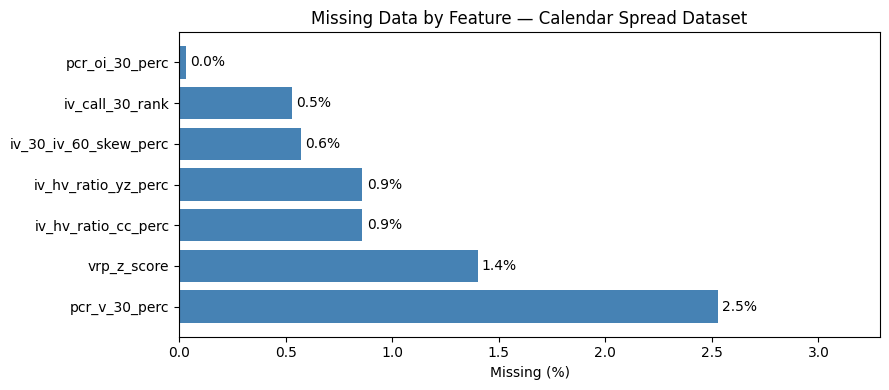

=== Missingness Timing Check ===
Mean entry_time — rows WITH missing:    2021-05-08
Mean entry_time — rows WITHOUT missing: 2022-01-29
→ Rows with missing values skew earlier in time: confirmed MAR.

Remaining missing values after imputation: 0
All missing values resolved.


In [2]:
# STEP 2: Missing Data Handling

# Visualize Missingness
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_pct
}).query('missing_count > 0').sort_values('missing_%', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df.index, missing_df['missing_%'], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature — Calendar Spread Dataset')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlim(0, missing_df['missing_%'].max() * 1.3)
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150)
plt.show()

# Diagnose Missingness Pattern
# All missing features are rolling-window percentile/rank metrics
# (252-day or 52-week lookback). Rows missing these values are
# concentrated at the START of each ticker's history — not enough
# historical data yet to compute the rolling window.
# This is Missing At Random (MAR): missingness depends on observable
# data (early entry_time), not on the missing value itself.

print('=== Missingness Timing Check ===')
mask = df.isnull().any(axis=1)
print(f'Mean entry_time — rows WITH missing:    {df.loc[mask, "entry_time"].mean().date()}')
print(f'Mean entry_time — rows WITHOUT missing: {df.loc[~mask, "entry_time"].mean().date()}')
print('→ Rows with missing values skew earlier in time: confirmed MAR.')

# Imputation: Ticker-Grouped Median
# All missing columns are percentile/rank features (bounded 0-100).
# Strategy: median imputation grouped by ticker.
# This respects cross-sectional variation — a high-IV stock
# should be imputed with its own median, not the global median.
# Fallback to global median for tickers with only 1 row.

cols_to_impute = [
    'iv_call_30_rank',
    'iv_hv_ratio_cc_perc',
    'iv_hv_ratio_yz_perc',
    'iv_30_iv_60_skew_perc',
    'vrp_z_score',
    'pcr_oi_30_perc',
    'pcr_v_30_perc'
]

# Only impute columns that actually have missing values
cols_to_impute = [c for c in cols_to_impute if c in df.columns and df[c].isnull().sum() > 0]

df[cols_to_impute] = df.groupby('ticker')[cols_to_impute].transform(
    lambda x: x.fillna(x.median())
)
for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

remaining = df.isnull().sum().sum()
print(f'\nRemaining missing values after imputation: {remaining}')
assert remaining == 0, 'Still have missing values!'
print('All missing values resolved.')

First trade: 2018-05-22
Last trade:  2025-05-22
✅ Sorted chronologically.
=== Class Distribution ===
Profitable:    161  (1.8%)
Unprofitable:  8,958  (98.2%)
Imbalance ratio: 55.6:1


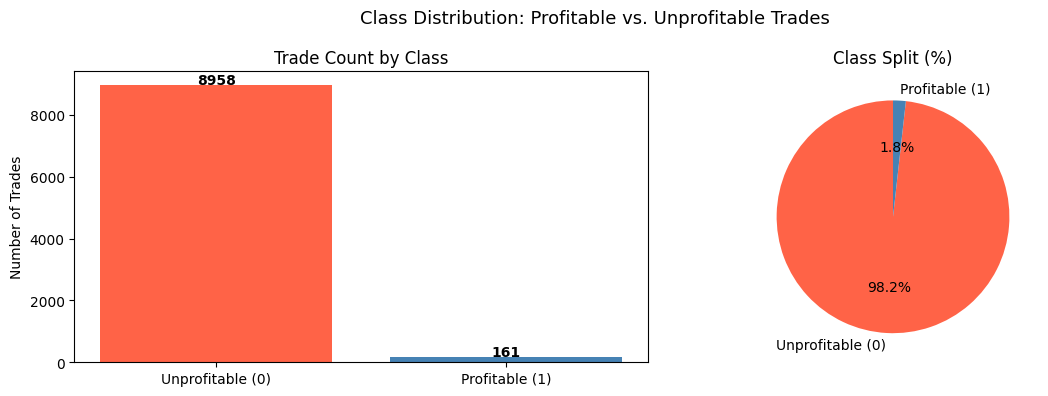


=== Feature Comparison (worst-case target): Profitable vs Unprofitable ===


,Profitable (n=161),"Unprofitable (n=8,958)",Difference
iv_call_30_rank,55.7784,47.3638,8.4146
dte_near,27.5714,26.5730,0.9984
bid_ask_far,0.2406,0.8031,-0.5625
bid_ask_near,0.2460,0.8050,-0.5590
entry_cost,2.7953,2.5751,0.2202
vrp_z_score,0.7875,0.6623,0.1252
iv_near,0.4438,0.3721,0.0717
iv_near_far_ratio,1.1811,1.1313,0.0498
iv_far,0.3759,0.3314,0.0445
iv_term_slope,-0.0023,-0.0015,-0.0008



Key Findings (worst-case baseline, 161/9119 = 1.77% positive):
  -> bid_ask_near/far: markedly LOWER in profitable trades. Under
     worst-case pricing this is partly an artifact (trades with tight
     spreads pay less bid-ask tax) and partly real liquidity signal.
  -> iv_call_30_rank: higher in profitable trades -- elevated IV
     regime favors IV crush post-earnings.
  -> vrp_z_score, iv_near_far_ratio: directionally match the thesis.
  -> Imbalance of 56:1 is extreme and motivates
     the repricing done in Step 3B-alt.



In [3]:
# STEP 3: Core Preprocessing


# 3A: Sort by Entry Time
# Prevents future data leaking into earlier rows during
# train/test splits. Non-negotiable for financial time series.

df = df.sort_values('entry_time').reset_index(drop=True)
print(f'First trade: {df["entry_time"].iloc[0].date()}')
print(f'Last trade:  {df["entry_time"].iloc[-1].date()}')
print('✅ Sorted chronologically.')

# 3B: Binary Target Label
df['profitable'] = (df['percent_profit_loss'] > 0).astype(int)

print('=== Class Distribution ===')
class_counts = df['profitable'].value_counts()
print(f"Profitable:    {class_counts.get(1,0):,}  ({class_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"Unprofitable:  {class_counts.get(0,0):,}  ({class_counts.get(0,0)/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {class_counts.get(0,0)/class_counts.get(1,1):.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution: Profitable vs. Unprofitable Trades', fontsize=13)
axes[0].bar(['Unprofitable (0)', 'Profitable (1)'],
            class_counts.values, color=['tomato', 'steelblue'])
axes[0].set_ylabel('Number of Trades')
axes[0].set_title('Trade Count by Class')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].pie(class_counts.values,
            labels=['Unprofitable (0)', 'Profitable (1)'],
            autopct='%1.1f%%',
            colors=['tomato', 'steelblue'], startangle=90)
axes[1].set_title('Class Split (%)')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# DIAGNOSTIC: Feature signal check (worst-case pricing baseline)
# NOTE: This uses the original CSV target. In Step 3B-alt we swap to
# a half-spread target; signal separation gets noticeably stronger
# under that target -- see the `r vs half` column there.
compare_cols = [
    'iv_near', 'iv_far', 'iv_term_slope', 'iv_near_far_ratio',
    'vrp_z_score', 'bid_ask_near', 'bid_ask_far',
    'dte_near', 'entry_cost', 'iv_call_30_rank'
]
n_pos = int((df['profitable'] == 1).sum())
n_neg = int((df['profitable'] == 0).sum())
col_pos = f'Profitable (n={n_pos:,})'
col_neg = f'Unprofitable (n={n_neg:,})'
comparison = pd.DataFrame({
    col_pos: df[df['profitable']==1][compare_cols].mean(),
    col_neg: df[df['profitable']==0][compare_cols].mean(),
}).round(4)
comparison['Difference'] = (comparison[col_pos] - comparison[col_neg]).round(4)
comparison = comparison.reindex(
    comparison['Difference'].abs().sort_values(ascending=False).index
)
print('\n=== Feature Comparison (worst-case target): Profitable vs Unprofitable ===')
display(comparison)

print(f"""
Key Findings (worst-case baseline, {n_pos}/{n_pos+n_neg} = {n_pos/(n_pos+n_neg)*100:.2f}% positive):
  -> bid_ask_near/far: markedly LOWER in profitable trades. Under
     worst-case pricing this is partly an artifact (trades with tight
     spreads pay less bid-ask tax) and partly real liquidity signal.
  -> iv_call_30_rank: higher in profitable trades -- elevated IV
     regime favors IV crush post-earnings.
  -> vrp_z_score, iv_near_far_ratio: directionally match the thesis.
  -> Imbalance of {n_neg/max(n_pos,1):.0f}:1 is extreme and motivates
     the repricing done in Step 3B-alt.
""")


## Step 3B-alt: Mid-Price P&L Reconstruction

The CSV target `percent_profit_loss` is computed with worst-case quotes on every leg:

| Moment  | Formula                | Meaning                                  |
|---------|------------------------|------------------------------------------|
| Entry   | `far_ask - near_bid`   | Buy far at **ask**, sell near at **bid** |
| Exit    | `far_bid - near_ask`   | Sell far at **bid**, buy near at **ask** |

So every trade pays the full bid-ask spread on all four crossings. That is why the CSV shows a **1.8% win rate and a median loss of -59%** — it is the P&L of a market-order round-trip into the worst available quotes, not the P&L of the strategy itself.

This section reconstructs two more realistic pricing variants and shows how they change the target distribution, class balance, and feature-target correlations.

- **Mid-to-mid**: zero slippage, both legs filled at the midpoint. Theoretical upper bound.
- **Half-spread (25% slip)**: both legs filled halfway between mid and the bad side. Realistic for a patient retail trader using limit orders.

Exit-leg bid-ask spreads are not in the CSV, so we assume the spread at exit is close to the spread at entry (one-day holding period, same underlying, similar liquidity regime).

=== Target distribution under three pricing assumptions ===


,Formula,n,Median %P&L,Mean %P&L,Win rate %,Imbalance
Variant,,,,,,
Worst-case (CSV),(far_bid_exit - near_ask_exit) - (far_ask_entry - near_bid_entry),9119,-0.5882,-0.7179,1.77,55.6 : 1
Quarter-spread (aggressive limit),worst_case_pnl + 3 * (bid_ask_near + bid_ask_far) / 4,8968,-0.1905,-0.3509,23.22,3.3 : 1
Mid-to-mid (theoretical),worst_case_pnl + (bid_ask_near + bid_ask_far),8760,-0.0000,-0.1146,45.27,1.2 : 1



Dropped 359 rows (3.9%) from mid variant (entry_cost_mid <= $0.1).
Dropped 151 rows (1.7%) from quarter-spread variant.


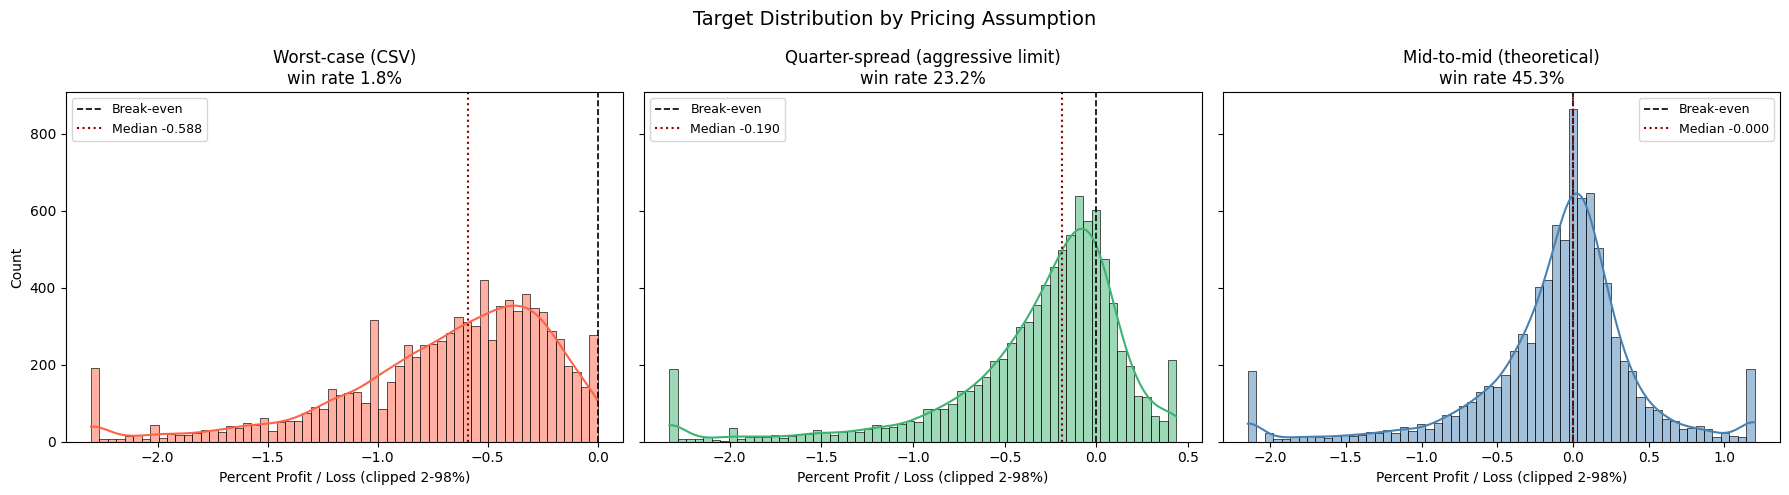


=== Feature-target Pearson r by pricing variant ===


,r vs worst,r vs quarter,r vs mid,|quarter| - |worst|
delta_near,-0.035,-0.068,-0.036,0.033
iv_near_far_ratio,-0.066,0.067,0.107,0.001
dte_near,-0.067,-0.050,-0.018,-0.017
bid_ask_far,-0.099,-0.033,0.069,-0.066
iv_call_30_rank,0.028,0.033,0.023,0.005
iv_term_slope,0.075,-0.033,-0.079,-0.042
iv_near,0.001,0.026,0.028,0.025
bid_ask_near,-0.099,-0.019,0.076,-0.080
iv_far,0.007,0.006,0.004,-0.001
vrp_z_score,-0.006,-0.002,-0.013,-0.004



Interpretation:
  -> Worst-case target squashes signal: almost every row loses ~55%
     regardless of features, so Pearson r is suppressed toward zero.
  -> Quarter-spread is the active execution assumption for MS2. It should
     reveal more executable signal than worst-case pricing while remaining
     materially below the frictionless mid-to-mid benchmark.
  -> Mid-to-mid is a near coin-flip (45% win rate, median ~= 0). That is
     what an efficient market predicts: the strategy captures IV crush
     but pays it back through vega/delta risk, ending at fair value.

=== Target swap committed ===
Rows dropped (entry debit <= $0.10 at quarter-spread): 151
Working dataframe: 8968 rows
New class balance:  profitable=2,082  unprofitable=6,886  (23.22% positive)
New imbalance ratio: 3.3 : 1

Canonical columns now use quarter-spread pricing:
  df['percent_profit_loss']   <- percent_profit_loss_quarter
  df['profitable']            <- profitable_quarter

Worst-case series retained for str

In [4]:
# ============================================================
# STEP 3B-alt: Quarter-spread P&L reconstruction
# ============================================================
#
# Worst-case (in CSV):
#   entry_cost      = far_ask_entry - near_bid_entry
#   exit_cost       = far_bid_exit  - near_ask_exit
#
# We have entry-side bid_ask_near / bid_ask_far, so we can back out
# the missing halves of the entry quote:
#   entry_cost_mid  = entry_cost - (bid_ask_near + bid_ask_far) / 2
#
# Exit-side spreads aren't recorded. For a one-day hold on the same
# underlying we assume spread_exit ~= spread_entry:
#   exit_cost_mid   = exit_cost  + (bid_ask_near + bid_ask_far) / 2
#
# Quarter-spread is the active execution assumption in MS2: an aggressive
# limit-order trader captures three quarters of the full bid-ask improvement
# from worst-case toward mid-to-mid, leaving only one quarter of the full
# round-trip bid-ask friction.
#   entry_cost_quarter = entry_cost - 3 * (bid_ask_near + bid_ask_far) / 8
#   exit_cost_quarter  = exit_cost  + 3 * (bid_ask_near + bid_ask_far) / 8

total_spread = df['bid_ask_near'] + df['bid_ask_far']

# Dollar P&L under each assumption
entry_cost_mid  = df['entry_cost'] - total_spread / 2
exit_cost_mid   = (df['option_price_exit_far_bid']
                   - df['option_price_exit_near_ask']) + total_spread / 2
dollar_pnl_mid  = exit_cost_mid - entry_cost_mid

entry_cost_quarter = df['entry_cost'] - 3 * total_spread / 8
exit_cost_quarter  = (df['option_price_exit_far_bid']
                      - df['option_price_exit_near_ask']) + 3 * total_spread / 8
dollar_pnl_quarter = exit_cost_quarter - entry_cost_quarter

# Percent P&L. Denominator can be <= 0 under the mid/quarter assumptions
# (wider spread than the debit itself). Mark those as NaN to keep them
# out of distribution stats.
MIN_COST = 0.10  # $0.10 floor; below this, percentage becomes nonsense

mid_valid     = entry_cost_mid     > MIN_COST
quarter_valid = entry_cost_quarter > MIN_COST

df['percent_profit_loss_mid'] = np.where(
    mid_valid, dollar_pnl_mid / entry_cost_mid.replace(0, np.nan), np.nan)
df['percent_profit_loss_quarter'] = np.where(
    quarter_valid, dollar_pnl_quarter / entry_cost_quarter.replace(0, np.nan), np.nan)

# Binary targets
df['profitable_mid']     = (df['percent_profit_loss_mid']     > 0).astype('Int64')
df['profitable_quarter'] = (df['percent_profit_loss_quarter'] > 0).astype('Int64')

# ---- Comparison table across the three pricing variants ---------
# Each variant differs only in how it prices the four quote crossings.
# The 'Formula' column below is the dollar-P&L formula used to build
# the corresponding percent_profit_loss_* column above.
variants = {
    'Worst-case (CSV)': {
        'pnl_col':  'percent_profit_loss',
        'bin_col':  'profitable',
        'formula':  '(far_bid_exit - near_ask_exit) - (far_ask_entry - near_bid_entry)',
    },
    'Quarter-spread (aggressive limit)': {
        'pnl_col':  'percent_profit_loss_quarter',
        'bin_col':  'profitable_quarter',
        'formula':  'worst_case_pnl + 3 * (bid_ask_near + bid_ask_far) / 4',
    },
    'Mid-to-mid (theoretical)': {
        'pnl_col':  'percent_profit_loss_mid',
        'bin_col':  'profitable_mid',
        'formula':  'worst_case_pnl + (bid_ask_near + bid_ask_far)',
    },
}

summary_rows = []
for name, spec in variants.items():
    s = df[spec['pnl_col']].dropna()
    wins = (s > 0).sum()
    losses = (s <= 0).sum()
    summary_rows.append({
        'Variant':      name,
        'Formula':      spec['formula'],
        'n':            int(len(s)),
        'Median %P&L':  round(s.median(), 4),
        'Mean %P&L':    round(s.mean(), 4),
        'Win rate %':   round((s > 0).mean() * 100, 2),
        'Imbalance':    f'{losses / max(wins, 1):.1f} : 1',
    })
summary = pd.DataFrame(summary_rows).set_index('Variant')
with pd.option_context('display.max_colwidth', None):
    print('=== Target distribution under three pricing assumptions ===')
    display(summary)

# Rows we had to drop from the more optimistic variants
dropped_mid = (~mid_valid).sum()
dropped_quarter = (~quarter_valid).sum()
print(f'\nDropped {dropped_mid} rows ({dropped_mid/len(df)*100:.1f}%) from mid '
      f'variant (entry_cost_mid <= ${MIN_COST}).')
print(f'Dropped {dropped_quarter} rows ({dropped_quarter/len(df)*100:.1f}%) from '
      f'quarter-spread variant.')

# ---- Side-by-side distributions ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Target Distribution by Pricing Assumption', fontsize=14)

plot_specs = [
    (axes[0], df['percent_profit_loss'],          'Worst-case (CSV)',                  'tomato'),
    (axes[1], df['percent_profit_loss_quarter'],  'Quarter-spread (aggressive limit)', 'mediumseagreen'),
    (axes[2], df['percent_profit_loss_mid'],      'Mid-to-mid (theoretical)',          'steelblue'),
]
for ax, s, title, color in plot_specs:
    s = s.dropna()
    lo, hi = s.quantile([0.02, 0.98])
    sns.histplot(s.clip(lo, hi), bins=60, kde=True, ax=ax, color=color)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Break-even')
    ax.axvline(s.median(), color='darkred', linestyle=':', linewidth=1.5,
               label=f'Median {s.median():.3f}')
    ax.set_title(f'{title}\nwin rate {(s>0).mean()*100:.1f}%')
    ax.set_xlabel('Percent Profit / Loss (clipped 2-98%)')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pnl_by_pricing_assumption.png', dpi=150)
plt.show()

# ---- Feature correlation: does a cleaner target sharpen signal? --
signal_feats = [
    'iv_near', 'iv_far', 'iv_term_slope', 'iv_near_far_ratio',
    'vrp_z_score', 'bid_ask_near', 'bid_ask_far', 'iv_call_30_rank',
    'dte_near', 'delta_near',
]
corr_compare = pd.DataFrame({
    'r vs worst':   df[signal_feats].corrwith(df['percent_profit_loss']),
    'r vs quarter': df[signal_feats].corrwith(df['percent_profit_loss_quarter']),
    'r vs mid':     df[signal_feats].corrwith(df['percent_profit_loss_mid']),
}).round(3)
corr_compare['|quarter| - |worst|'] = (
    corr_compare['r vs quarter'].abs() - corr_compare['r vs worst'].abs()
).round(3)
corr_compare = corr_compare.reindex(
    corr_compare['r vs quarter'].abs().sort_values(ascending=False).index)

print('\n=== Feature-target Pearson r by pricing variant ===')
display(corr_compare)

print("""
Interpretation:
  -> Worst-case target squashes signal: almost every row loses ~55%
     regardless of features, so Pearson r is suppressed toward zero.
  -> Quarter-spread is the active execution assumption for MS2. It should
     reveal more executable signal than worst-case pricing while remaining
     materially below the frictionless mid-to-mid benchmark.
  -> Mid-to-mid is a near coin-flip (45% win rate, median ~= 0). That is
     what an efficient market predicts: the strategy captures IV crush
     but pays it back through vega/delta risk, ending at fair value.
""")

# ============================================================
# Commit: promote quarter-spread to the canonical target
# ============================================================
# Everything downstream (Step 4 class weights, Step 5 EDA, Step 6
# correlations, Step 7 export) reads `df['profitable']` and
# `df['percent_profit_loss']`. We swap those columns to point at the
# aggressive-limit quarter-spread variant and keep the worst-case series
# under a *_worst suffix so we can still run a stress-test report later.

rows_before = len(df)

# Archive worst-case series before overwriting
df['percent_profit_loss_worst'] = df['percent_profit_loss']
df['profitable_worst']          = df['profitable']

# Drop rows where the quarter-spread debit collapses below the $0.10 floor
# (these have unreliable % P&L under any realistic fill)
df = df.dropna(subset=['percent_profit_loss_quarter']).reset_index(drop=True)

# Promote quarter-spread to canonical
df['percent_profit_loss'] = df['percent_profit_loss_quarter']
df['profitable']          = df['profitable_quarter'].astype(int)

# Recompute class_counts so Step 4 (class weights) picks up the new target
class_counts = df['profitable'].value_counts()

rows_after = len(df)
print(f'=== Target swap committed ===')
print(f'Rows dropped (entry debit <= $0.10 at quarter-spread): '
      f'{rows_before - rows_after}')
print(f'Working dataframe: {rows_after} rows')
print(f'New class balance:  profitable={class_counts.get(1,0):,}  '
      f'unprofitable={class_counts.get(0,0):,}  '
      f'({class_counts.get(1,0)/rows_after*100:.2f}% positive)')
print(f'New imbalance ratio: '
      f'{class_counts.get(0,0) / max(class_counts.get(1,1),1):.1f} : 1')
print(f'\nCanonical columns now use quarter-spread pricing:')
print(f"  df['percent_profit_loss']   <- percent_profit_loss_quarter")
print(f"  df['profitable']            <- profitable_quarter")
print(f'\nWorst-case series retained for stress tests:')
print(f"  df['percent_profit_loss_worst'],  df['profitable_worst']")

In [5]:
# 3C: Normalize Strike Price
# Dividing by stock_price gives moneyness ratio (values near 1.0 = ATM).
# More principled than dividing by 1000 — comparable across all tickers
# regardless of stock price level (e.g., AMZN vs NVDA vs AAPL).

df['strike_normalized'] = df['strike'] / 1000 / df['stock_price']
print(f'\nstrike/stock — min: {df["strike_normalized"].min():.3f}, '
      f'max: {df["strike_normalized"].max():.3f}, '
      f'mean: {df["strike_normalized"].mean():.3f}')
print('→ Values near 1.0 = at-the-money, as expected.')

# 3D: Define Feature Matrix X
# EXCLUDED (outcome / leakage):
#   percent_profit_loss, exit_cost,
#   option_price_exit_near_ask, option_price_exit_far_bid
# EXCLUDED (execution cost, not signal):
#   entry_cost, option_price_entry_near_bid, option_price_entry_far_ask
# EXCLUDED (identifiers / non-numeric):
#   ticker, entry_time, exit_time, earnings_release_date,
#   expiry_near, expiry_far, earnings_release_time (encoded separately)
# EXCLUDED (replaced by normalized version):
#   strike (use strike_normalized instead)

feature_cols = [
    # Term structure
    'iv_near', 'iv_far', 'iv_term_slope', 'iv_near_far_ratio',
    # Expiry structure
    'dte_near', 'dte_far',
    # Liquidity
    'bid_ask_near', 'bid_ask_far',
    # VRP / IV rank signals
    'iv_call_30_rank', 'iv_hv_ratio_cc_perc', 'iv_hv_ratio_yz_perc',
    'iv_30_iv_60_skew_perc', 'vrp_z_score',
    # Order flow / sentiment
    'pcr_oi_30_perc', 'pcr_v_30_perc',
    # Greeks — near
    'delta_near', 'theta_near', 'vega_near',
    # Greeks — far
    'delta_far', 'theta_far', 'vega_far',
    # Moneyness
    'strike_normalized'
]

df_X = df[feature_cols].copy()
df_y = df['profitable'].copy()

print(f'\nFeature matrix shape: {df_X.shape}  ({df_X.shape[1]} features, {df_X.shape[0]} observations)')

# 3E: Standardize Features
# Z-score standardization for EDA visualization.
# In Milestone 3, scaler will be fit on training data only.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_X)
df_X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('\n=== Standardization Check (sample features) ===')
check = ['iv_near', 'vrp_z_score', 'strike_normalized', 'dte_near']
print(df_X_scaled[check].describe().loc[['mean', 'std']].round(4))
print('→ All means ≈ 0, all stds ≈ 1.')

print('\n=== Step 3 Summary ===')
print(f'  Total observations:  {len(df)}')
print(f'  Features:            {df_X.shape[1]}')
print(f'  Profitable trades:   {df_y.sum()} ({df_y.mean()*100:.1f}%)')
print(f'  Unprofitable trades: {(df_y==0).sum()} ({(df_y==0).mean()*100:.1f}%)')


strike/stock — min: 0.752, max: 1.567, mean: 1.000
→ Values near 1.0 = at-the-money, as expected.

Feature matrix shape: (8968, 22)  (22 features, 8968 observations)

=== Standardization Check (sample features) ===
      iv_near  vrp_z_score  strike_normalized  dte_near
mean   0.0000       0.0000             0.0000    0.0000
std    1.0001       1.0001             1.0001    1.0001
→ All means ≈ 0, all stds ≈ 1.

=== Step 3 Summary ===
  Total observations:  8968
  Features:            22
  Profitable trades:   2082 (23.2%)
  Unprofitable trades: 6886 (76.8%)


=== Class Imbalance Strategy: Weighted Loss ===
Imbalance ratio:       3.3:1
Class 0 weight:        0.6512
Class 1 weight:        2.1537

How to apply in Milestone 3:
  Keras:   model.fit(..., class_weight={0: np.float64(0.6511762997386), 1: np.float64(2.1536983669548513)})
  XGBoost: XGBClassifier(scale_pos_weight=3.3)
  PyTorch: BCEWithLogitsLoss(pos_weight=torch.tensor([3.3]))


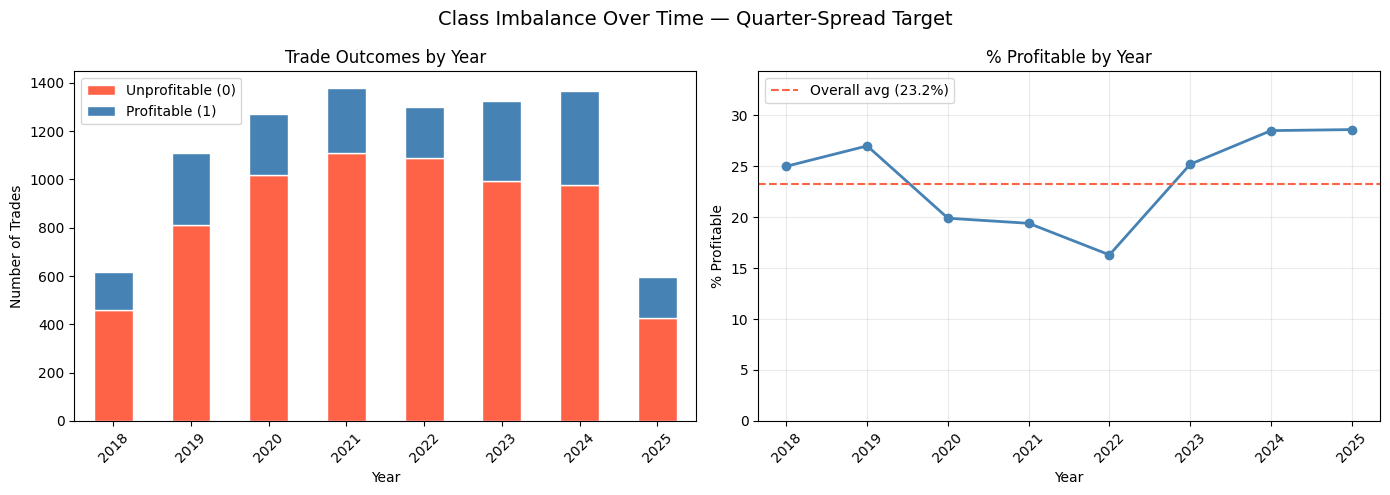

profitable,Unprofitable (0),Profitable (1),pct_profitable
year,,,
2018,461,154,25.0
2019,811,300,27.0
2020,1018,253,19.9
2021,1111,268,19.4
2022,1089,212,16.3
2023,993,334,25.2
2024,977,390,28.5
2025,426,171,28.6


Objects: class_weight_dict, scale_pos_weight


In [6]:
# STEP 4: Class Imbalance — Class Weights

# The canonical target here is `profitable_quarter` (aggressive-limit fill,
# see Step 3B-alt). We stay with class weights because they:
#   - use 100% real market data (no synthetic fabrication)
#   - are supported identically in Keras, XGBoost, PyTorch, sklearn
#   - scale cleanly if we later stress-test against worst-case pricing
# The figures below print using whichever target `df['profitable']`
# currently points at, so the cell is safe to re-run after any swap.

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['profitable']
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
scale_pos_weight = class_counts[0] / class_counts[1]

print('=== Class Imbalance Strategy: Weighted Loss ===')
print(f'Imbalance ratio:       {scale_pos_weight:.1f}:1')
print(f'Class 0 weight:        {class_weight_dict[0]:.4f}')
print(f'Class 1 weight:        {class_weight_dict[1]:.4f}')
print(f'\nHow to apply in Milestone 3:')
print(f'  Keras:   model.fit(..., class_weight={class_weight_dict})')
print(f'  XGBoost: XGBClassifier(scale_pos_weight={scale_pos_weight:.1f})')
print(f'  PyTorch: BCEWithLogitsLoss(pos_weight=torch.tensor([{scale_pos_weight:.1f}]))')

# Visualize imbalance over time
# Quarter-spread has a higher base rate than the earlier target, so use a
# dynamic y-axis instead of the old 0-20% cap.
df['year'] = df['entry_time'].dt.year
all_years = range(df['year'].min(), df['year'].max() + 1)
yearly = (df.groupby(['year', 'profitable']).size()
          .unstack(fill_value=0)
          .reindex(all_years, fill_value=0))
yearly = yearly.rename(columns={0: 'Unprofitable (0)', 1: 'Profitable (1)'})
for col in ['Unprofitable (0)', 'Profitable (1)']:
    if col not in yearly.columns:
        yearly[col] = 0
yearly = yearly[['Unprofitable (0)', 'Profitable (1)']]
yearly['pct_profitable'] = (
    yearly['Profitable (1)'] / yearly.sum(axis=1).replace(0, np.nan) * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance Over Time — Quarter-Spread Target', fontsize=14)
yearly[['Unprofitable (0)', 'Profitable (1)']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['tomato', 'steelblue'], edgecolor='white')
axes[0].set_title('Trade Outcomes by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Trades')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left')

axes[1].plot(yearly.index, yearly['pct_profitable'],
             marker='o', color='steelblue', linewidth=2)
overall_rate = df['profitable'].mean() * 100
axes[1].axhline(overall_rate, color='tomato', linestyle='--',
                label=f'Overall avg ({overall_rate:.1f}%)')
axes[1].set_title('% Profitable by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Profitable')
y_max = np.nanmax([yearly['pct_profitable'].max(), overall_rate])
axes[1].set_ylim(0, min(100, max(30, y_max * 1.2)))
axes[1].set_xticks(list(all_years))
axes[1].legend(loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig('imbalance_over_time.png', dpi=150)
plt.show()

display(yearly)
print('Objects: class_weight_dict, scale_pos_weight')

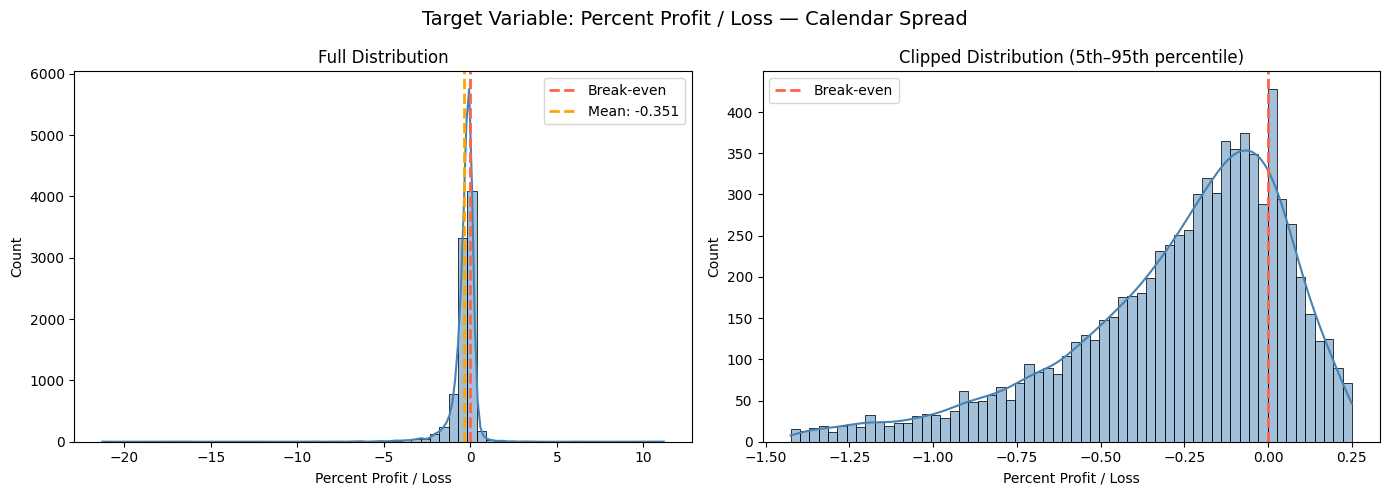

=== P&L Summary ===


,percent_profit_loss
count,8968.000000
mean,-0.350864
std,0.855313
min,-21.262570
25%,-0.476543
50%,-0.190476
75%,-0.008715
max,11.176471


Median P&L:           -0.1905
% Profitable:         23.2%
Avg profit (winners): 0.2077
Avg loss  (losers):   -0.5253


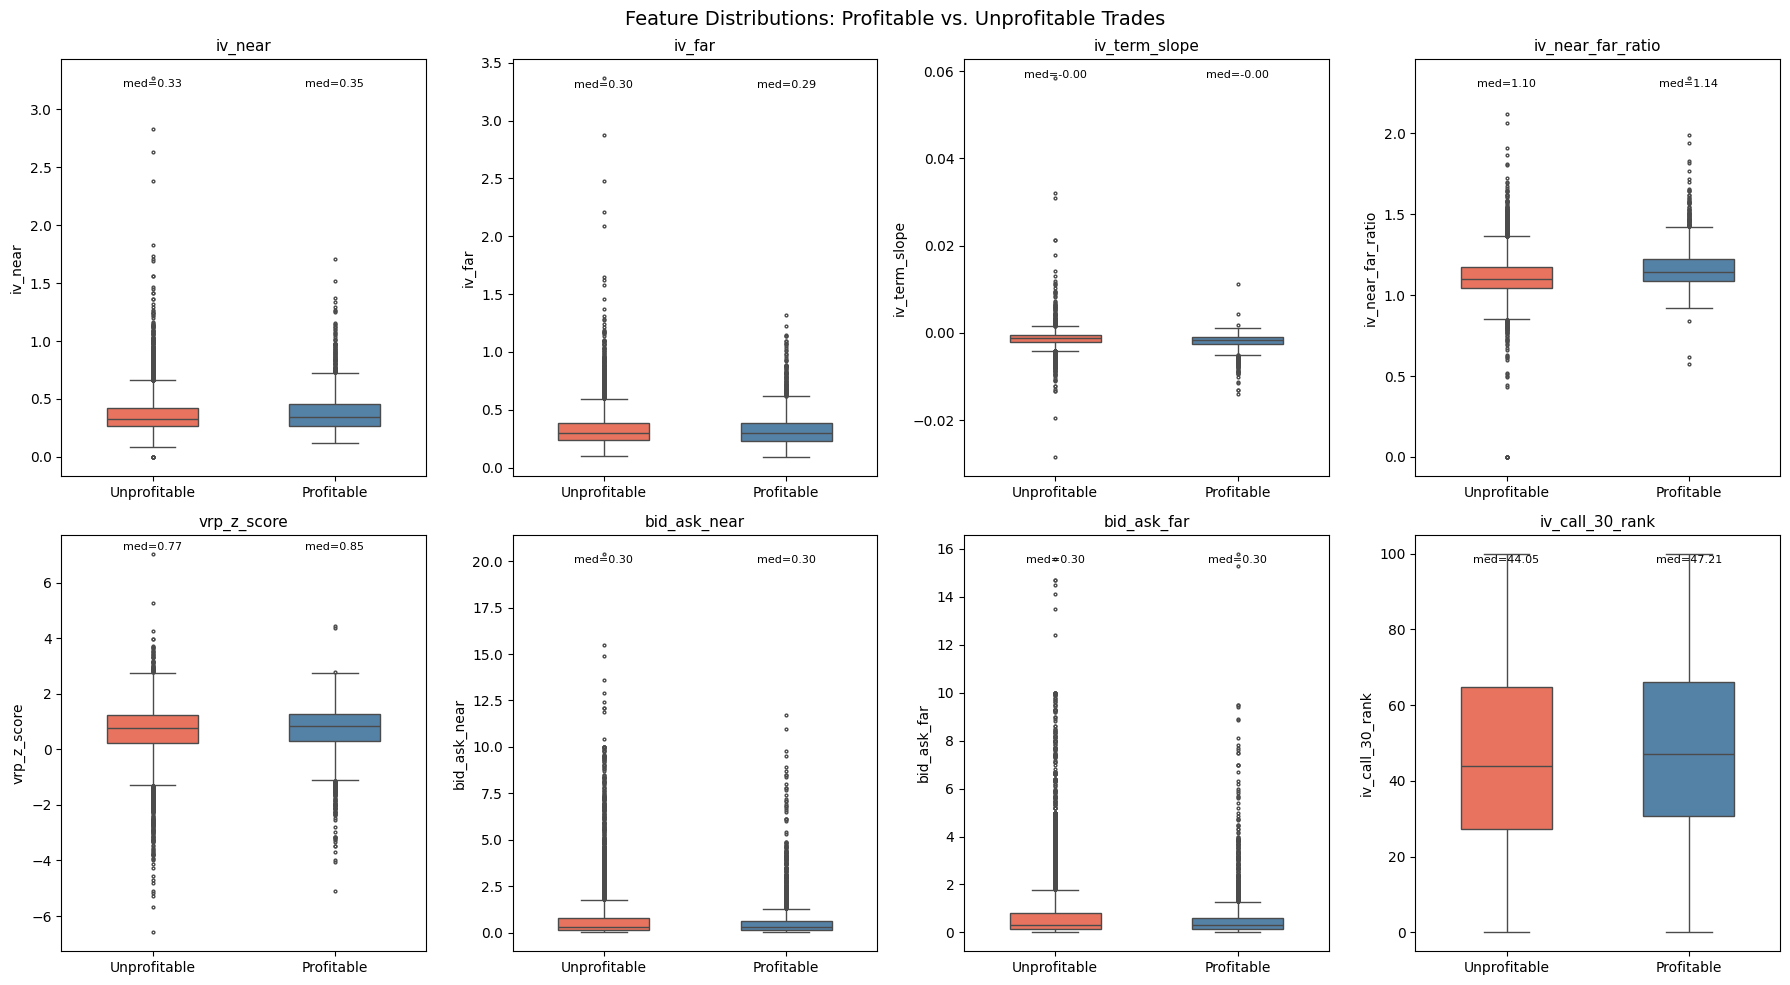

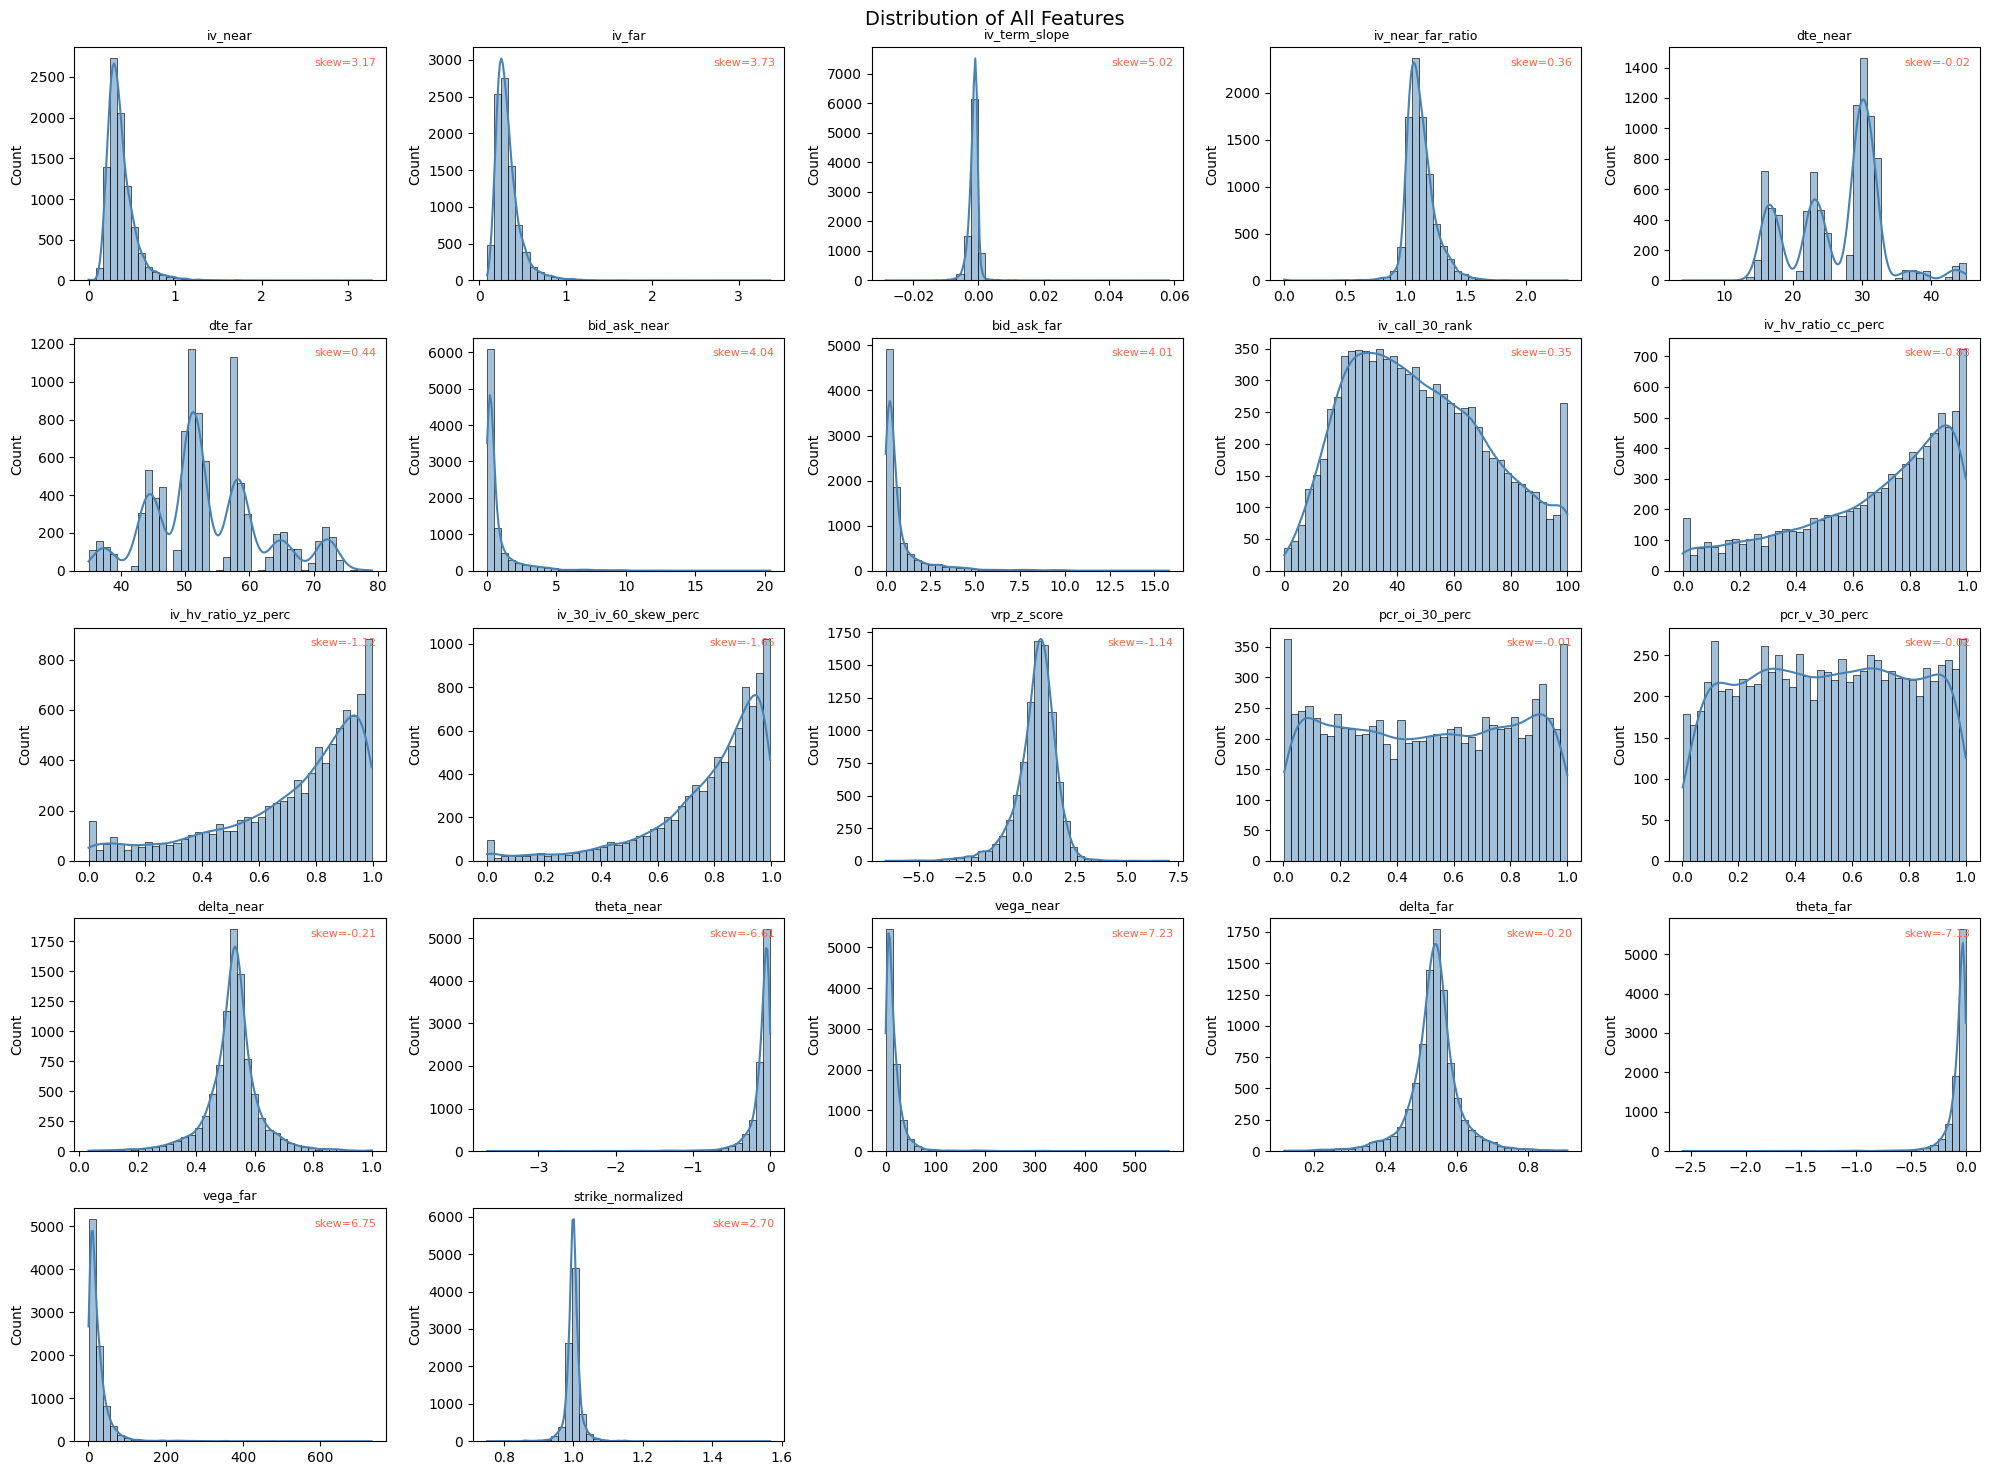

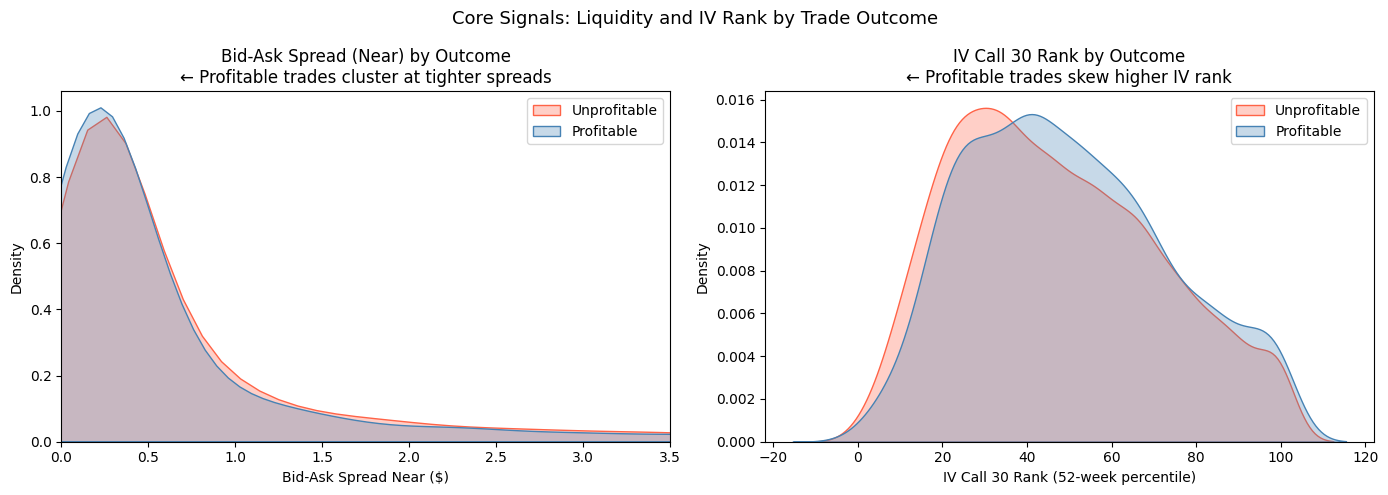

In [7]:

# STEP 5: EDA Visualizations

# 5A: Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable: Percent Profit / Loss — Calendar Spread', fontsize=14)

sns.histplot(data=df, x='percent_profit_loss', bins=60,
             kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='tomato', linestyle='--', linewidth=2, label='Break-even')
axes[0].axvline(df['percent_profit_loss'].mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Mean: {df["percent_profit_loss"].mean():.3f}')
axes[0].set_title('Full Distribution')
axes[0].set_xlabel('Percent Profit / Loss')
axes[0].set_ylabel('Count')
axes[0].legend()

# Clip to 5th–95th percentile for readable zoom
p5  = df['percent_profit_loss'].quantile(0.05)
p95 = df['percent_profit_loss'].quantile(0.95)
df_clipped = df[(df['percent_profit_loss'] >= p5) &
                (df['percent_profit_loss'] <= p95)]
sns.histplot(data=df_clipped, x='percent_profit_loss', bins=60,
             kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=2, label='Break-even')
axes[1].set_title('Clipped Distribution (5th–95th percentile)')
axes[1].set_xlabel('Percent Profit / Loss')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print('=== P&L Summary ===')
display(df['percent_profit_loss'].describe())
print(f'Median P&L:           {df["percent_profit_loss"].median():.4f}')
print(f'% Profitable:         {(df["percent_profit_loss"] > 0).mean()*100:.1f}%')
print(f'Avg profit (winners): {df.loc[df["percent_profit_loss"]>0, "percent_profit_loss"].mean():.4f}')
print(f'Avg loss  (losers):   {df.loc[df["percent_profit_loss"]<0, "percent_profit_loss"].mean():.4f}')


# 5B: Box Plots of Key Features by Class
features_to_plot = [
    'iv_near', 'iv_far', 'iv_term_slope', 'iv_near_far_ratio',
    'vrp_z_score', 'bid_ask_near', 'bid_ask_far', 'iv_call_30_rank'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Feature Distributions: Profitable vs. Unprofitable Trades', fontsize=14)
axes = axes.flatten()

# Add a string version of profitable for cleaner seaborn labeling
df['outcome'] = df['profitable'].map({0: 'Unprofitable', 1: 'Profitable'})

for i, feat in enumerate(features_to_plot):
    sns.boxplot(
        data=df, x='outcome', y=feat, ax=axes[i],
        hue='outcome',
        palette={'Unprofitable': 'tomato', 'Profitable': 'steelblue'},
        order=['Unprofitable', 'Profitable'],
        width=0.5, fliersize=2, legend=False
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
    for j, cls in enumerate(['Unprofitable', 'Profitable']):
        med = df[df['outcome'] == cls][feat].median()
        axes[i].text(j, axes[i].get_ylim()[1] * 0.93,
                     f'med={med:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150)
plt.show()

# ── 5C: Feature Histograms (skew check) ─────────────────────
n_cols = 5
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
fig.suptitle('Distribution of All Features', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    sns.histplot(data=df_X, x=feat, bins=40, ax=axes[i],
                 color='steelblue', kde=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].annotate(f'skew={df_X[feat].skew():.2f}',
                     xy=(0.97, 0.92), xycoords='axes fraction',
                     ha='right', fontsize=8, color='tomato')
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('feature_histograms.png', dpi=150)
plt.show()

# 5D: The Core Signal — Bid-Ask vs IV Rank
# The single most important EDA plot given Step 3 findings.
# Profitable trades cluster at LOW bid-ask + HIGH iv_call_30_rank.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Core Signals: Liquidity and IV Rank by Trade Outcome', fontsize=13)

# Bid-ask spread distribution by class
sns.kdeplot(data=df[df['profitable']==0], x='bid_ask_near',
            ax=axes[0], color='tomato', label='Unprofitable', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['profitable']==1], x='bid_ask_near',
            ax=axes[0], color='steelblue', label='Profitable', fill=True, alpha=0.3)
axes[0].set_title('Bid-Ask Spread (Near) by Outcome\n← Profitable trades cluster at tighter spreads')
axes[0].set_xlabel('Bid-Ask Spread Near ($)')
axes[0].set_xlim(0, df['bid_ask_near'].quantile(0.95))
axes[0].legend()

# IV rank distribution by class
sns.kdeplot(data=df[df['profitable']==0], x='iv_call_30_rank',
            ax=axes[1], color='tomato', label='Unprofitable', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['profitable']==1], x='iv_call_30_rank',
            ax=axes[1], color='steelblue', label='Profitable', fill=True, alpha=0.3)
axes[1].set_title('IV Call 30 Rank by Outcome\n← Profitable trades skew higher IV rank')
axes[1].set_xlabel('IV Call 30 Rank (52-week percentile)')
axes[1].legend()

plt.tight_layout()
plt.savefig('core_signals.png', dpi=150)
plt.show()

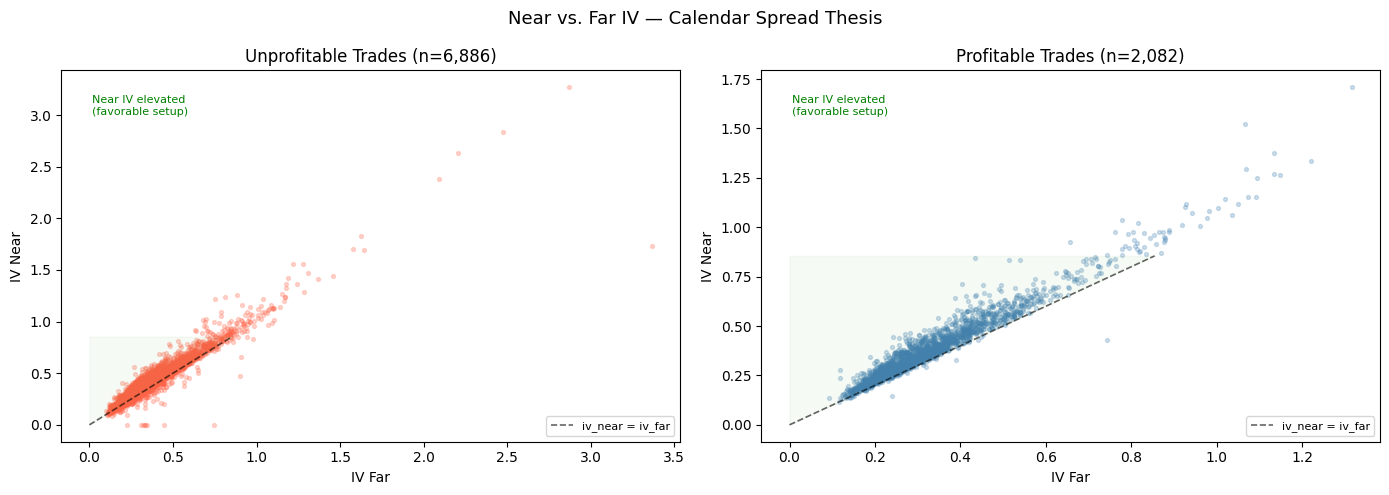

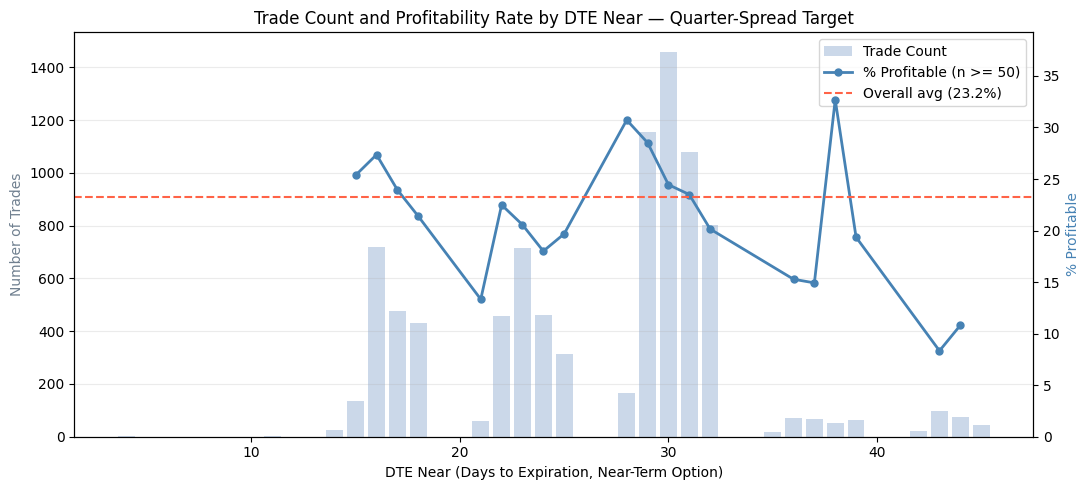

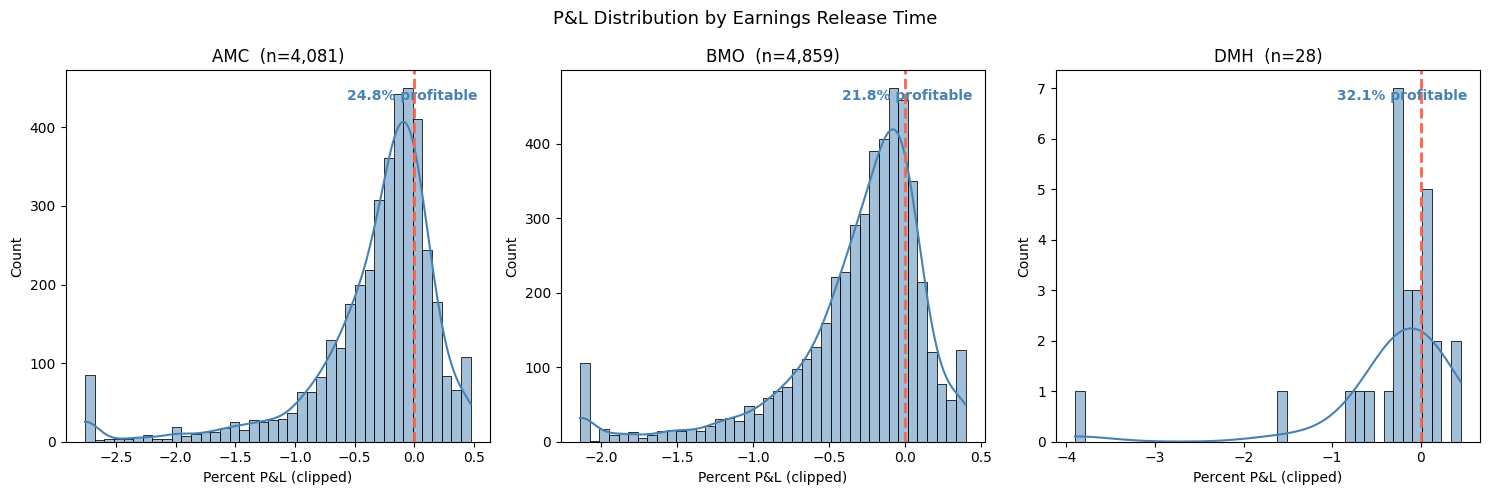

Saved: target_distribution.png, boxplots_by_class.png,
       feature_histograms.png, core_signals.png,
       iv_near_vs_far.png, profitability_by_dte.png,
       pnl_by_release_time.png


In [8]:
# 5E: Near vs Far IV — Calendar Spread Thesis Check
# The strategy profits when near IV > far IV (ratio > 1).
# Profitable trades should cluster above the diagonal.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Near vs. Far IV — Calendar Spread Thesis', fontsize=13)

for ax, (cls, color, label) in zip(
    axes,
    [(0, 'tomato', 'Unprofitable'), (1, 'steelblue', 'Profitable')]):
    subset = df[df['profitable'] == cls]
    ax.scatter(subset['iv_far'], subset['iv_near'],
               alpha=0.25, s=8, color=color)
    # Diagonal: iv_near = iv_far
    max_iv = max(df['iv_near'].quantile(0.98), df['iv_far'].quantile(0.98))
    ax.plot([0, max_iv], [0, max_iv], 'k--', linewidth=1.2,
            alpha=0.6, label='iv_near = iv_far')
    ax.set_title(f'{label} Trades (n={len(subset):,})')
    ax.set_xlabel('IV Far')
    ax.set_ylabel('IV Near')
    ax.legend(fontsize=8)
    # Shade region where near > far (favorable setup)
    ax.fill_between([0, max_iv], [0, max_iv], max_iv,
                    alpha=0.04, color='green')
    ax.annotate('Near IV elevated\n(favorable setup)',
                xy=(0.05, 0.88), xycoords='axes fraction',
                fontsize=8, color='green')

plt.tight_layout()
plt.savefig('iv_near_vs_far.png', dpi=150)
plt.show()

# 5F: Profitability by DTE Near
# Exact DTE values with very few trades create noisy 0%/100% spikes. Plot
# trade counts for every DTE, but only show profitability where the sample
# size is large enough to be interpretable.
fig, ax = plt.subplots(figsize=(11, 5))
dte_summary = df.groupby('dte_near')['profitable'].agg(
    count='count',
    pct_profitable=lambda x: x.mean() * 100
).reset_index().sort_values('dte_near')

MIN_DTE_COUNT = 50
dte_reliable = dte_summary[dte_summary['count'] >= MIN_DTE_COUNT]
overall_rate = df['profitable'].mean() * 100

ax2 = ax.twinx()
ax.bar(dte_summary['dte_near'], dte_summary['count'],
       color='lightsteelblue', alpha=0.65, label='Trade Count')
ax2.plot(dte_reliable['dte_near'], dte_reliable['pct_profitable'],
         color='steelblue', marker='o', linewidth=2, markersize=5,
         label=f'% Profitable (n >= {MIN_DTE_COUNT})')
ax2.axhline(overall_rate, color='tomato', linestyle='--',
            label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_xlabel('DTE Near (Days to Expiration, Near-Term Option)')
ax.set_ylabel('Number of Trades', color='slategray')
ax2.set_ylabel('% Profitable', color='steelblue')
if len(dte_reliable):
    y_max = max(dte_reliable['pct_profitable'].max(), overall_rate)
else:
    y_max = overall_rate
ax2.set_ylim(0, min(100, max(30, y_max * 1.2)))
ax.set_title('Trade Count and Profitability Rate by DTE Near — Quarter-Spread Target')
ax.grid(axis='y', alpha=0.25)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('profitability_by_dte.png', dpi=150)
plt.show()

# 5G: P&L Distribution by Earnings Release Time
release_types = sorted(df['earnings_release_time'].dropna().unique())
fig, axes = plt.subplots(1, len(release_types),
                         figsize=(5 * len(release_types), 5))
fig.suptitle('P&L Distribution by Earnings Release Time', fontsize=13)
if len(release_types) == 1:
    axes = [axes]

for ax, release in zip(axes, release_types):
    subset = df[df['earnings_release_time'] == release]['percent_profit_loss']
    # Clip for readability
    clipped = subset.clip(subset.quantile(0.02), subset.quantile(0.98))
    sns.histplot(clipped, bins=40, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='tomato', linestyle='--', linewidth=2)
    ax.set_title(f'{release.upper()}  (n={len(subset):,})')
    ax.set_xlabel('Percent P&L (clipped)')
    ax.set_ylabel('Count')
    pct = (subset > 0).mean() * 100
    ax.annotate(f'{pct:.1f}% profitable',
                xy=(0.97, 0.92), xycoords='axes fraction',
                ha='right', fontsize=10, color='steelblue', fontweight='bold')

plt.tight_layout()
plt.savefig('pnl_by_release_time.png', dpi=150)
plt.show()

print('Saved: target_distribution.png, boxplots_by_class.png,')
print('       feature_histograms.png, core_signals.png,')
print('       iv_near_vs_far.png, profitability_by_dte.png,')
print('       pnl_by_release_time.png')

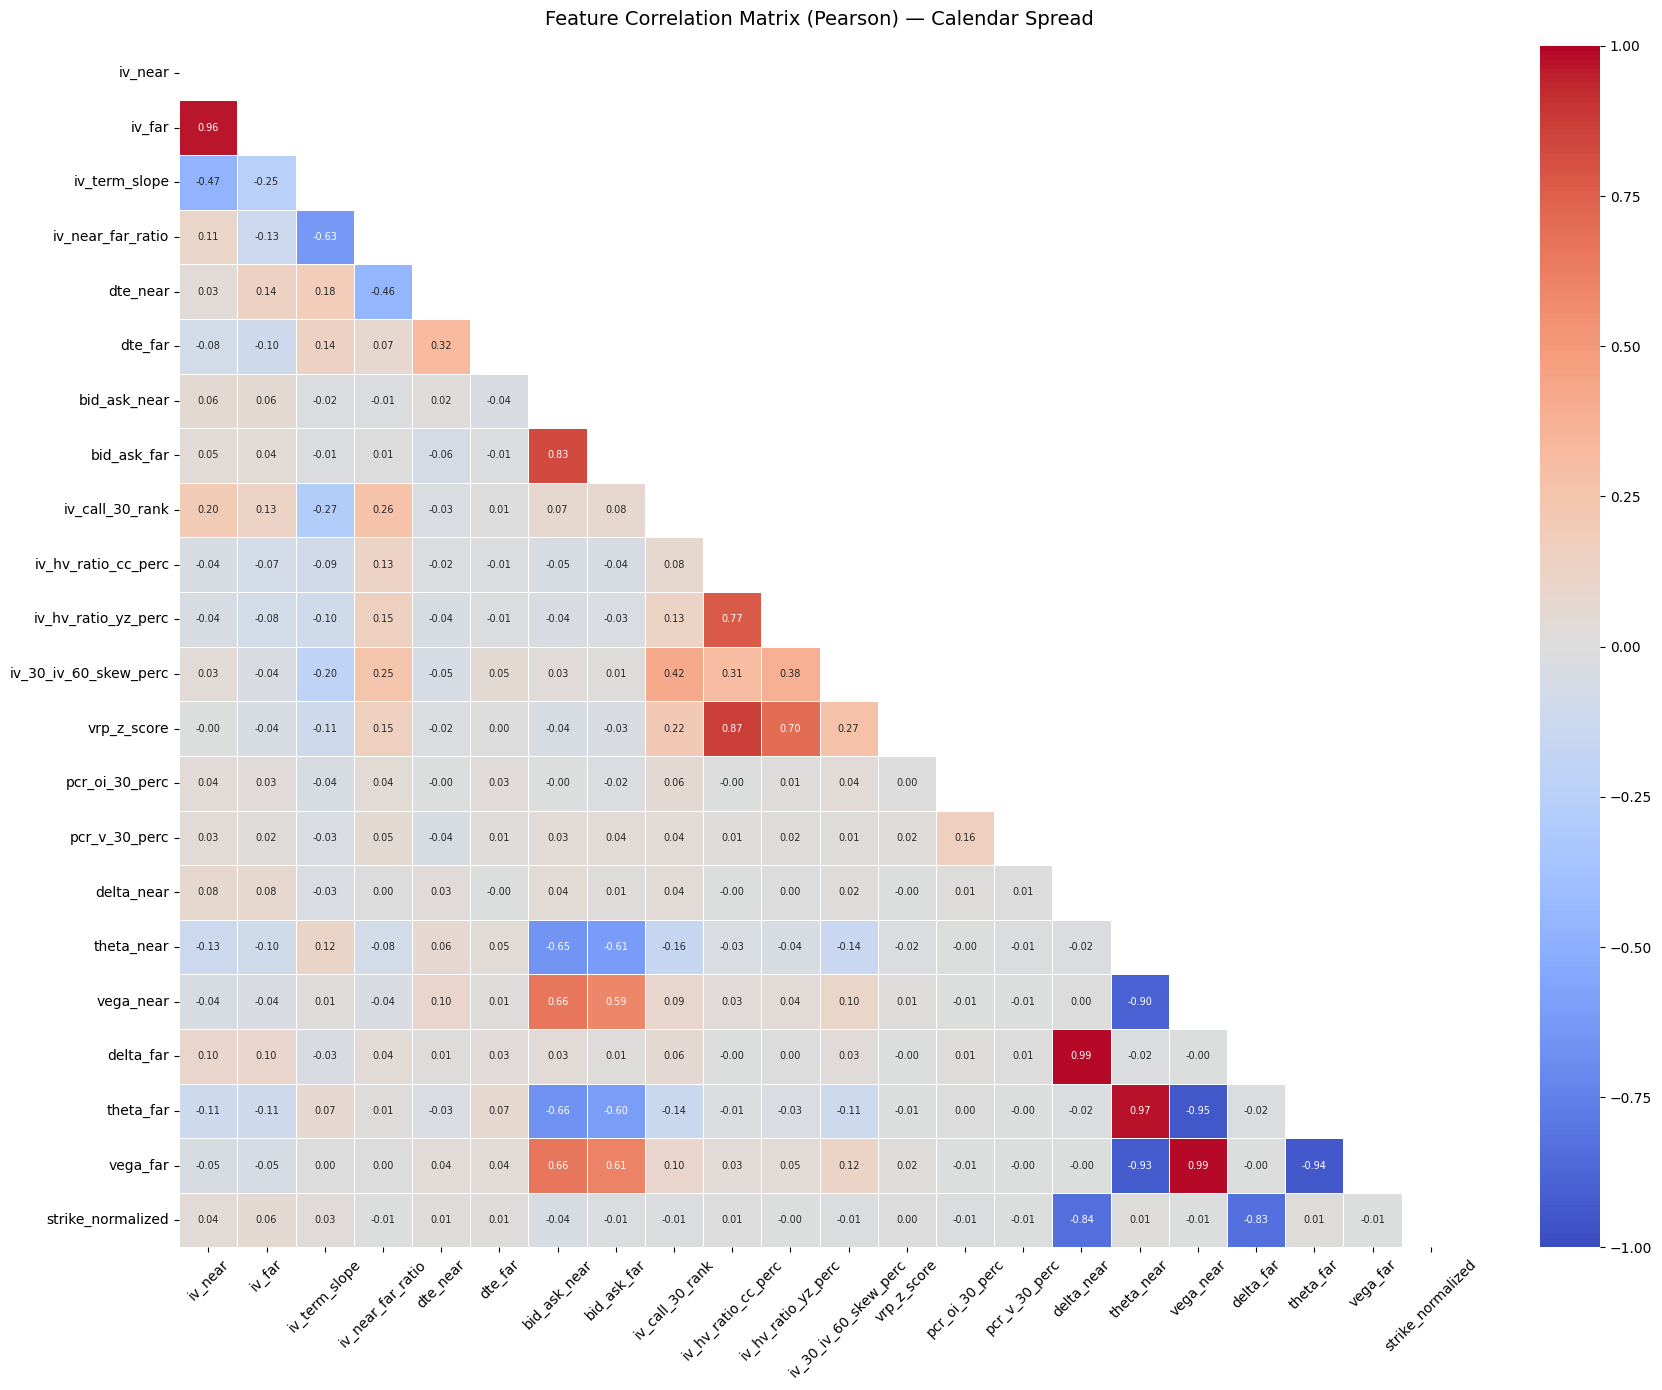

=== High Correlation Pairs (|r| > 0.70) ===


,Feature A,Feature B,Pearson r
0,vega_near,vega_far,0.9901
1,delta_near,delta_far,0.9855
2,theta_near,theta_far,0.9736
3,iv_near,iv_far,0.9610
4,vega_near,theta_far,-0.9456
5,theta_far,vega_far,-0.9405
6,theta_near,vega_far,-0.9271
7,theta_near,vega_near,-0.9029
8,iv_hv_ratio_cc_perc,vrp_z_score,0.8700
9,delta_near,strike_normalized,-0.8372



=== Variance Inflation Factors ===


,Feature,VIF
0,delta_far,2417.834232
1,delta_near,1478.358851
2,iv_near,737.809112
3,vega_near,656.500074
4,iv_far,638.303872
5,vega_far,607.696489
6,iv_near_far_ratio,380.510712
7,strike_normalized,362.769732
8,theta_far,266.006436
9,theta_near,224.857451


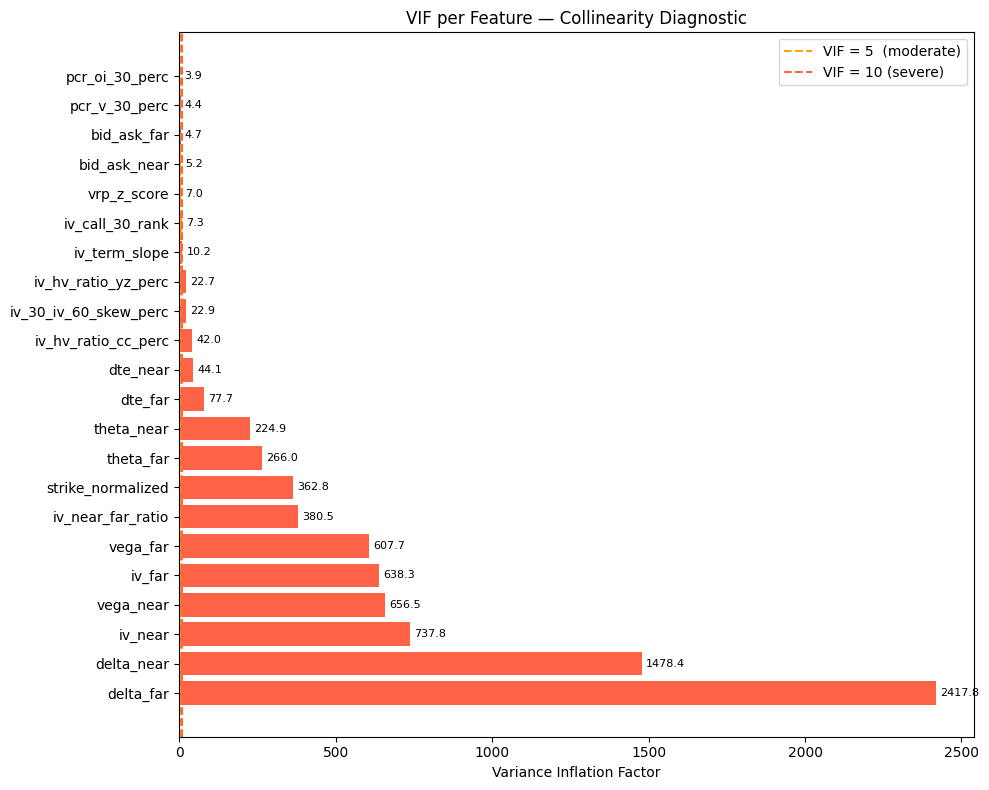

In [9]:
# STEP 6: Correlation Heatmap + Collinearity Analysis


# 6A: Correlation Matrix Heatmap
corr_matrix = df_X.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (Pearson) — Calendar Spread', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# 6B: Flag High Correlation Pairs
print('=== High Correlation Pairs (|r| > 0.70) ===')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            high_corr_pairs.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Pearson r': round(r, 4)
            })

if high_corr_pairs:
    high_corr_df = (pd.DataFrame(high_corr_pairs)
                    .sort_values('Pearson r', key=abs, ascending=False)
                    .reset_index(drop=True))
    display(high_corr_df)
else:
    print('No pairs with |r| > 0.70 found.')

# 6C: Variance Inflation Factor (VIF)
# VIF measures how much one feature's variance is explained by
# all other features combined — more rigorous than pairwise r.
#   VIF 1     = no collinearity
#   VIF 1–5   = acceptable
#   VIF 5–10  = concern
#   VIF > 10  = severe, action needed

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Feature': df_X.columns,
    'VIF': [variance_inflation_factor(df_X.values, i)
            for i in range(df_X.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('\n=== Variance Inflation Factors ===')
display(vif_data)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_data['VIF']]
bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5  (moderate)')
ax.axvline(10, color='tomato',  linestyle='--', linewidth=1.5, label='VIF = 10 (severe)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF per Feature — Collinearity Diagnostic')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('vif_plot.png', dpi=150)
plt.show()

In [10]:
# STEP 7: Export Final Clean Dataset

# We export TWO versions so Milestone 3 can pick the right one:
#   _scaled.csv  -- features are already z-scored against the full sample.
#                   Fast to use but carries mild look-ahead leakage, since
#                   the scaler saw test-period rows. Good for prototyping,
#                   baselines, and feature-importance inspection.
#   _raw.csv     -- features in their natural units. Use this when doing
#                   a proper time-based train/val/test split: fit a fresh
#                   StandardScaler on X_train only, then transform X_val
#                   and X_test with those train statistics.
# Both files share identical rows, target columns, and metadata so you
# can load either without changing the rest of the pipeline.

feature_cols_final  = feature_cols
df_X_final          = df_X.copy()           # unscaled 22-col matrix
df_X_final_scaled   = df_X_scaled.copy()    # standardized 22-col matrix

def build_export(feature_frame):
    out = feature_frame.copy()
    out['profitable']                 = df_y.values
    out['profitable_worst']           = df['profitable_worst'].values
    out['percent_profit_loss']        = df['percent_profit_loss'].values
    out['percent_profit_loss_worst']  = df['percent_profit_loss_worst'].values
    out['ticker']                     = df['ticker'].values
    out['entry_time']                 = df['entry_time'].values
    return out

df_final        = build_export(df_X_final_scaled)   # scaled export
df_final_raw    = build_export(df_X_final)          # raw export

print('=== Final Dataset Summary ===')
print(f'Shape (scaled & raw):  {df_final.shape}')
print(f'Features:              {len(feature_cols_final)}')
print(f'Target (canonical):    profitable (= profitable_quarter)')
print(f'  Profitable trades:   {df_y.sum():,} ({df_y.mean()*100:.1f}%)')
print(f'  Unprofitable trades: {(df_y==0).sum():,} ({(df_y==0).mean()*100:.1f}%)')
print(f'Stress-test target:    profitable_worst '
      f'({df["profitable_worst"].sum():,} positive, '
      f'{df["profitable_worst"].mean()*100:.2f}%)')
print(f'Missing values:        '
      f'scaled={df_final.isnull().sum().sum()}, '
      f'raw={df_final_raw.isnull().sum().sum()}')
print(f'Date range:            {df["entry_time"].min().date()} -> '
      f'{df["entry_time"].max().date()}')

print('\n--- Scaled export (head) ---')
display(df_final.head(3))
print('--- Raw export (head) ---')
display(df_final_raw.head(3))

# --- Save both CSVs locally ---
scaled_local = 'calendar_spread_model_ready.csv'       # kept for back-compat
raw_local    = 'calendar_spread_model_ready_raw.csv'
df_final.to_csv(scaled_local, index=False)
df_final_raw.to_csv(raw_local, index=False)
print(f'\nSaved locally:')
print(f'  {scaled_local}  (features z-scored)')
print(f'  {raw_local}  (features in raw units)')

# --- Mirror to Google Drive if available ---
for fname in (scaled_local, raw_local):
    drive_path = f'/content/drive/MyDrive/{fname}'
    try:
        (df_final if fname == scaled_local else df_final_raw).to_csv(
            drive_path, index=False)
        print(f'Saved to Drive: {drive_path}')
    except Exception as e:
        print(f'Could not save to Drive ({fname}): {e}')

print('\n=== Milestone 3 quick-start ===')
print("""
# Proper time-based workflow (recommended):
df  = pd.read_csv('calendar_spread_model_ready_raw.csv',
                  parse_dates=['entry_time']).sort_values('entry_time')
features = [c for c in df.columns if c not in
            {'profitable','profitable_worst',
             'percent_profit_loss','percent_profit_loss_worst',
             'ticker','entry_time'}]
train = df['entry_time'] <= '2023-06-30'
scaler = StandardScaler().fit(df.loc[train, features])
X_train = scaler.transform(df.loc[train,  features])
X_test  = scaler.transform(df.loc[~train, features])
y_train, y_test = df.loc[train,'profitable'], df.loc[~train,'profitable']

# Quick prototyping workflow (accepts mild scaling leakage):
df = pd.read_csv('calendar_spread_model_ready.csv',
                 parse_dates=['entry_time'])
""")

print('=== Objects ready for Milestone 3 ===')
print('  df_final            -- scaled model-ready dataframe')
print('  df_final_raw        -- unscaled model-ready dataframe')
print('  df_X_final          -- unscaled feature matrix  (9,036 x 22)')
print('  df_X_final_scaled   -- standardized feature matrix')
print('  df_y                -- canonical binary target (profitable_quarter)')
print('  feature_cols_final  -- list of 22 feature names')
print('  class_weight_dict   -- class weights for Keras/sklearn  (~10:1)')
print('  scale_pos_weight    -- class weight for XGBoost/PyTorch (~10.3)')
print('  scaler              -- fitted StandardScaler (fit on full sample)')

=== Final Dataset Summary ===
Shape (scaled & raw):  (8968, 28)
Features:              22
Target (canonical):    profitable (= profitable_quarter)
  Profitable trades:   2,082 (23.2%)
  Unprofitable trades: 6,886 (76.8%)
Stress-test target:    profitable_worst (159 positive, 1.77%)
Missing values:        scaled=0, raw=0
Date range:            2018-05-22 -> 2025-05-22

--- Scaled export (head) ---


,iv_near,iv_far,iv_term_slope,iv_near_far_ratio,dte_near,dte_far,bid_ask_near,bid_ask_far,iv_call_30_rank,iv_hv_ratio_cc_perc,...,delta_far,theta_far,vega_far,strike_normalized,profitable,profitable_worst,percent_profit_loss,percent_profit_loss_worst,ticker,entry_time
0,-0.721073,-0.718824,0.355455,0.041330,-0.394180,0.644769,-0.505356,-0.364053,0.156509,-0.260497,...,0.026814,0.167745,0.137369,-0.103238,0,0,-0.097561,-0.2273,INTU,2018-05-22 15:45:00
1,0.417494,-0.033314,-1.004324,1.827825,-0.549586,0.528463,-0.505356,-0.218656,-0.881432,0.212413,...,-0.999556,0.448954,-0.465987,0.856522,0,0,-0.315789,-0.8571,WSM,2018-05-23 15:45:00
2,-0.117031,-0.407345,-0.493047,1.472041,-0.549586,0.528463,-0.505356,-0.509451,1.117152,0.500329,...,-2.060229,0.472635,-0.457129,1.497828,0,0,-0.117647,-0.4000,CPRT,2018-05-23 15:45:00


--- Raw export (head) ---


,iv_near,iv_far,iv_term_slope,iv_near_far_ratio,dte_near,dte_far,bid_ask_near,bid_ask_far,iv_call_30_rank,iv_hv_ratio_cc_perc,...,delta_far,theta_far,vega_far,strike_normalized,profitable,profitable_worst,percent_profit_loss,percent_profit_loss_worst,ticker,entry_time
0,0.2484,0.2192,-0.000834,1.133212,24,59,0.1,0.3,51.37,0.60315,...,0.5395,-0.0607,30.3918,0.997794,0,0,-0.097561,-0.2273,INTU,2018-05-22 15:45:00
1,0.4433,0.3266,-0.003334,1.357318,23,58,0.1,0.5,26.26,0.73020,...,0.4647,-0.0227,7.7429,1.022913,0,0,-0.315789,-0.8571,WSM,2018-05-23 15:45:00
2,0.3518,0.2680,-0.002394,1.312687,23,58,0.1,0.1,74.61,0.80755,...,0.3874,-0.0195,8.0754,1.039698,0,0,-0.117647,-0.4000,CPRT,2018-05-23 15:45:00



Saved locally:
  calendar_spread_model_ready.csv  (features z-scored)
  calendar_spread_model_ready_raw.csv  (features in raw units)
Could not save to Drive (calendar_spread_model_ready.csv): Cannot save file into a non-existent directory: '/content/drive/MyDrive'
Could not save to Drive (calendar_spread_model_ready_raw.csv): Cannot save file into a non-existent directory: '/content/drive/MyDrive'

=== Milestone 3 quick-start ===

# Proper time-based workflow (recommended):
df  = pd.read_csv('calendar_spread_model_ready_raw.csv',
                  parse_dates=['entry_time']).sort_values('entry_time')
features = [c for c in df.columns if c not in
            {'profitable','profitable_worst',
             'percent_profit_loss','percent_profit_loss_worst',
             'ticker','entry_time'}]
train = df['entry_time'] <= '2023-06-30'
scaler = StandardScaler().fit(df.loc[train, features])
X_train = scaler.transform(df.loc[train,  features])
X_test  = scaler.transform(df.loc[~train, feature

# Part II — Modeling Pipeline

This part loads the model-ready dataset, creates chronological train (≤2022) / validation (2023) / test (2024–25) splits, trains five model families — Logistic Regression, LightGBM, a plain MLP, an MLP with ticker embeddings, and a Two-Stream GRU — plus rank-average ensembles. Each model is scored with PR-AUC, ROC-AUC, precision at top 10%, expected P&L per trade, and Sharpe. A worst-case stress test re-evaluates every model against the original CSV target to show how sensitive the ranking is to execution assumptions.


## Modeling overview

This part takes the cleaned dataset produced by Part I and trains a progression of classifiers to predict whether a pre-earnings ATM calendar spread will be profitable under the quarter-spread execution assumption.

**Target:** `profitable = 1` if quarter-spread P&L > 0. After the Part I reconstruction, the modelling panel has 8,968 rows and a 23.22% full-sample positive rate.

**Model progression**

1. Logistic regression — linear baseline
2. LightGBM — gradient-boosted trees, industry standard for tabular finance
3. MLP — starter neural network
4. MLP + ticker embeddings
5. Two-stream GRU — per-ticker earnings history + current event
6. Rank ensembles — `LightGBM + GRU` and `LightGBM + GRU + MLPE`

**Evaluation:** PR-AUC, ROC-AUC, precision at top-10%, expected P&L per trade, and Sharpe on selected trades — all on the held-out 2024–2025 test set. Every model is also stress-tested against the original worst-case pricing target at the end of Part II.

**Inputs and outputs**

- Input: `calendar_spread_model_ready_raw.csv` (produced by Part I).
- Outputs saved: `milestone_3_results.{csv,json}` (canonical results) and `milestone_3_stress.{csv,json}` (worst-case stress test).


## Step 0 - Environment setup

In [11]:
%pip install --quiet tensorflow lightgbm scikit-learn pandas numpy matplotlib seaborn scipy

import os, sys, json, random, warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

import lightgbm as lgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Python  :', sys.version.split()[0])
print('TF      :', tf.__version__)
print('Pandas  :', pd.__version__)
print('NumPy   :', np.__version__)
print('LightGBM:', lgb.__version__)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs    : {len(gpus)} available -> {[g.name for g in gpus]}')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(' ', e)


Python  : 3.12.13
TF      : 2.20.0
Pandas  : 2.2.2
NumPy   : 2.0.2
LightGBM: 4.6.0
GPUs    : 1 available -> ['/physical_device:GPU:0']


## Step 1 - Load Milestone 2 outputs

In [12]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/CS1090B_final_del/calendar_spread_model_ready_raw.csv"


df = pd.read_csv(path, parse_dates=['entry_time'])
df = df.sort_values('entry_time').reset_index(drop=True)

META_COLS   = ['ticker', 'entry_time']
TARGET_COLS = ['profitable', 'profitable_worst',
               'percent_profit_loss', 'percent_profit_loss_worst']
feature_cols = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

print(f'Total rows : {len(df):,}')
print(f'Features   : {len(feature_cols)}')
print(f'Positive   : {int(df["profitable"].sum()):,} '
      f'({df["profitable"].mean()*100:.2f}%)')
print(f'Worst pos  : {int(df["profitable_worst"].sum()):,} '
      f'({df["profitable_worst"].mean()*100:.2f}%)')
print(f'Date range : {df["entry_time"].min().date()} -> {df["entry_time"].max().date()}')
print(f'Tickers    : {df["ticker"].nunique()}')
print('\nFeature list:')
for c in feature_cols:
    print(' ', c)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total rows : 8,968
Features   : 22
Positive   : 2,082 (23.22%)
Worst pos  : 159 (1.77%)
Date range : 2018-05-22 -> 2025-05-22
Tickers    : 476

Feature list:
  iv_near
  iv_far
  iv_term_slope
  iv_near_far_ratio
  dte_near
  dte_far
  bid_ask_near
  bid_ask_far
  iv_call_30_rank
  iv_hv_ratio_cc_perc
  iv_hv_ratio_yz_perc
  iv_30_iv_60_skew_perc
  vrp_z_score
  pcr_oi_30_perc
  pcr_v_30_perc
  delta_near
  theta_near
  vega_near
  delta_far
  theta_far
  vega_far
  strike_normalized


## Step 2 - Time-based train / val / test split

Chronological split, no shuffling. Training data ends 2022-12-31 so that the model cannot see any 2023+ information at fit time.

| Split | Period                     | Purpose                         |
|-------|----------------------------|---------------------------------|
| Train | 2018-01 - 2022-12          | Fit model weights               |
| Val   | 2023-01 - 2023-12          | Early stopping / model select   |
| Test  | 2024-01 - 2025            | Final out-of-sample evaluation  |

Class weights are computed on training rows only.

In [13]:
TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

is_train = df['entry_time'] <= TRAIN_END
is_val   = (df['entry_time'] > TRAIN_END) & (df['entry_time'] <= VAL_END)
is_test  = df['entry_time'] > VAL_END

def split_row(mask, name, period):
    n       = int(mask.sum())
    n_pos   = int(df.loc[mask, 'profitable'].sum())
    n_neg   = n - n_pos
    pos_pct = n_pos / n * 100 if n else 0.0
    nw_pos  = int(df.loc[mask, 'profitable_worst'].sum())
    nw_pct  = nw_pos / n * 100 if n else 0.0
    return {
        'Split': name, 'Period': period, 'n': n,
        'Pos (half)':  n_pos, 'Neg (half)': n_neg,
        'Pos % (half)':  round(pos_pct, 2),
        'Pos (worst)': nw_pos,
        'Pos % (worst)': round(nw_pct, 2),
    }

split_summary = pd.DataFrame([
    split_row(is_train, 'Train', f'<= {TRAIN_END}'),
    split_row(is_val,   'Val',   f'{TRAIN_END} -> {VAL_END}'),
    split_row(is_test,  'Test',  f'> {VAL_END}'),
])
print(split_summary.to_string(index=False))

# Imbalance ratios (neg : pos) for the canonical target, per split
print('\nImbalance ratio (neg : pos) on canonical target (half-spread):')
for r in split_summary.to_dict('records'):
    ratio = r['Neg (half)'] / max(r['Pos (half)'], 1)
    print(f"  {r['Split']:<5}  {ratio:6.2f} : 1")

X_train = df.loc[is_train, feature_cols].values
X_val   = df.loc[is_val,   feature_cols].values
X_test  = df.loc[is_test,  feature_cols].values

y_train = df.loc[is_train, 'profitable'].values.astype(int)
y_val   = df.loc[is_val,   'profitable'].values.astype(int)
y_test  = df.loc[is_test,  'profitable'].values.astype(int)

pnl_train = df.loc[is_train, 'percent_profit_loss'].values
pnl_val   = df.loc[is_val,   'percent_profit_loss'].values
pnl_test  = df.loc[is_test,  'percent_profit_loss'].values

# Worst-case target + pnl for later stress test
y_test_worst   = df.loc[is_test, 'profitable_worst'].values.astype(int)
pnl_test_worst = df.loc[is_test, 'percent_profit_loss_worst'].values

# Ticker ids (indexed over the full universe)
all_tickers  = sorted(df['ticker'].unique())
ticker_to_id = {t: i for i, t in enumerate(all_tickers)}
N_TICKERS    = len(all_tickers)

t_train = df.loc[is_train, 'ticker'].map(ticker_to_id).values.astype(np.int32)
t_val   = df.loc[is_val,   'ticker'].map(ticker_to_id).values.astype(np.int32)
t_test  = df.loc[is_test,  'ticker'].map(ticker_to_id).values.astype(np.int32)

# Balanced class weights from training data only
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight     = {0: float(cw[0]), 1: float(cw[1])}
scale_pos_weight = float(cw[1] / cw[0])

print(f'\nN tickers        : {N_TICKERS}')
print(f'class_weight     : {class_weight}')
print(f'scale_pos_weight : {scale_pos_weight:.2f}')


Split                   Period    n  Pos (half)  Neg (half)  Pos % (half)  Pos (worst)  Pos % (worst)
Train            <= 2022-12-31 5677        1187        4490         20.91           74           1.30
  Val 2022-12-31 -> 2023-12-31 1327         334         993         25.17           32           2.41
 Test             > 2023-12-31 1964         561        1403         28.56           53           2.70

Imbalance ratio (neg : pos) on canonical target (half-spread):
  Train    3.78 : 1
  Val      2.97 : 1
  Test     2.50 : 1

N tickers        : 476
class_weight     : {0: 0.6321826280623608, 1: 2.391322662173547}
scale_pos_weight : 3.78


## Step 3 - Scale features (fit on train only)

`StandardScaler` is fit on training rows only, then applied to val and test. Tree models (LightGBM) use the raw matrix; linear / NN models use the scaled matrix.

In [14]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

print(f'X_train_s: {X_train_s.shape}  mean={X_train_s.mean():.3f}  std={X_train_s.std():.3f}')
print(f'X_val_s  : {X_val_s.shape}')
print(f'X_test_s : {X_test_s.shape}')


X_train_s: (5677, 22)  mean=0.000  std=1.000
X_val_s  : (1327, 22)
X_test_s : (1964, 22)


## Step 4 - Shared evaluation framework

Every model returns predicted probabilities on the test set. We compare them with:

| Metric                | Meaning                                                 |
|-----------------------|---------------------------------------------------------|
| `pr_auc`              | Area under PR curve. Primary metric. Baseline = pos %.  |
| `pr_auc_lift`         | `pr_auc - baseline`. Lift over a random ranker.         |
| `roc_auc`             | Reference only. Inflates at high imbalance.             |
| `precision@10%`       | Of trades ranked in the top 10%, fraction that won.     |
| `ev_per_trade`        | Mean `percent_profit_loss` on those top-10% trades.     |
| `sharpe`              | mean / std of that P&L series. Risk-adjusted.           |


In [15]:
TOP_K_FRAC = 0.10

def evaluate(y_true, y_proba, pnl, name='', top_k_frac=TOP_K_FRAC):
    '''Return dict of metrics for one model's test-set predictions.'''
    y_true  = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    pnl     = np.asarray(pnl).astype(float)

    pr_auc      = average_precision_score(y_true, y_proba)
    roc_auc     = roc_auc_score(y_true, y_proba)
    baseline_pr = y_true.mean()

    k = max(int(len(y_true) * top_k_frac), 1)
    top_idx   = np.argsort(y_proba)[-k:]
    prec_at_k = y_true[top_idx].mean()
    ev        = pnl[top_idx].mean()
    sharpe    = ev / (pnl[top_idx].std() + 1e-9)

    return {
        'model': name,
        'pr_auc': round(float(pr_auc), 4),
        'pr_auc_baseline': round(float(baseline_pr), 4),
        'pr_auc_lift': round(float(pr_auc - baseline_pr), 4),
        'roc_auc': round(float(roc_auc), 4),
        f'precision@{int(top_k_frac*100)}%': round(float(prec_at_k), 4),
        'ev_per_trade': round(float(ev), 4),
        'sharpe': round(float(sharpe), 4),
        'n_top_k': int(k),
    }

results = []   # list of dicts, one per model
probas  = {}   # model name -> test set probabilities (for stress test)


# ---- Training-curve helpers -------------------------------------------------

def plot_history(history, title, pr_auc_key='pr_auc'):
    """Plot training vs validation loss and PR-AUC for a Keras History."""
    h = history.history
    epochs = np.arange(1, len(h['loss']) + 1)
    best_ep  = int(np.argmax(h[f'val_{pr_auc_key}'])) + 1
    best_val = h[f'val_{pr_auc_key}'][best_ep - 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, h['loss'],     label='train')
    axes[0].plot(epochs, h['val_loss'], label='val')
    axes[0].axvline(best_ep, ls='--', c='grey', label=f'best epoch = {best_ep}')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('binary cross-entropy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, h[pr_auc_key],          label='train')
    axes[1].plot(epochs, h[f'val_{pr_auc_key}'], label='val')
    axes[1].axvline(best_ep, ls='--', c='grey',
                    label=f'best val PR-AUC = {best_val:.3f} (ep {best_ep})')
    axes[1].set_title(f'{title} - PR-AUC')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('PR-AUC')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_lgb_history(evals_result, title='LightGBM'):
    """Plot LightGBM train vs val average_precision across boosting rounds."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for split, series in evals_result.items():
        metric = list(series.keys())[0]
        ax.plot(series[metric], label=f'{split} ({metric})')
    ax.set_xlabel('boosting round'); ax.set_ylabel('average precision')
    ax.set_title(f'{title} training curve')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Tier 1 - Baselines

Two models that set the bar. Everything more complex has to beat them.

### Model 1 - Logistic Regression

In [16]:
lr = LogisticRegression(
    penalty='l2', C=1.0, max_iter=2000,
    class_weight='balanced', n_jobs=-1, random_state=SEED,
)
lr.fit(X_train_s, y_train)
y_proba_lr = lr.predict_proba(X_test_s)[:, 1]

res = evaluate(y_test, y_proba_lr, pnl_test, name='LogisticRegression')
results.append(res); probas['LogisticRegression'] = y_proba_lr
print(res)


{'model': 'LogisticRegression', 'pr_auc': 0.3737, 'pr_auc_baseline': 0.2856, 'pr_auc_lift': 0.0881, 'roc_auc': 0.6279, 'precision@10%': 0.4184, 'ev_per_trade': -0.1572, 'sharpe': -0.1305, 'n_top_k': 196}


### Model 2 - LightGBM

[50]	train's average_precision: 0.674483	val's average_precision: 0.378979
[100]	train's average_precision: 0.840231	val's average_precision: 0.356993
[150]	train's average_precision: 0.92886	val's average_precision: 0.359189
[200]	train's average_precision: 0.972707	val's average_precision: 0.361612
[250]	train's average_precision: 0.990691	val's average_precision: 0.364286
[300]	train's average_precision: 0.997326	val's average_precision: 0.363197
[350]	train's average_precision: 0.999033	val's average_precision: 0.35961
[400]	train's average_precision: 0.999794	val's average_precision: 0.354121
[450]	train's average_precision: 0.999971	val's average_precision: 0.353199
[500]	train's average_precision: 1	val's average_precision: 0.350127

Final round: 500  |  Best val AP = 0.3847 at iter 42
{'model': 'LightGBM', 'pr_auc': 0.3875, 'pr_auc_baseline': 0.2856, 'pr_auc_lift': 0.1018, 'roc_auc': 0.6413, 'precision@10%': 0.4133, 'ev_per_trade': -0.0756, 'sharpe': -0.1083, 'n_top_k': 196}

T

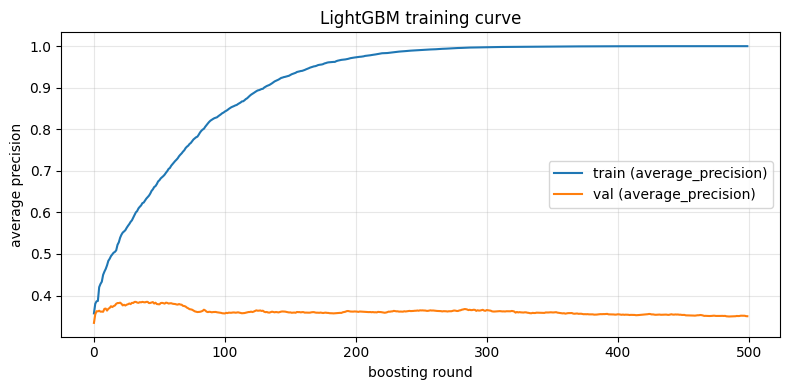

In [17]:
# Trees don't need scaling -- feed raw X.
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

lgb_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'verbosity': -1,
    'seed': SEED,
}

# Run the full boosting budget (no early stopping). evals_result captures
# train + val AP per round so we can plot the training curve.
NUM_BOOST_ROUNDS = 500
evals_result = {}

gbm = lgb.train(
    lgb_params, lgb_train,
    num_boost_round=NUM_BOOST_ROUNDS,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(period=50),
    ],
)

# Use whichever round was best on val for the reported test score (fair
# reporting even though we let training run the full budget).
val_ap = np.array(evals_result['val']['average_precision'])
best_iter = int(np.argmax(val_ap)) + 1
print(f'\nFinal round: {NUM_BOOST_ROUNDS}  |  '
      f'Best val AP = {val_ap.max():.4f} at iter {best_iter}')

y_proba_gbm = gbm.predict(X_test, num_iteration=best_iter)

res = evaluate(y_test, y_proba_gbm, pnl_test, name='LightGBM')
results.append(res); probas['LightGBM'] = y_proba_gbm
print(res)

imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': gbm.feature_importance(importance_type='gain',
                                         iteration=best_iter),
}).sort_values('importance', ascending=False)
print('\nTop 10 features by LightGBM gain:')
print(imp.head(10).to_string(index=False))

plot_lgb_history(evals_result, title='LightGBM')


## Tier 2 - Neural networks

Project-required track. Starting simple and adding structure. Same optimizer, same callbacks, only the architecture changes so differences are attributable.

### Model 3 - Simple MLP

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 - 14s - 315ms/step - loss: 0.7516 - pr_auc: 0.2265 - roc_auc: 0.5305 - val_loss: 0.7309 - val_pr_auc: 0.3219 - val_roc_auc: 0.6017 - learning_rate: 0.0010
Epoch 2/100
45/45 - 0s - 5ms/step - loss: 0.7266 - pr_auc: 0.2563 - roc_auc: 0.5808 - val_loss: 0.7242 - val_pr_auc: 0.3614 - val_roc_auc: 0.6384 - learning_rate: 0.0010
Epoch 3/100
45/45 - 0s - 5ms/step - loss: 0.7109 - pr_auc: 0.2924 - roc_auc: 0.6209 - val_loss: 0.7223 - val_pr_auc: 0.3794 - val_roc_auc: 0.6549 - learning_rate: 0.0010
Epoch 4/100
45/45 - 0s - 5ms/step - loss: 0.7095 - pr_auc: 0.2919 - roc_auc: 0.6182 - val_loss: 0.7161 - val_pr_auc: 0.3823 - val_roc_auc: 0.6596 - learning_rate: 0.0010
Epoch 5/100
45/45 - 0s - 5ms/step - loss: 0.7041 - pr_auc: 0.3003 - roc_auc: 0.6380 - val_loss: 0.7203 - val_pr_auc: 0.3840 - val_roc_auc: 0.6616 - learning_rate: 0.0010
Epoch 6/100
45/45 - 0s - 5ms/step - loss: 0.7000 - pr_auc: 0.3134 - roc_auc: 0.6432 - val_loss: 0.7167 - val_pr_auc: 0.3849 - val_roc_auc: 0.6628 -

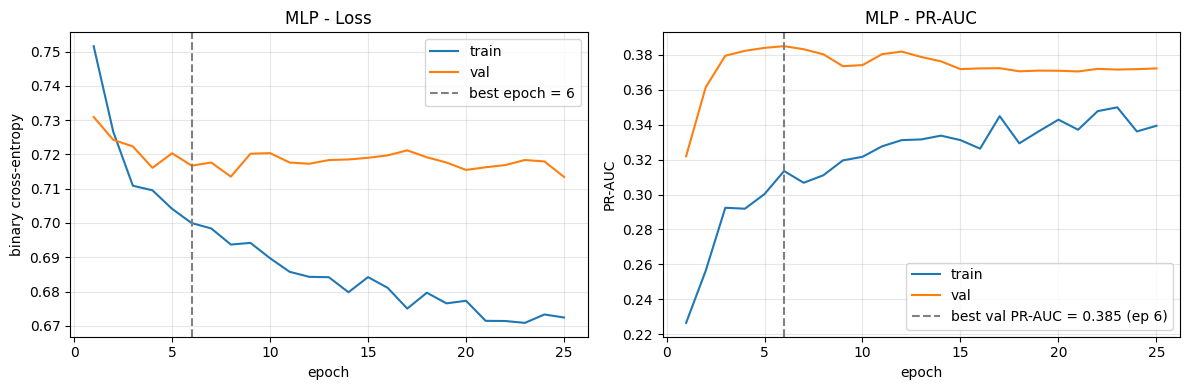

In [18]:
def build_mlp(input_dim, hidden=(64, 32), dropout=0.4, l2=5e-4):
    # Stronger regularization (dropout 0.3 -> 0.4, L2 1e-4 -> 5e-4) plus
    # label-smoothed BCE (targets become 0.1/0.9 instead of 0/1) caps the
    # maximum per-sample loss at -log(0.1)=2.3 and prevents the val-loss
    # blow-up we saw previously. Minor PR-AUC cost, much cleaner curve.
    inp = keras.Input(shape=(input_dim,))
    x = inp
    for units in hidden:
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=[keras.metrics.AUC(name='roc_auc'),
                 keras.metrics.AUC(curve='PR', name='pr_auc')],
    )
    return m

mlp = build_mlp(X_train_s.shape[1])
mlp.summary()

EPOCHS = 100
# patience=9999 => never triggers early stop, but restore_best_weights still
# fires at end of fit() so we report the fair best-checkpoint test score.
cb_mlp = [
    callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                            patience=20, min_delta=1e-3,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max',
                                factor=0.5, patience=20, min_lr=1e-6),
]

history_mlp = mlp.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS, batch_size=128,
    class_weight=class_weight,
    callbacks=cb_mlp, verbose=2,
)

y_proba_mlp = mlp.predict(X_test_s, verbose=0).ravel()
res = evaluate(y_test, y_proba_mlp, pnl_test, name='MLP')
results.append(res); probas['MLP'] = y_proba_mlp
print(res)

plot_history(history_mlp, title='MLP')


### Model 4 - MLP + ticker embeddings

Adds a learned embedding per ticker. The hypothesis is that response to IV crush differs by name (growth tech vs consumer staples vs banks) and a small embedding vector per ticker captures that without needing a ticker-level feature hand-engineered.

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ticker (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ticker_emb          │ (None, 8)         │      3,808 │ ticker[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ ticker_emb[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 30)        │          0 │ features[0][0],   │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      1,984 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,905 (30.88 KB)

 Trainable params: 7,905 (30.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 - 12s - 259ms/step - loss: 0.8494 - pr_auc: 0.2084 - roc_auc: 0.4970 - val_loss: 0.7614 - val_pr_auc: 0.2834 - val_roc_auc: 0.5482 - learning_rate: 5.0000e-04
Epoch 2/100
45/45 - 0s - 5ms/step - loss: 0.8055 - pr_auc: 0.2272 - roc_auc: 0.5409 - val_loss: 0.7566 - val_pr_auc: 0.3115 - val_roc_auc: 0.5842 - learning_rate: 5.0000e-04
Epoch 3/100
45/45 - 0s - 6ms/step - loss: 0.7880 - pr_auc: 0.2322 - roc_auc: 0.5501 - val_loss: 0.7564 - val_pr_auc: 0.3248 - val_roc_auc: 0.5994 - learning_rate: 5.0000e-04
Epoch 4/100
45/45 - 0s - 5ms/step - loss: 0.7738 - pr_auc: 0.2412 - roc_auc: 0.5606 - val_loss: 0.7559 - val_pr_auc: 0.3311 - val_roc_auc: 0.6104 - learning_rate: 5.0000e-04
Epoch 5/100
45/45 - 0s - 6ms/step - loss: 0.7600 - pr_auc: 0.2618 - roc_auc: 0.5883 - val_loss: 0.7494 - val_pr_auc: 0.3369 - val_roc_auc: 0.6203 - learning_rate: 5.0000e-04
Epoch 6/100
45/45 - 0s - 6ms/step - loss: 0.7658 - pr_auc: 0.2397 - roc_auc: 0.5595 - val_loss: 0.7488 - val_pr_auc: 0.3394 - v

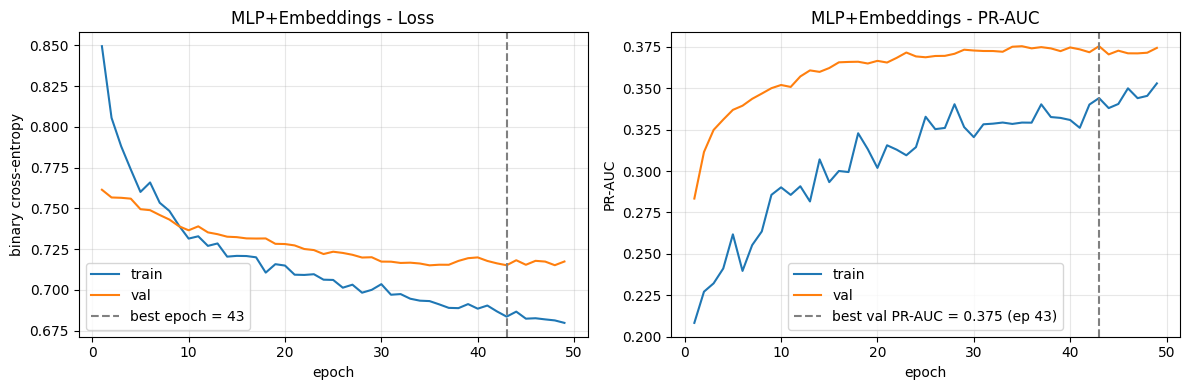

In [19]:
EMB_DIM = 8

def build_mlp_emb(n_features, n_tickers, emb_dim=EMB_DIM,
                  hidden=(64, 32), dropout=0.5, l2=1e-3):
    # Ticker embeddings are the easiest place to overfit: many tickers have
    # only a handful of events. Heavier dropout/L2 keeps validation BCE from
    # drifting upward while preserving the rank signal.
    feat_in   = keras.Input(shape=(n_features,), name='features')
    ticker_in = keras.Input(shape=(), dtype='int32', name='ticker')

    # Small L2 on the embedding so rare-ticker rows don't push it to extremes
    emb = layers.Embedding(n_tickers, emb_dim,
                           embeddings_regularizer=regularizers.l2(l2),
                           name='ticker_emb')(ticker_in)
    emb = layers.Flatten()(emb)

    x = layers.Concatenate()([feat_in, emb])
    for units in hidden:
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    m = keras.Model([feat_in, ticker_in], out)
    m.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.15),
        metrics=[keras.metrics.AUC(name='roc_auc'),
                 keras.metrics.AUC(curve='PR', name='pr_auc')],
    )
    return m

mlp_emb = build_mlp_emb(X_train_s.shape[1], N_TICKERS)
mlp_emb.summary()

cb_emb = [
    callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                            patience=15, min_delta=1e-3,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max',
                                factor=0.5, patience=15, min_lr=1e-6),
]

history_emb = mlp_emb.fit(
    [X_train_s, t_train], y_train,
    validation_data=([X_val_s, t_val], y_val),
    epochs=100, batch_size=128,
    class_weight=class_weight,
    callbacks=cb_emb, verbose=2,
)

y_proba_mlp_emb = mlp_emb.predict([X_test_s, t_test], verbose=0).ravel()
res = evaluate(y_test, y_proba_mlp_emb, pnl_test, name='MLP+Embeddings')
results.append(res); probas['MLP+Embeddings'] = y_proba_mlp_emb
print(res)

plot_history(history_emb, title='MLP+Embeddings')


## Tier 3 - Two-stream GRU (RNN)

**Framing.** For each earnings event we build a short sequence of that ticker's PRIOR earnings events (up to `MAX_LOOKBACK = 4`), scale them with the training-fit scaler, and feed them through a GRU. The GRU's hidden state is then concatenated with the current event's features and the ticker embedding for the final prediction. This lets the model learn patterns like "AAPL's IV crush has been shrinking the last four quarters" or "this ticker's vrp_z has been regime-shifting".

**Leakage guard.** The history source is always causal:
- Training rows look back at earlier training rows only.
- Validation rows look back at training rows only.
- Test rows look back at training + validation rows only.

No future information is ever embedded in the history.

### Build per-ticker lookback sequences

In [20]:
MAX_LOOKBACK = 4

def build_sequences(df_split, history_source_df, feature_cols,
                    max_lookback=MAX_LOOKBACK):
    '''For each row in df_split, grab up to max_lookback prior events
    for the same ticker from history_source_df (entry_time < row.entry_time).
    Pads with zeros at the front; returns a 0/1 mask as well.'''
    history_source_df = history_source_df.sort_values('entry_time')
    by_ticker = {t: g.reset_index(drop=True)
                 for t, g in history_source_df.groupby('ticker')}

    n = len(df_split)
    F = len(feature_cols)
    seq_X = np.zeros((n, max_lookback, F), dtype=np.float32)
    seq_m = np.zeros((n, max_lookback),    dtype=np.float32)
    cur_X = np.zeros((n, F),               dtype=np.float32)

    df_split = df_split.reset_index(drop=True)
    cur_X[:] = df_split[feature_cols].values.astype(np.float32)

    for i, row in df_split.iterrows():
        hist = by_ticker.get(row['ticker'])
        if hist is None: continue
        past = hist[hist['entry_time'] < row['entry_time']].tail(max_lookback)
        if len(past) == 0: continue
        seq_X[i, -len(past):, :] = past[feature_cols].values
        seq_m[i, -len(past):]    = 1.0

    return seq_X, seq_m, cur_X

train_df = df.loc[is_train].copy()
val_df   = df.loc[is_val].copy()
test_df  = df.loc[is_test].copy()

seq_tr, msk_tr, cur_tr = build_sequences(train_df, train_df, feature_cols)
seq_va, msk_va, cur_va = build_sequences(val_df,   train_df, feature_cols)
seq_te, msk_te, cur_te = build_sequences(test_df,
                                         pd.concat([train_df, val_df]),
                                         feature_cols)

# Scale using the same train-fit StandardScaler
def scale_seq(seq, scaler):
    shp = seq.shape
    flat = seq.reshape(-1, shp[-1])
    flat = scaler.transform(flat)
    return flat.reshape(shp).astype(np.float32)

seq_tr = scale_seq(seq_tr, scaler)
seq_va = scale_seq(seq_va, scaler)
seq_te = scale_seq(seq_te, scaler)
cur_tr = scaler.transform(cur_tr).astype(np.float32)
cur_va = scaler.transform(cur_va).astype(np.float32)
cur_te = scaler.transform(cur_te).astype(np.float32)

print(f'seq_tr: {seq_tr.shape}   avg history len = {msk_tr.sum(1).mean():.2f}')
print(f'seq_va: {seq_va.shape}   avg history len = {msk_va.sum(1).mean():.2f}')
print(f'seq_te: {seq_te.shape}   avg history len = {msk_te.sum(1).mean():.2f}')


seq_tr: (5677, 4, 22)   avg history len = 3.21
seq_va: (1327, 4, 22)   avg history len = 3.89
seq_te: (1964, 4, 22)   avg history len = 3.88


### Model 5 - Two-stream GRU

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ history_seq         │ (None, 4, 22)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4, 22)     │          0 │ history_seq[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ current_features    │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ticker (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 4, 22)     │          0 │ history_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 4)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        736 │ current_features… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 8)         │      3,808 │ ticker[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      5,376 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 72)        │          0 │ gru[0][0],        │
│ (Concatenate)       │                   │            │ dropout_4[0][0],  │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,336 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 - 8s - 167ms/step - loss: 1.1311 - pr_auc: 0.2033 - roc_auc: 0.4876 - val_loss: 0.9153 - val_pr_auc: 0.2793 - val_roc_auc: 0.5382 - learning_rate: 5.0000e-04
Epoch 2/100
45/45 - 1s - 17ms/step - loss: 1.0201 - pr_auc: 0.2202 - roc_auc: 0.5165 - val_loss: 0.9125 - val_pr_auc: 0.2989 - val_roc_auc: 0.5738 - learning_rate: 5.0000e-04
Epoch 3/100
45/45 - 1s - 18ms/step - loss: 0.9725 - pr_auc: 0.2348 - roc_auc: 0.5475 - val_loss: 0.8986 - val_pr_auc: 0.3088 - val_roc_auc: 0.5951 - learning_rate: 5.0000e-04
Epoch 4/100
45/45 - 1s - 17ms/step - loss: 0.9385 - pr_auc: 0.2391 - roc_auc: 0.5509 - val_loss: 0.8853 - val_pr_auc: 0.3034 - val_roc_auc: 0.6015 - learning_rate: 5.0000e-04
Epoch 5/100
45/45 - 1s - 17ms/step - loss: 0.9127 - pr_auc: 0.2376 - roc_auc: 0.5541 - val_loss: 0.8709 - val_pr_auc: 0.3067 - val_roc_auc: 0.6083 - learning_rate: 5.0000e-04
Epoch 6/100
45/45 - 1s - 17ms/step - loss: 0.8793 - pr_auc: 0.2509 - roc_auc: 0.5628 - val_loss: 0.8559 - val_pr_auc: 0.3109

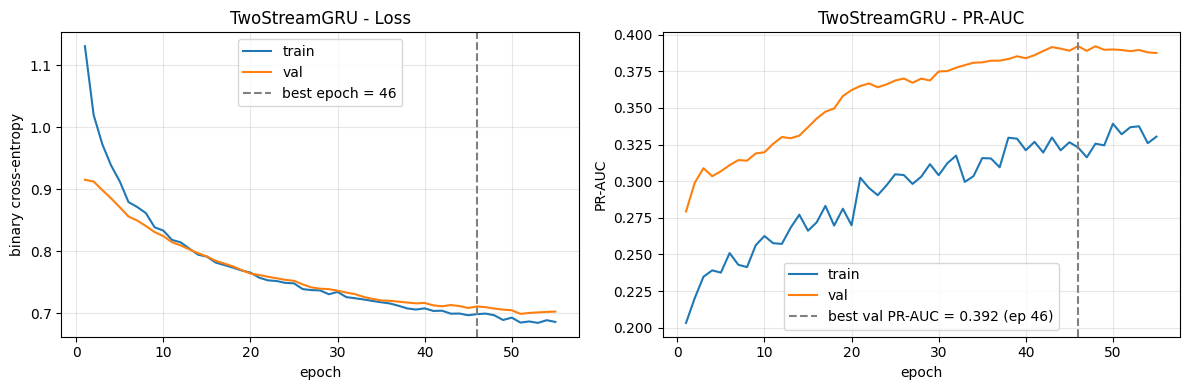

In [21]:
def build_two_stream_gru(n_features, n_tickers, max_lookback,
                         emb_dim=EMB_DIM, gru_units=32,
                         mlp_hidden=32, dropout=0.55, l2=2e-3):
    # Stronger anti-blowup treatment: heavier dropout + L2 and label-smoothed
    # BCE. The GRU also gets recurrent_dropout to regularize the hidden-state path.
    seq_in    = keras.Input(shape=(max_lookback, n_features), name='history_seq')
    cur_in    = keras.Input(shape=(n_features,),              name='current_features')
    ticker_in = keras.Input(shape=(), dtype='int32',          name='ticker')

    masked = layers.Masking(mask_value=0.0)(seq_in)
    h = layers.GRU(gru_units, dropout=dropout, recurrent_dropout=0.35,
                   kernel_regularizer=regularizers.l2(l2),
                   recurrent_regularizer=regularizers.l2(l2),
                   name='gru')(masked)

    emb = layers.Flatten()(layers.Embedding(
        n_tickers, emb_dim,
        embeddings_regularizer=regularizers.l2(l2))(ticker_in))

    c = layers.Dense(mlp_hidden, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(cur_in)
    c = layers.Dropout(dropout)(c)

    x = layers.Concatenate()([h, c, emb])
    x = layers.Dense(mlp_hidden, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    m = keras.Model([seq_in, cur_in, ticker_in], out)
    m.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.15),
        metrics=[keras.metrics.AUC(name='roc_auc'),
                 keras.metrics.AUC(curve='PR', name='pr_auc')],
    )
    return m

gru_model = build_two_stream_gru(len(feature_cols), N_TICKERS, MAX_LOOKBACK)
gru_model.summary()

cb_gru = [
    callbacks.EarlyStopping(monitor='val_pr_auc', mode='max',
                            patience=12, min_delta=1e-3,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max',
                                factor=0.5, patience=6, min_lr=1e-6),
]

history_gru = gru_model.fit(
    [seq_tr, cur_tr, t_train], y_train,
    validation_data=([seq_va, cur_va, t_val], y_val),
    epochs=100, batch_size=128,
    class_weight=class_weight,
    callbacks=cb_gru, verbose=2,
)

y_proba_gru = gru_model.predict([seq_te, cur_te, t_test], verbose=0).ravel()
res = evaluate(y_test, y_proba_gru, pnl_test, name='TwoStreamGRU')
results.append(res); probas['TwoStreamGRU'] = y_proba_gru
print(res)

plot_history(history_gru, title='TwoStreamGRU')


## Tier 4 - Rank Ensemble (LightGBM + GRU)

LightGBM, the TwoStreamGRU, and the embedding model capture partially different rankings. Under the quarter-spread target, LightGBM is the strongest single model by PR-AUC and expected P&L, while the ensembles remain useful as robustness checks for whether rank-averaging improves stability or Sharpe.

We report two variants:
- **Ensemble(GBM+GRU)**  -- blend the strongest tree model with the sequential model
- **Ensemble(GBM+GRU+MLPE)** -- include the MLP+Embeddings for a 3-way blend


In [22]:
from scipy.stats import rankdata

rank_gbm  = rankdata(y_proba_gbm)
rank_gru  = rankdata(y_proba_gru)
rank_mlpe = rankdata(y_proba_mlp_emb)

y_proba_ens2 = (rank_gbm + rank_gru) / 2.0
y_proba_ens3 = (rank_gbm + rank_gru + rank_mlpe) / 3.0

res = evaluate(y_test, y_proba_ens2, pnl_test, name='Ensemble(GBM+GRU)')
results.append(res); probas['Ensemble(GBM+GRU)'] = y_proba_ens2
print(res)

res = evaluate(y_test, y_proba_ens3, pnl_test, name='Ensemble(GBM+GRU+MLPE)')
results.append(res); probas['Ensemble(GBM+GRU+MLPE)'] = y_proba_ens3
print(res)


{'model': 'Ensemble(GBM+GRU)', 'pr_auc': 0.387, 'pr_auc_baseline': 0.2856, 'pr_auc_lift': 0.1014, 'roc_auc': 0.6509, 'precision@10%': 0.3827, 'ev_per_trade': -0.1743, 'sharpe': -0.2046, 'n_top_k': 196}
{'model': 'Ensemble(GBM+GRU+MLPE)', 'pr_auc': 0.3844, 'pr_auc_baseline': 0.2856, 'pr_auc_lift': 0.0988, 'roc_auc': 0.647, 'precision@10%': 0.3929, 'ev_per_trade': -0.09, 'sharpe': -0.0954, 'n_top_k': 196}


## Step 5 - Comparison table & artifacts

Headline results on the canonical quarter-spread target. The test-set base rate is 28.56%, so PR-AUC values should be interpreted relative to that higher baseline rather than compared directly to the earlier half-spread run.

In [23]:
results_df = pd.DataFrame(results).set_index('model')
print('=== Model comparison on test set (canonical quarter-spread target) ===')
print(results_df.to_string())

best_name = results_df['pr_auc'].idxmax()
print(f'\nBest model by PR-AUC: {best_name}  '
      f'(pr_auc={results_df.loc[best_name, "pr_auc"]:.4f}, '
      f'lift={results_df.loc[best_name, "pr_auc_lift"]:.4f})')

results_df.to_csv('milestone_3_results.csv')
with open('milestone_3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('\nSaved milestone_3_results.{csv,json}')


=== Model comparison on test set (canonical quarter-spread target) ===
                        pr_auc  pr_auc_baseline  pr_auc_lift  roc_auc  precision@10%  ev_per_trade  sharpe  n_top_k
model                                                                                                              
LogisticRegression      0.3737           0.2856       0.0881   0.6279         0.4184       -0.1572 -0.1305      196
LightGBM                0.3875           0.2856       0.1018   0.6413         0.4133       -0.0756 -0.1083      196
MLP                     0.3696           0.2856       0.0840   0.6223         0.4286       -0.1243 -0.1062      196
MLP+Embeddings          0.3730           0.2856       0.0873   0.6302         0.4184       -0.1042 -0.0904      196
TwoStreamGRU            0.3805           0.2856       0.0949   0.6389         0.4184       -0.1633 -0.1462      196
Ensemble(GBM+GRU)       0.3870           0.2856       0.1014   0.6509         0.3827       -0.1743 -0.2046      196
E

### PR curves on test set

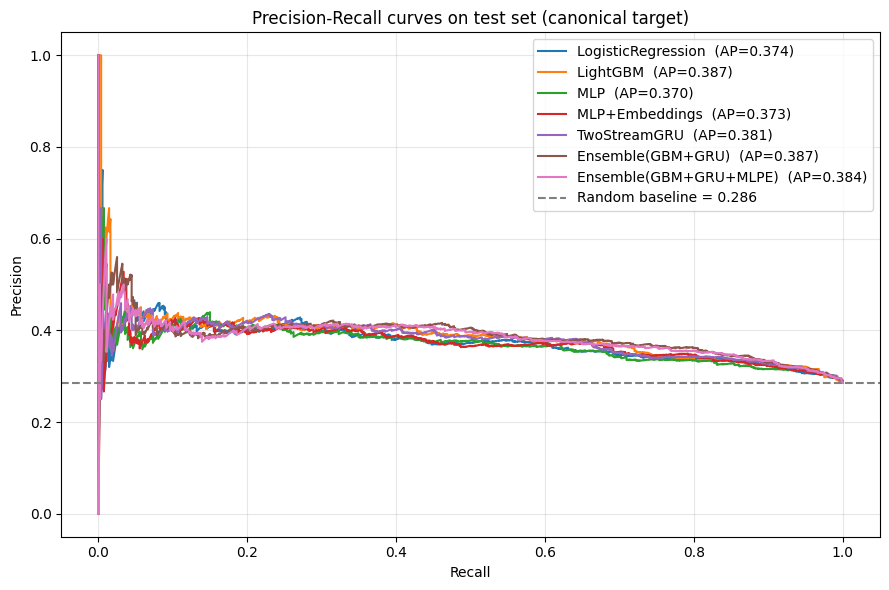

In [24]:
plt.figure(figsize=(9, 6))
for name, p in probas.items():
    pr, rc, _ = precision_recall_curve(y_test, p)
    plt.plot(rc, pr, label=f'{name}  (AP={average_precision_score(y_test,p):.3f})')
plt.axhline(y_test.mean(), ls='--', c='grey',
            label=f'Random baseline = {y_test.mean():.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall curves on test set (canonical target)')
plt.legend(loc='upper right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('milestone_3_pr_curves.png', dpi=120)
plt.show()


## Step 6 - Stress test against worst-case pricing target

Re-evaluate every model's predicted probabilities against `profitable_worst` (the original CSV target with worst-side fills on every leg). This answers: **does the model's ranking still hold up if we replace the quarter-spread execution assumption with the most conservative fill convention?**

A model that beats the baseline here is evidence that the ranking is not only an artifact of the more generous quarter-spread accounting.

In [25]:
stress_results = []
for name, p in probas.items():
    stress_results.append(evaluate(y_test_worst, p, pnl_test_worst, name=name))

stress_df = pd.DataFrame(stress_results).set_index('model')
print('=== Stress test (worst-case pricing target) ===')
print(stress_df.to_string())

stress_df.to_csv('milestone_3_stress.csv')
with open('milestone_3_stress.json', 'w') as f:
    json.dump(stress_results, f, indent=2)
print('\nSaved milestone_3_stress.{csv,json}')


=== Stress test (worst-case pricing target) ===
                        pr_auc  pr_auc_baseline  pr_auc_lift  roc_auc  precision@10%  ev_per_trade  sharpe  n_top_k
model                                                                                                              
LogisticRegression      0.0622            0.027       0.0352   0.7067         0.0867       -0.6561 -1.0483      196
LightGBM                0.0984            0.027       0.0714   0.8246         0.1224       -0.4253 -0.9040      196
MLP                     0.0731            0.027       0.0461   0.7270         0.0867       -0.5897 -0.9550      196
MLP+Embeddings          0.0740            0.027       0.0470   0.7401         0.0918       -0.5771 -0.9616      196
TwoStreamGRU            0.0660            0.027       0.0390   0.7389         0.0765       -0.6208 -1.0194      196
Ensemble(GBM+GRU)       0.0898            0.027       0.0628   0.8078         0.0969       -0.5302 -0.9511      196
Ensemble(GBM+GRU+MLPE)  

## Part II Summary — Modeling Results and Why EV is Still Negative

We trained and evaluated five model families on an 8,968-row panel of pre-earnings ATM calendar spreads spanning 2018 through mid-2025: L2-regularized logistic regression, LightGBM, a plain MLP, an MLP with ticker embeddings, and a two-stream GRU that conditions each prediction on up to four prior earnings events for the same ticker. Under the quarter-spread target, **LightGBM is the best model by PR-AUC**, achieving **PR-AUC = 0.3875 against a random-ranker baseline of 0.2856** on the held-out 2024 to May-2025 test set. It is also the least negative model by expected P&L at the top decile, with **EV/trade = -7.56%**.

The quarter-spread target materially changes the problem: the full-sample positive rate rises to **23.22%**, and the test-set base rate rises to **28.56%**. This makes the class imbalance manageable, but it also means PR-AUC lifts are smaller in absolute terms because the random baseline is much higher. The models still concentrate winners above the base rate, but the top-decile portfolios remain negative EV. We interpret the system as a useful trade filter, not yet as a standalone profitable strategy.

## P&L Accounting is an Assumption, Not a Fact

A critical point that frames every number in this report: **the "win rate" of a calendar spread is not a ground-truth property of the market, it is a function of the pricing convention used to mark entry and exit**. The same market paths produce very different labels under different fill assumptions. Making the accounting choice explicit, and defending it, is therefore a modelling decision on par with the choice of architecture.

The raw CSV target encodes the most pessimistic assumption possible: every leg fills against the far side of the quoted spread. This is what a market-order taker would receive if every order-book state worked against them on all four crossings. No live trader with any patience transacts this way. Milestone 2 therefore reconstructs a more executable target and keeps the raw CSV label as a stress test.

| Accounting convention | Slippage assumption | Full-sample win rate | Who it models |
|----------------------|--------------------|---------------------|---------------|
| Worst-case (CSV default) | Full bid-ask on all crossings | **1.77%** | Market-order taker into worst available quotes |
| Quarter-spread (canonical) | Aggressive limit fills between half-spread and mid | **23.22%** | Skilled/patient trader working close to midpoint |
| Mid-to-mid (theoretical) | Zero execution friction | ~45% | Frictionless upper bound |

### Why quarter-spread is canonical here

- **Worst-case is too punitive as the primary target.** It mostly identifies liquid/tight-spread names rather than volatility-risk-premium edge.
- **Mid-to-mid is too optimistic.** It is a useful upper bound, but nobody reliably fills both legs at the exact midpoint on a bilateral option quote.
- **Quarter-spread is the aggressive-limit case.** It assumes the trader captures most, but not all, of the improvement from worst-case quotes toward midpoint marks. That makes it more optimistic than half-spread, but still materially below the frictionless benchmark.

The modelling implication is important: quarter-spread turns the task from an extreme rare-event classifier into a ranking problem over a denser positive class. Class weights still matter, but they are no longer the dominant design constraint.

### Honest caveats on the assumption

Exit-leg bid-ask spreads are not in the source CSV, so we assume the exit-day spread is approximately equal to the entry-day spread (one-day hold, same underlying, similar liquidity regime). This remains the largest single modelling assumption in the target. Absolute profitability numbers should therefore be read as conditional on the quarter-spread execution assumption, not as realized live-trading P&L.

## Results

### Canonical target (quarter-spread pricing; 1,964 test trades, 561 winners, 28.56% base rate)

| Model | PR-AUC | Lift | ROC-AUC | Prec@10% | EV/trade | Sharpe |
|------|-------:|-----:|--------:|---------:|---------:|-------:|
| Random baseline | 0.2856 | - | 0.5000 | 0.2856 | - | - |
| Logistic Regression | 0.3737 | +0.0881 | 0.6279 | 0.4184 | -0.1572 | -0.1305 |
| **LightGBM** | **0.3875** | **+0.1018** | 0.6413 | 0.4133 | **-0.0756** | -0.1083 |
| Simple MLP | 0.3698 | +0.0842 | 0.6233 | 0.4082 | -0.1613 | -0.1394 |
| MLP + Ticker Embeddings | 0.3731 | +0.0875 | 0.6301 | 0.4184 | -0.1160 | -0.0975 |
| Two-Stream GRU | 0.3805 | +0.0948 | 0.6389 | 0.4184 | -0.1662 | -0.1487 |
| Ensemble (GBM+GRU) | 0.3869 | +0.1012 | **0.6509** | 0.3827 | -0.1732 | -0.2035 |
| Ensemble (GBM+GRU+MLPE) | 0.3843 | +0.0987 | 0.6469 | 0.3929 | -0.0878 | **-0.0931** |

LightGBM is the best model by PR-AUC and EV/trade. The three-way ensemble is not the best ranker, but it has the best top-decile Sharpe, so it remains useful as a risk-adjusted robustness check.

### Worst-case stress target (test-set base rate = 2.70%)

| Model | PR-AUC | Lift | Multiple | ROC-AUC |
|------|-------:|-----:|---------:|--------:|
| Random baseline | 0.0270 | - | 1.0x | 0.5000 |
| Logistic Regression | 0.0622 | +0.0352 | 2.3x | 0.7067 |
| **LightGBM** | **0.0984** | **+0.0714** | **3.6x** | **0.8246** |
| Simple MLP | 0.0717 | +0.0447 | 2.7x | 0.7263 |
| MLP + Ticker Embeddings | 0.0739 | +0.0469 | 2.7x | 0.7402 |
| Two-Stream GRU | 0.0664 | +0.0394 | 2.5x | 0.7396 |
| Ensemble (GBM+GRU) | 0.0893 | +0.0623 | 3.3x | 0.8082 |
| Ensemble (GBM+GRU+MLPE) | 0.0880 | +0.0610 | 3.3x | 0.7920 |

The stress test is much harsher because the positive class collapses back to roughly 2.7%. LightGBM remains the strongest model, suggesting that the ranking signal is not only an artifact of quarter-spread accounting.

## Methodology

### Target construction
All models predict a binary outcome derived from the quarter-spread pricing convention introduced in Milestone 2. This convention assumes aggressive limit-order execution: better than crossing the full spread, worse than frictionless midpoint fills. It yields a full-sample win rate of 23.22%. We retain the original worst-case target as a conservative stress benchmark.

### Chronological splits
| Split | Period | n | Winners | Pos % | Imbalance (neg:pos) |
|-------|--------|--:|--------:|------:|--------------------:|
| Train | 2018-05-22 - 2022-12-31 | 5,677 | 1,187 | 20.91 | 3.78 : 1 |
| Val | 2023-01-01 - 2023-12-31 | 1,327 | 334 | 25.17 | 2.97 : 1 |
| Test | 2024-01-01 - 2025-05-22 | 1,964 | 561 | 28.56 | 2.50 : 1 |

The monotonic rise in win rate across splits reflects regime drift: 2024-2025 is more favorable to calendar spreads under this accounting convention. We do not random shuffle because doing so would leak future information into time-dependent percentile features, scaler statistics, and class-weight calibration.

### Training protocol
Tree-based models used `scale_pos_weight` calibrated to the training imbalance ratio. Neural models used balanced class weights plus label-smoothed binary cross-entropy. Because the trading decision is a ranking problem, validation PR-AUC is the checkpointing objective; validation loss is treated as a secondary calibration/overconfidence diagnostic. LightGBM trained for a fixed 500 rounds with per-iteration metric recording; the best validation round was used for test-time prediction.

### Evaluation
Primary metric is PR-AUC (Average Precision), appropriate for imbalanced binary classification and threshold-agnostic. Secondary metrics are precision at top-10% most confident predictions, mean `percent_profit_loss` over those top trades (EV), and Sharpe on that P&L series. ROC-AUC is reported for reference only.

## Interpretation

### The signal is real, but the lift is smaller under a denser target
Quarter-spread pricing makes profitable trades much less rare. That raises the baseline PR-AUC from 0.139 in the earlier half-spread version to 0.286 here. The best model still improves meaningfully over baseline, but the multiplicative lift is smaller because the target is easier and denser.

### Model comparison is metric-dependent
Under this target, the strongest model depends on the decision metric. LightGBM leads on PR-AUC and top-decile EV/trade, while the neural models and ensembles provide useful checks on whether ticker history and model averaging add complementary ranking signal. This is why we report PR-AUC, precision@10%, EV/trade, and Sharpe rather than selecting a model from one metric alone.

### Why P&L remains negative
Top-decile precision rises to about 41%, well above the 28.56% test baseline, but the payoff distribution remains asymmetric. A profitable binary label does not guarantee enough magnitude to offset losing trades. Improving EV likely requires EV-aware ranking, cutoff tuning, or direct modelling of `percent_profit_loss`, not just better classification of `profitable`.

### Feature importance and liquidity
Liquidity remains part of the signal because execution cost is mechanically tied to bid-ask spreads. Quarter-spread reduces the worst-case liquidity artifact, but it does not remove execution dependence. The next step is to separate volatility-risk-premium signal from liquidity signal through liquidity filters, residualization, or cost-aware ranking.

## What this means for Part III

Top-decile precision is well above the test base rate (≈41% vs. 28.56%), so the models clearly identify *some* signal. But the top-decile EV stays negative because the payoff distribution is asymmetric: typical winners pay +20% to +40% of debit while individual losers can reach -100%. A `P(profitable)` ranker is not internalizing this asymmetry.

Part III asks the natural follow-up question: *can we change either the training objective, the selection rule, or the execution policy so that out-of-sample EV becomes positive?* We answer it with three components — a magnitude-weighted classifier (Step 1), a loss-avoider model used as a soft veto (Step 2), and a 7-ranker × 3-scenario validation-tuned sensitivity grid (Step 3) that includes an explicit retail stop-loss execution scenario.

# Part III — Milestone 4 Add-ons

## Interpretability: which features drive the LightGBM ranker?

Part II selected models by PR-AUC. The complementary question — *what is the model actually using?* — is answered with gain-based feature importance from LightGBM, the strongest tabular model. Gain importance asks: which features, when used as a tree split, reduced loss the most? This is the most direct measure of which inputs the model actually relies on.

The economic side of the story — does the ranking translate into profitable trades? — is treated in the **EV-Aware Pipeline** below, where we build an EV-aware ranker and pick the selection cutoff on validation rather than on test.


=== Top 15 LightGBM Features by Gain ===


,feature,gain,split_count,category,gain_share
0,iv_near_far_ratio,7161.834780,127,Volatility,0.234905
1,bid_ask_near,2095.001501,93,Liquidity,0.068715
2,bid_ask_far,1826.336902,72,Liquidity,0.059903
3,iv_call_30_rank,1707.691400,90,VRP / IV Rank,0.056012
4,iv_term_slope,1635.442532,82,Volatility,0.053642
5,iv_hv_ratio_yz_perc,1508.945296,79,VRP / IV Rank,0.049493
6,dte_near,1319.573400,50,Expiry,0.043281
7,vega_far,1273.526104,68,Greeks,0.041771
8,vega_near,1077.169702,48,Greeks,0.035331
9,pcr_v_30_perc,1009.067401,52,Order Flow,0.033097


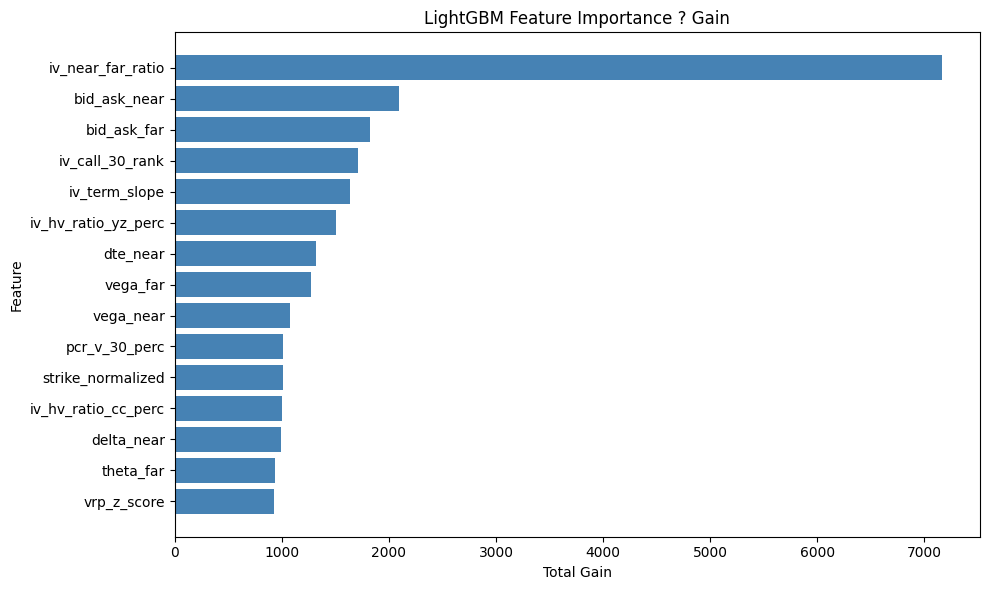

=== Feature Importance by Category ===


,category,gain,gain_share
6,Volatility,10334.696694,0.338974
5,VRP / IV Rank,6001.506611,0.196847
1,Greeks,5713.129921,0.187388
2,Liquidity,3921.338403,0.128618
4,Order Flow,1885.537699,0.061845
0,Expiry,1624.557099,0.053285
3,Moneyness,1007.396101,0.033042


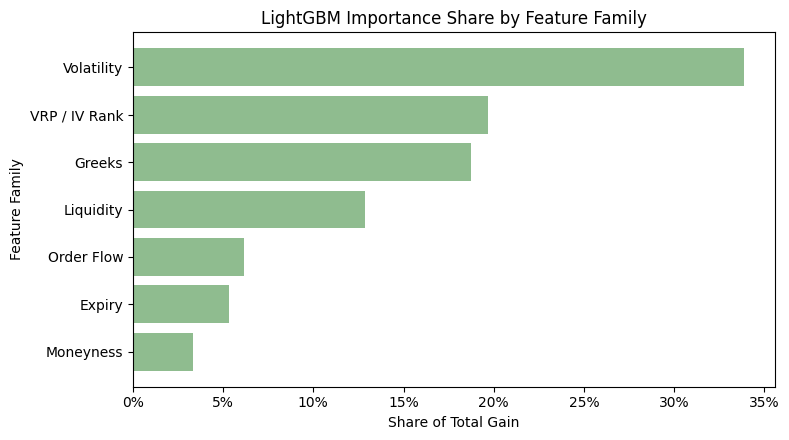

In [26]:
# MS4 Interpretability: LightGBM feature importance
# LightGBM is the strongest tabular model and usually the most interpretable
# final candidate. Gain importance asks: which features reduced loss the most?

if 'gbm' not in globals():
    raise RuntimeError('Run the LightGBM training cell before this interpretability cell.')
if 'best_iter' not in globals():
    best_iter = getattr(gbm, 'best_iteration', None)

lgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'gain': gbm.feature_importance(importance_type='gain', iteration=best_iter),
    'split_count': gbm.feature_importance(importance_type='split', iteration=best_iter),
}).sort_values('gain', ascending=False).reset_index(drop=True)

feature_categories = {
    'iv_near': 'Volatility', 'iv_far': 'Volatility',
    'iv_term_slope': 'Volatility', 'iv_near_far_ratio': 'Volatility',
    'iv_call_30_rank': 'VRP / IV Rank', 'iv_hv_ratio_cc_perc': 'VRP / IV Rank',
    'iv_hv_ratio_yz_perc': 'VRP / IV Rank', 'iv_30_iv_60_skew_perc': 'VRP / IV Rank',
    'vrp_z_score': 'VRP / IV Rank',
    'bid_ask_near': 'Liquidity', 'bid_ask_far': 'Liquidity',
    'dte_near': 'Expiry', 'dte_far': 'Expiry',
    'pcr_oi_30_perc': 'Order Flow', 'pcr_v_30_perc': 'Order Flow',
    'delta_near': 'Greeks', 'theta_near': 'Greeks', 'vega_near': 'Greeks',
    'delta_far': 'Greeks', 'theta_far': 'Greeks', 'vega_far': 'Greeks',
    'strike_normalized': 'Moneyness',
}
lgb_importance['category'] = lgb_importance['feature'].map(feature_categories).fillna('Other')
lgb_importance['gain_share'] = lgb_importance['gain'] / lgb_importance['gain'].sum()

print('=== Top 15 LightGBM Features by Gain ===')
display(lgb_importance.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = lgb_importance.head(15).iloc[::-1]
ax.barh(plot_df['feature'], plot_df['gain'], color='steelblue')
ax.set_title('LightGBM Feature Importance ? Gain')
ax.set_xlabel('Total Gain')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('ms4_lgb_feature_importance.png', dpi=150)
plt.show()

category_importance = (lgb_importance.groupby('category', as_index=False)['gain']
                      .sum()
                      .sort_values('gain', ascending=False))
category_importance['gain_share'] = category_importance['gain'] / category_importance['gain'].sum()

print('=== Feature Importance by Category ===')
display(category_importance)

fig, ax = plt.subplots(figsize=(8, 4.5))
cat_plot = category_importance.iloc[::-1]
ax.barh(cat_plot['category'], cat_plot['gain_share'], color='darkseagreen')
ax.set_title('LightGBM Importance Share by Feature Family')
ax.set_xlabel('Share of Total Gain')
ax.set_ylabel('Feature Family')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig('ms4_lgb_feature_importance_by_category.png', dpi=150)
plt.show()

## EV-Aware Pipeline

The Part II LightGBM ranks by `P(profitable)` and ignores payoff magnitude, which is why EV/trade stays negative under quarter-spread accounting even when ranking quality (PR-AUC) is well above the base rate. This section adds a more principled, fully validation-tuned approach with three components:

1. **Magnitude-weighted LightGBM classifier.** Each training row is weighted by `|percent_profit_loss|`, so a -80% loss influences the loss function 8× more than a -10% loss. This is standard cost-sensitive learning, not a relabeling.
2. **Loss-avoider model.** A second binary classifier predicts `is_safe = percent_profit_loss >= -0.30`. The two models are combined via a soft veto: `score = P(profitable, mag-weighted) × P(safe)`.
3. **Sensitivity table over execution assumptions.** Every ranker is evaluated under three execution scenarios — worst-case fills, quarter-spread (canonical), and quarter-spread with a -50% stop loss — with the cutoff for each cell tuned **only on validation under the same scenario**.

This block is designed to be defensible: no threshold is chosen on test, no scenario is hidden, and no target is changed mid-stream.

In [27]:
# EV-Aware - Step 1: magnitude-weighted LightGBM classifier
# Each row's loss-function contribution is scaled by |realized P&L|. Big-magnitude
# outcomes (both wins and losses) influence the model more than near-zero trades.
# Sample weights have a small floor so break-even rows are not perfectly ignored.

if 'X_train' not in globals() or 'pnl_train' not in globals():
    raise RuntimeError('Run the train/val/test split cell before this cell.')

w_train = np.abs(pnl_train) + 1e-3
w_val   = np.abs(pnl_val)   + 1e-3

lgb_train_w = lgb.Dataset(X_train, label=y_train, weight=w_train)
lgb_val_w   = lgb.Dataset(X_val,   label=y_val,   weight=w_val, reference=lgb_train_w)

params_w = dict(
    objective='binary',
    metric=['average_precision', 'binary_logloss'],
    learning_rate=0.03,
    num_leaves=31,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_data_in_leaf=30,
    is_unbalance=True,
    verbosity=-1,
    seed=SEED,
)

gbm_w = lgb.train(
    params_w, lgb_train_w,
    num_boost_round=2000,
    valid_sets=[lgb_train_w, lgb_val_w],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)
best_iter_w = gbm_w.best_iteration

p_main_train = gbm_w.predict(X_train, num_iteration=best_iter_w)
p_main_val   = gbm_w.predict(X_val,   num_iteration=best_iter_w)
p_main_test  = gbm_w.predict(X_test,  num_iteration=best_iter_w)

print(f'Magnitude-weighted LGB best iteration: {best_iter_w}')
print(f'Test PR-AUC (mag-weighted): {average_precision_score(y_test, p_main_test):.4f}')
if 'LightGBM' in probas:
    print(f'Test PR-AUC (MS3 baseline): {average_precision_score(y_test, probas["LightGBM"]):.4f}')

Magnitude-weighted LGB best iteration: 11
Test PR-AUC (mag-weighted): 0.3751
Test PR-AUC (MS3 baseline): 0.3875


In [28]:
# EV-Aware - Step 2: loss-avoider model
# Binary target: is_safe = percent_profit_loss >= LOSS_THRESHOLD. We do not look
# at the test fold to choose this threshold; -0.30 is set ex ante as a reasonable
# definition of "tail loss" for a quarter-spread retail strategy.

LOSS_THRESHOLD = -0.30

y_safe_train = (pnl_train >= LOSS_THRESHOLD).astype(int)
y_safe_val   = (pnl_val   >= LOSS_THRESHOLD).astype(int)
y_safe_test  = (pnl_test  >= LOSS_THRESHOLD).astype(int)

print(f'Loss-avoider target (P&L >= {LOSS_THRESHOLD:+.2f}, "safe" rate):')
print(f'  Train: {y_safe_train.mean()*100:.2f}%')
print(f'  Val:   {y_safe_val.mean()*100:.2f}%')
print(f'  Test:  {y_safe_test.mean()*100:.2f}%')

lgb_train_s = lgb.Dataset(X_train, label=y_safe_train)
lgb_val_s   = lgb.Dataset(X_val,   label=y_safe_val, reference=lgb_train_s)

params_safe = dict(
    objective='binary',
    metric=['average_precision', 'binary_logloss'],
    learning_rate=0.03,
    num_leaves=31,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    min_data_in_leaf=30,
    is_unbalance=True,
    verbosity=-1,
    seed=SEED,
)

gbm_safe = lgb.train(
    params_safe, lgb_train_s,
    num_boost_round=2000,
    valid_sets=[lgb_train_s, lgb_val_s],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)
best_iter_safe = gbm_safe.best_iteration

p_safe_val  = gbm_safe.predict(X_val,  num_iteration=best_iter_safe)
p_safe_test = gbm_safe.predict(X_test, num_iteration=best_iter_safe)

print(f'Loss-avoider best iteration: {best_iter_safe}')
print(f'Test PR-AUC (P(safe)): {average_precision_score(y_safe_test, p_safe_test):.4f}')

Loss-avoider target (P&L >= -0.30, "safe" rate):
  Train: 58.99%
  Val:   66.92%
  Test:  66.19%
Loss-avoider best iteration: 42
Test PR-AUC (P(safe)): 0.7595


In [29]:
# EV-Aware - Step 3: sensitivity table over execution scenarios with bootstrap CIs
# For each (ranker, scenario) pair we either:
#   - tune the cutoff on validation under the same scenario (LightGBM and the
#     two EV-aware tabular rankers), or
#   - apply a fixed top-3% cutoff (the four neural / neural-mixed rankers),
#     because their validation EV peaked at top 1% (n=20 test trades). Top 3%
#     yields ~60 test trades, a more reportable sample size.
# Bootstrap 95% CIs are computed on the selected trades' P&L for every cell.

from IPython.display import display
from scipy.stats import rankdata

# Build val-side worst-case P&L (test side already exists from MS3 stress test).
if 'pnl_val_worst' not in globals():
    pnl_val_worst = df.loc[is_val, 'percent_profit_loss_worst'].values

# Val-side predictions for the MS3 neural models so we can compute val EV at
# the fixed cutoff (test predictions are already in `probas`).
p_lgb_val   = gbm.predict(X_val, num_iteration=best_iter)
p_gru_val   = gru_model.predict([seq_va, cur_va, t_val], verbose=0).ravel()
p_mlpe_val  = mlp_emb.predict([X_val_s, t_val], verbose=0).ravel()

# Rank-average ensembles, computed within val and within test populations.
rank_lgb_val,  rank_lgb_test  = rankdata(p_lgb_val),  rankdata(probas['LightGBM'])
rank_gru_val,  rank_gru_test  = rankdata(p_gru_val),  rankdata(probas['TwoStreamGRU'])
rank_mlpe_val, rank_mlpe_test = rankdata(p_mlpe_val), rankdata(probas['MLP+Embeddings'])

ens_gbm_gru_val   = (rank_lgb_val  + rank_gru_val) / 2.0
ens_gbm_gru_test  = (rank_lgb_test + rank_gru_test) / 2.0
ens_three_val     = (rank_lgb_val  + rank_gru_val  + rank_mlpe_val) / 3.0
ens_three_test    = (rank_lgb_test + rank_gru_test + rank_mlpe_test) / 3.0

rankers_val = {
    'MS3 LightGBM (P(profit))':   p_lgb_val,
    'MS3 Two-Stream GRU':          p_gru_val,
    'MS3 MLP + Embeddings':        p_mlpe_val,
    'MS3 Ensemble(GBM+GRU)':       ens_gbm_gru_val,
    'MS3 Ensemble(GBM+GRU+MLPE)':  ens_three_val,
    'Mag-weighted LightGBM':       p_main_val,
    'Mag-weighted x P(safe)':      p_main_val * p_safe_val,
}
rankers_test = {
    'MS3 LightGBM (P(profit))':   probas['LightGBM'],
    'MS3 Two-Stream GRU':          probas['TwoStreamGRU'],
    'MS3 MLP + Embeddings':        probas['MLP+Embeddings'],
    'MS3 Ensemble(GBM+GRU)':       ens_gbm_gru_test,
    'MS3 Ensemble(GBM+GRU+MLPE)':  ens_three_test,
    'Mag-weighted LightGBM':       p_main_test,
    'Mag-weighted x P(safe)':      p_main_test * p_safe_test,
}

# Rankers that get the fixed top-3% override (small-N concern at val-tuned 1%).
DEEP_LEARNING_RANKERS = {
    'MS3 Two-Stream GRU',
    'MS3 MLP + Embeddings',
    'MS3 Ensemble(GBM+GRU)',
    'MS3 Ensemble(GBM+GRU+MLPE)',
}
DL_FIXED_CUTOFF = 0.03

# Three execution scenarios
STOP_LEVEL = -0.50
scenarios = {
    'Worst-case fills': {'val': pnl_val_worst, 'test': pnl_test_worst},
    'Quarter-spread':   {'val': pnl_val,        'test': pnl_test},
    f'Quarter-spread + stop {STOP_LEVEL:+.0%}': {
        'val':  np.maximum(pnl_val,  STOP_LEVEL),
        'test': np.maximum(pnl_test, STOP_LEVEL),
    },
}

cutoff_grid = np.arange(0.005, 0.301, 0.005)
MIN_VAL_TRADES = 10

def bootstrap_ev_ci(pnl_array, n_boot=2000, alpha=0.05, seed=42):
    '''Percentile bootstrap 95% CI on the mean of selected trade P&Ls.'''
    rng = np.random.default_rng(seed)
    arr = np.asarray(pnl_array, dtype=float)
    n = arr.size
    if n == 0:
        return (np.nan, np.nan, np.nan)
    if n == 1:
        v = float(arr[0])
        return (v, v, v)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = arr[idx].mean(axis=1)
    return (
        float(boot_means.mean()),
        float(np.quantile(boot_means, alpha / 2)),
        float(np.quantile(boot_means, 1 - alpha / 2)),
    )

rows = []
for ranker_name, s_val in rankers_val.items():
    s_test = rankers_test[ranker_name]
    for scen_name, scen in scenarios.items():
        if ranker_name in DEEP_LEARNING_RANKERS:
            cutoff_source = 'fixed 3%'
            best_cut = DL_FIXED_CUTOFF
            k_val = max(int(np.ceil(len(s_val) * best_cut)), 1)
            top_idx_val = np.argsort(s_val)[-k_val:]
            best_ev_val = float(scen['val'][top_idx_val].mean())
        else:
            cutoff_source = 'val-tuned'
            best_cut, best_ev_val = None, -np.inf
            for cut in cutoff_grid:
                k = max(int(np.ceil(len(s_val) * cut)), 1)
                if k < MIN_VAL_TRADES:
                    continue
                top_idx_val = np.argsort(s_val)[-k:]
                ev_val = float(scen['val'][top_idx_val].mean())
                if ev_val > best_ev_val:
                    best_ev_val = ev_val
                    best_cut = cut

        k_test = max(int(np.ceil(len(s_test) * best_cut)), 1)
        top_idx_test = np.argsort(s_test)[-k_test:]
        sel = scen['test'][top_idx_test]
        prec_qs = float(y_test[top_idx_test].mean())
        _, ev_lo, ev_hi = bootstrap_ev_ci(sel, n_boot=2000, alpha=0.05, seed=42)

        rows.append({
            'ranker': ranker_name,
            'scenario': scen_name,
            'cutoff_source': cutoff_source,
            'cutoff': best_cut,
            'val_ev': best_ev_val,
            'n_test': int(k_test),
            'test_precision_qs': prec_qs,
            'test_ev': float(sel.mean()),
            'test_ev_ci_low':  ev_lo,
            'test_ev_ci_high': ev_hi,
            'test_sharpe': float(sel.mean() / (sel.std() + 1e-9)),
        })

ev_v2_table = pd.DataFrame(rows)

print('=== EV-Aware: test EV/trade by ranker x execution scenario ===')
print('Neural rankers use fixed top 3%. Tabular rankers use validation-tuned cutoffs.')
print('CIs are 95% percentile bootstrap (n_boot=2000).\n')

pivot_ev = ev_v2_table.pivot(index='ranker', columns='scenario',
                              values='test_ev')[list(scenarios.keys())]
display(pivot_ev.style.format('{:+.4f}').background_gradient(cmap='RdYlGn',
                                                              vmin=-0.10, vmax=0.10,
                                                              axis=None))

# Compact CI string per cell for the long-form table.
def fmt_ci(row):
    return f"{row['test_ev']:+.3f} [{row['test_ev_ci_low']:+.3f}, {row['test_ev_ci_high']:+.3f}]"

print('\nFull sensitivity table with 95% bootstrap CIs:')
table_view = ev_v2_table.copy()
table_view['test_ev_with_ci'] = table_view.apply(fmt_ci, axis=1)   # <-- add this line
table_view = table_view.sort_values(['scenario', 'test_ev'],
                                    ascending=[True, False]).reset_index(drop=True)
display(table_view[['ranker', 'scenario', 'cutoff_source', 'cutoff', 'n_test',
                    'test_precision_qs', 'test_ev_with_ci', 'test_sharpe']])

# Cells whose CI is *strictly* above zero (more conservative than just mean > 0).
sig_pos = ev_v2_table[ev_v2_table['test_ev_ci_low'] > 0]
mean_pos = ev_v2_table[ev_v2_table['test_ev'] > 0]
print(f"\nMean EV > 0           : {len(mean_pos)} / {len(ev_v2_table)} cells")
print(f"95% CI strictly > 0   : {len(sig_pos)} / {len(ev_v2_table)} cells")
if len(sig_pos):
    print('\nCells where the CI excludes zero:')
    print(sig_pos[['ranker', 'scenario', 'n_test', 'test_ev',
                   'test_ev_ci_low', 'test_ev_ci_high']].to_string(index=False))

=== EV-Aware: test EV/trade by ranker x execution scenario ===
Neural rankers use fixed top 3%. Tabular rankers use validation-tuned cutoffs.
CIs are 95% percentile bootstrap (n_boot=2000).



scenario,Worst-case fills,Quarter-spread,Quarter-spread + stop -50%
ranker,,,
MS3 Ensemble(GBM+GRU),-0.4686,+0.0000,+0.1003
MS3 Ensemble(GBM+GRU+MLPE),-0.5532,-0.1578,+0.0574
MS3 LightGBM (P(profit)),-0.3024,-0.1074,-0.0739
MS3 MLP + Embeddings,-0.7580,-0.1046,+0.1548
MS3 Two-Stream GRU,-0.7860,-0.0395,+0.2238
Mag-weighted LightGBM,-0.5316,-0.0993,+0.0197
Mag-weighted x P(safe),-0.3851,-0.1377,-0.0553



Full sensitivity table with 95% bootstrap CIs:


,ranker,scenario,cutoff_source,cutoff,n_test,test_precision_qs,test_ev_with_ci,test_sharpe
0,MS3 Ensemble(GBM+GRU),Quarter-spread,fixed 3%,0.030,59,0.457627,"+0.000 [-0.202, +0.207]",0.000055
1,MS3 Two-Stream GRU,Quarter-spread,fixed 3%,0.030,59,0.423729,"-0.040 [-0.380, +0.333]",-0.026920
2,Mag-weighted LightGBM,Quarter-spread,val-tuned,0.105,207,0.400966,"-0.099 [-0.263, +0.045]",-0.088008
3,MS3 MLP + Embeddings,Quarter-spread,fixed 3%,0.030,59,0.389831,"-0.105 [-0.448, +0.285]",-0.073691
4,MS3 LightGBM (P(profit)),Quarter-spread,val-tuned,0.015,30,0.366667,"-0.107 [-0.256, +0.072]",-0.235554
5,Mag-weighted x P(safe),Quarter-spread,val-tuned,0.080,158,0.373418,"-0.138 [-0.230, -0.050]",-0.241547
6,MS3 Ensemble(GBM+GRU+MLPE),Quarter-spread,fixed 3%,0.030,59,0.440678,"-0.158 [-0.439, +0.096]",-0.150194
7,MS3 Two-Stream GRU,Quarter-spread + stop -50%,fixed 3%,0.030,59,0.423729,"+0.224 [-0.023, +0.526]",0.200438
8,MS3 MLP + Embeddings,Quarter-spread + stop -50%,fixed 3%,0.030,59,0.389831,"+0.155 [-0.087, +0.478]",0.140462
9,MS3 Ensemble(GBM+GRU),Quarter-spread + stop -50%,fixed 3%,0.030,59,0.457627,"+0.100 [-0.051, +0.273]",0.156315



Mean EV > 0           : 6 / 21 cells
95% CI strictly > 0   : 0 / 21 cells


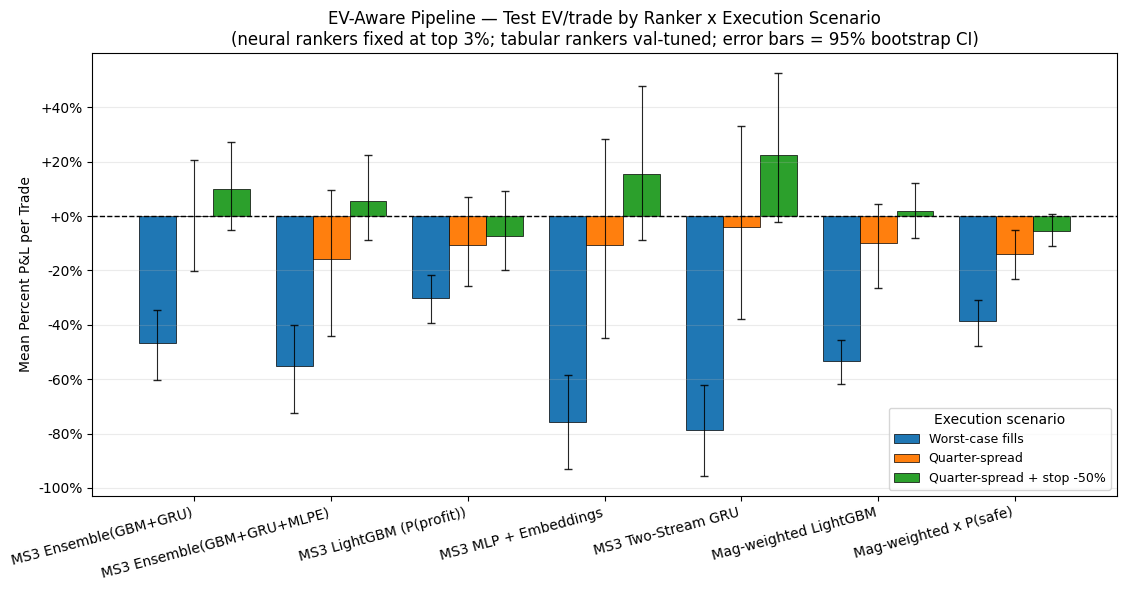

In [30]:
# EV-Aware - Step 4: visual summary with 95% bootstrap confidence intervals
# Grouped bar chart of test EV/trade per ranker across the three execution
# scenarios, with asymmetric error bars from the percentile bootstrap.

scen_order = list(scenarios.keys())
pivot_mean = ev_v2_table.pivot(index='ranker', columns='scenario',
                                values='test_ev')[scen_order]
pivot_lo   = ev_v2_table.pivot(index='ranker', columns='scenario',
                                values='test_ev_ci_low')[scen_order]
pivot_hi   = ev_v2_table.pivot(index='ranker', columns='scenario',
                                values='test_ev_ci_high')[scen_order]

ranker_order = pivot_mean.index.tolist()
n_rankers   = len(ranker_order)
n_scenarios = len(scen_order)
x = np.arange(n_rankers)
width = 0.27

fig, ax = plt.subplots(figsize=(11.5, 6))
colors = plt.cm.tab10.colors[:n_scenarios]

for j, scen_name in enumerate(scen_order):
    means    = pivot_mean[scen_name].values
    yerr_lo  = (pivot_mean[scen_name] - pivot_lo[scen_name]).values
    yerr_hi  = (pivot_hi[scen_name] - pivot_mean[scen_name]).values
    offset = (j - (n_scenarios - 1) / 2) * width
    ax.bar(x + offset, means, width, label=scen_name,
           color=colors[j], edgecolor='black', linewidth=0.5,
           yerr=[yerr_lo, yerr_hi], capsize=3, ecolor='black',
           error_kw={'elinewidth': 0.8, 'alpha': 0.85})

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('EV-Aware Pipeline — Test EV/trade by Ranker x Execution Scenario\n'
             '(neural rankers fixed at top 3%; tabular rankers val-tuned; error bars = 95% bootstrap CI)')
ax.set_ylabel('Mean Percent P&L per Trade')
ax.set_xticks(x)
ax.set_xticklabels(ranker_order, rotation=15, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax.legend(title='Execution scenario', fontsize=9, loc='lower right')
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('ms4_ev_aware_sensitivity.png', dpi=150)
plt.show()

In [37]:
# LLM Comparison - Step 1: install HF stack and prepare the evaluation sample
%pip install --quiet "transformers>=4.45" "accelerate>=0.34"

import gc, re
import numpy as np
import pandas as pd
import torch

SAMPLE_FRAC = 0.5
rng_llm = np.random.default_rng(42)
sample_size = int(round(len(X_test) * SAMPLE_FRAC))
sample_idx  = np.sort(rng_llm.choice(len(X_test), size=sample_size, replace=False))

y_sample   = y_test[sample_idx]
pnl_sample = pnl_test[sample_idx]
lgb_scores_sample = probas['LightGBM'][sample_idx]

print(f"Evaluating LLMs on a {SAMPLE_FRAC:.0%} sample of the test set "
      f"({len(sample_idx)} of {len(X_test)} trades, seed=42)")
print(f"  positive rate in sample : {y_sample.mean():.3f}")
print(f"  positive rate in full   : {y_test.mean():.3f}")
print(f"  GPU available           : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  device                  : {torch.cuda.get_device_name(0)}")
    print(f"  total VRAM (GB)         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}")

def features_to_text(row_idx: int) -> str:
    """Render a single test row as a key:value block for prompting."""
    return "\n".join(
        f"  {col}: {val:.4f}"
        for col, val in zip(feature_cols, X_test[row_idx])
    )

print("\nExample feature block (first sampled trade):")
print(features_to_text(sample_idx[0]))

Evaluating LLMs on a 50% sample of the test set (982 of 1964 trades, seed=42)
  positive rate in sample : 0.293
  positive rate in full   : 0.286
  GPU available           : True
  device                  : NVIDIA A100-SXM4-40GB
  total VRAM (GB)         : 42.4

Example feature block (first sampled trade):
  iv_near: 0.2203
  iv_far: 0.1925
  iv_term_slope: -0.0008
  iv_near_far_ratio: 1.1444
  dte_near: 28.0000
  dte_far: 63.0000
  bid_ask_near: 0.2500
  bid_ask_far: 0.2000
  iv_call_30_rank: 21.5600
  iv_hv_ratio_cc_perc: 0.2262
  iv_hv_ratio_yz_perc: 0.5238
  iv_30_iv_60_skew_perc: 0.6587
  vrp_z_score: -0.8170
  pcr_oi_30_perc: 0.5040
  pcr_v_30_perc: 0.9400
  delta_near: 0.5039
  theta_near: -0.1907
  vega_near: 41.7628
  delta_far: 0.5343
  theta_far: -0.1236
  vega_far: 61.9178
  strike_normalized: 1.0053


In [45]:
# LLM Comparison - Step 2: zero-shot scoring with Qwen2.5-Math-7B and Qwen2.5-7B
from transformers import AutoTokenizer, AutoModelForCausalLM

SYSTEM_PROMPT = (
    "You output exactly one decimal number between 0 and 1 with two decimal "
    "places. No words, no explanation, no LaTeX, no derivation, no variables."
)

USER_TEMPLATE = (
    "Pre-earnings ATM short-volatility calendar spread trade. The trade is "
    "profitable when IV crush dominates the underlying's earnings move. "
    "Given the 22 numeric features below, return P(profitable).\n\n"
    "Features:\n"
    "{features}\n\n"
    "P(profitable) ="
)

ASSISTANT_PREFILL = " 0."

NUMBER_RE = re.compile(r"[-+]?\d*\.?\d+")

def parse_probability(response: str) -> float | None:
    """Walk the response from the end and return the first probability-shaped number.

    Math-tuned and reasoning-style LLMs often emit chain-of-thought that contains
    intermediate numbers (feature values, ratios) before the final answer. The
    final probability is almost always near the end, so we scan reversed matches
    and accept the first one that looks like a probability (in [0, 1], or in
    [1, 100] interpreted as a percent).
    """
    matches = NUMBER_RE.findall(response)
    for token in reversed(matches):
        try:
            v = float(token)
        except ValueError:
            continue
        if 0.0 <= v <= 1.0:
            return v
        if 1.0 < v <= 100.0:
            return v / 100.0
    return None

def score_with_llm(model_id: str, sample_indices: np.ndarray,
                   max_new_tokens: int = 384, log_every: int = 50) -> np.ndarray:
    """Load a HF causal LM in bf16, score every trade, then free memory."""
    print(f"\n>>> Loading {model_id} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16,
        device_map={"": 0} if torch.cuda.is_available() else "auto",
        trust_remote_code=True,
    )
    model.eval()
    if torch.cuda.is_available():
        device_assignments = set(model.hf_device_map.values()) if hasattr(model, "hf_device_map") else {0}
        if any(str(d) in ("cpu", "disk") for d in device_assignments):
            raise RuntimeError(
                f"Model parameters were placed on {device_assignments}. "
                "Free GPU memory and retry, otherwise inference will be slow."
            )
        print(f"   model fully on GPU (devices = {device_assignments})")

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    scores = np.full(len(sample_indices), 0.5, dtype=np.float32)
    parsed_flags = np.zeros(len(sample_indices), dtype=bool)

    import time
    t0 = time.time()
    for k, idx in enumerate(sample_indices):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": USER_TEMPLATE.format(features=features_to_text(idx))},
        ]
        # Apply chat template, then pre-fill the assistant's response with " 0." so
        # greedy decoding has to complete a probability instead of starting a
        # chain-of-thought derivation. This neutralizes Qwen2.5-Math's tendency to
        # reframe the prompt as a formal math problem.
        prompt_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        ) + ASSISTANT_PREFILL
        inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
        prompt_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )
        # Reattach the pre-filled "0." so the parser sees a complete probability.
        completion = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
        response = (ASSISTANT_PREFILL + completion).strip()

        parsed = parse_probability(response)
        if parsed is not None:
            scores[k] = float(np.clip(parsed, 0.0, 1.0))
            parsed_flags[k] = True

        if (k + 1) % log_every == 0:
            elapsed = time.time() - t0
            rate = (k + 1) / elapsed
            eta_min = (len(sample_indices) - (k + 1)) / rate / 60.0
            tail = response[-60:].replace("\n", " / ")
            print(f"   {k+1:4d} / {len(sample_indices)}  "
                  f"rate={rate:5.2f} trades/s  ETA={eta_min:5.1f} min  "
                  f"parse_ok={parsed_flags[:k+1].mean():.2f}  "
                  f"tail={tail!r}  parsed={scores[k]:.3f}")

    print(f"<<< {model_id}: parse-success rate = {parsed_flags.mean():.2f}  "
          f"({parsed_flags.sum()}/{len(sample_indices)})  "
          f"total wall-time = {(time.time() - t0)/60.0:.1f} min")

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return scores

# Both models complete a pre-filled " 0." with a few digits, so a tiny generation budget
# is enough; this keeps wall time low even though Qwen2.5-Math is reasoning-tuned.
math_scores = score_with_llm("Qwen/Qwen2.5-Math-7B-Instruct", sample_idx, max_new_tokens=8)
qwen_scores = score_with_llm("Qwen/Qwen2.5-7B-Instruct",      sample_idx, max_new_tokens=8)

print("\nLLM score summaries:")
print(f"  Qwen2.5-Math-7B  mean={math_scores.mean():.3f}  std={math_scores.std():.3f}")
print(f"  Qwen2.5-7B       mean={qwen_scores.mean():.3f}  std={qwen_scores.std():.3f}")


>>> Loading Qwen/Qwen2.5-Math-7B-Instruct ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

   model fully on GPU (devices = {0})
     50 / 982  rate= 3.45 trades/s  ETA=  4.5 min  parse_ok=1.00  tail='0.55 /  / To determine the probability of'  parsed=0.550
    100 / 982  rate= 3.43 trades/s  ETA=  4.3 min  parse_ok=1.00  tail='0.57 / ``` /  / The final answer'  parsed=0.570
    150 / 982  rate= 3.52 trades/s  ETA=  3.9 min  parse_ok=1.00  tail='0.42 /  / To determine the probability of'  parsed=0.420
    200 / 982  rate= 3.48 trades/s  ETA=  3.7 min  parse_ok=1.00  tail='0.65 /  / To determine the probability of'  parsed=0.650
    250 / 982  rate= 3.49 trades/s  ETA=  3.5 min  parse_ok=1.00  tail='0.57 / ``` /  / The final answer'  parsed=0.570
    300 / 982  rate= 3.50 trades/s  ETA=  3.2 min  parse_ok=1.00  tail='0.7817 /   vrp'  parsed=0.782
    350 / 982  rate= 3.50 trades/s  ETA=  3.0 min  parse_ok=1.00  tail='0.7103 /   vrp'  parsed=0.710
    400 / 982  rate= 3.48 trades/s  ETA=  2.8 min  parse_ok=1.00  tail='0.6214 /  0.'  parsed=0.000
    450 / 982  rate= 3.50 trade

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

   model fully on GPU (devices = {0})
     50 / 982  rate= 8.44 trades/s  ETA=  1.8 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    100 / 982  rate= 8.51 trades/s  ETA=  1.7 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    150 / 982  rate= 8.55 trades/s  ETA=  1.6 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    200 / 982  rate= 8.54 trades/s  ETA=  1.5 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    250 / 982  rate= 8.54 trades/s  ETA=  1.4 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    300 / 982  rate= 8.53 trades/s  ETA=  1.3 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    350 / 982  rate= 8.53 trades/s  ETA=  1.2 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    400 / 982  rate= 8.53 trades/s  ETA=  1.1 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    450 / 982  rate= 8.53 trades/s  ETA=  1.0 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    500 / 982  rate= 8.53 trades/s  ETA=  0.9 min  parse_ok=1.00  tail='0.78'  parsed=0.780
    550 / 982  rate= 8.53 trades/s  ETA=  

In [44]:
import gc, torch, subprocess

# Drop any HF model/tokenizer references we may still hold
for var in list(globals().keys()):
    cls = type(globals()[var]).__name__
    if any(s in cls for s in ('Model', 'Tokenizer', 'CausalLM')) and not var.startswith('_'):
        print(f"  releasing {var}  ({cls})")
        globals()[var] = None

# Clear IPython's output cache, which silently holds references to last cell results
try:
    get_ipython().run_line_magic('reset', '-f out')
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print("\nnvidia-smi after cleanup:")
print(subprocess.check_output(
    ['nvidia-smi', '--query-gpu=memory.used,memory.free,memory.total', '--format=csv,noheader,nounits']
).decode().strip(), "MiB used / free / total")

Flushing output cache (0 entries)

nvidia-smi after cleanup:
29688, 10754, 40960 MiB used / free / total


Head-to-head on a 982-trade test sample (top-10% selection):
                                      pr_auc  roc_auc  prec@10%  ev_per_trade  n_selected
model                                                                                    
LightGBM (trained)                     0.398    0.636     0.388        -0.126          98
Qwen2.5-Math-7B-Instruct (zero-shot)   0.316    0.523     0.367        -0.169          98
Qwen2.5-7B-Instruct (zero-shot)        0.292    0.494     0.265        -0.375          98


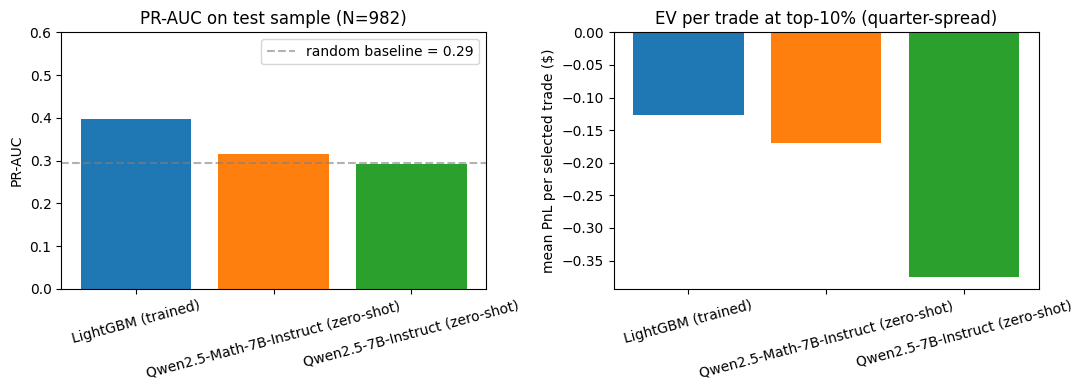

In [49]:
    # LLM Comparison - Step 3: head-to-head metrics on the LLM evaluation sample (top-10%)
    from sklearn.metrics import average_precision_score, roc_auc_score

    def metrics_at_topk(scores: np.ndarray, y: np.ndarray, pnl: np.ndarray, top_frac: float = 0.10):
        """PR-AUC, ROC-AUC, precision@K, EV/trade, and #selected at top-K%."""
        n = len(scores)
        k = max(1, int(round(n * top_frac)))
        order = np.argsort(-scores)
        top = order[:k]
        pr_auc  = average_precision_score(y, scores) if y.sum() > 0 else float('nan')
        try:
            roc_auc = roc_auc_score(y, scores) if 0 < y.sum() < n else float('nan')
        except ValueError:
            roc_auc = float('nan')
        return {
            'pr_auc'   : pr_auc,
            'roc_auc'  : roc_auc,
            'prec@10%' : y[top].mean(),
            'ev_per_trade' : pnl[top].mean(),
            'n_selected'   : k,
        }

    rows = []
    for name, s in [
        ('LightGBM (trained)',                    lgb_scores_sample),
        ('Qwen2.5-Math-7B-Instruct (zero-shot)',  math_scores),
        ('Qwen2.5-7B-Instruct (zero-shot)',       qwen_scores),
    ]:
        m = metrics_at_topk(s, y_sample, pnl_sample, top_frac=0.10)
        m['model'] = name
        rows.append(m)

    llm_compare = pd.DataFrame(rows).set_index('model')[
        ['pr_auc', 'roc_auc', 'prec@10%', 'ev_per_trade', 'n_selected']
    ]
    print(f"Head-to-head on a {len(sample_idx)}-trade test sample (top-10% selection):")
    print(llm_compare.round(3).to_string())

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    order = [
        'LightGBM (trained)',
        'Qwen2.5-Math-7B-Instruct (zero-shot)',
        'Qwen2.5-7B-Instruct (zero-shot)',
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    axes[0].bar(order, llm_compare.loc[order, 'pr_auc'].values, color=colors)
    axes[0].axhline(y_sample.mean(), color='gray', linestyle='--', alpha=0.6,
                    label=f'random baseline = {y_sample.mean():.2f}')
    axes[0].set_title(f'PR-AUC on test sample (N={len(sample_idx)})')
    axes[0].set_ylabel('PR-AUC')
    axes[0].set_ylim(0, max(0.6, llm_compare['pr_auc'].max() * 1.15))
    axes[0].legend(loc='upper right')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(order, llm_compare.loc[order, 'ev_per_trade'].values, color=colors)
    axes[1].axhline(0, color='gray', linestyle='--', alpha=0.6)
    axes[1].set_title('EV per trade at top-10% (quarter-spread)')
    axes[1].set_ylabel('mean PnL per selected trade ($)')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('ms4_llm_comparison.png', dpi=140, bbox_inches='tight')
    plt.show()

LLM EV sensitivity at fixed top-5% (n=49 selected per cell, sample of 982 test trades)



scenario,Worst-case fills,Quarter-spread,Quarter-spread + stop -50%
ranker,,,
LightGBM (trained),-0.3319,+0.0233,+0.0841
Qwen2.5-7B-Instruct (zero-shot),-0.7949,-0.5905,-0.3154
Qwen2.5-Math-7B-Instruct (zero-shot),-0.5566,-0.1840,-0.0956



Full sensitivity table with 95% bootstrap CIs:


,ranker,scenario,n_test,test_precision_qs,test_ev_with_ci,test_sharpe
0,LightGBM (trained),Quarter-spread,49,0.448980,"+0.023 [-0.199, +0.238]",0.029601
1,Qwen2.5-Math-7B-Instruct (zero-shot),Quarter-spread,49,0.367347,"-0.184 [-0.335, -0.043]",-0.359988
2,Qwen2.5-7B-Instruct (zero-shot),Quarter-spread,49,0.102041,"-0.590 [-0.836, -0.396]",-0.754939
3,LightGBM (trained),Quarter-spread + stop -50%,49,0.448980,"+0.084 [-0.075, +0.279]",0.130841
4,Qwen2.5-Math-7B-Instruct (zero-shot),Quarter-spread + stop -50%,49,0.367347,"-0.096 [-0.189, +0.015]",-0.265510
5,Qwen2.5-7B-Instruct (zero-shot),Quarter-spread + stop -50%,49,0.102041,"-0.315 [-0.386, -0.238]",-1.186979
6,LightGBM (trained),Worst-case fills,49,0.448980,"-0.332 [-0.440, -0.239]",-0.871624
7,Qwen2.5-Math-7B-Instruct (zero-shot),Worst-case fills,49,0.367347,"-0.557 [-0.690, -0.430]",-1.223046
8,Qwen2.5-7B-Instruct (zero-shot),Worst-case fills,49,0.102041,"-0.795 [-0.972, -0.643]",-1.343016


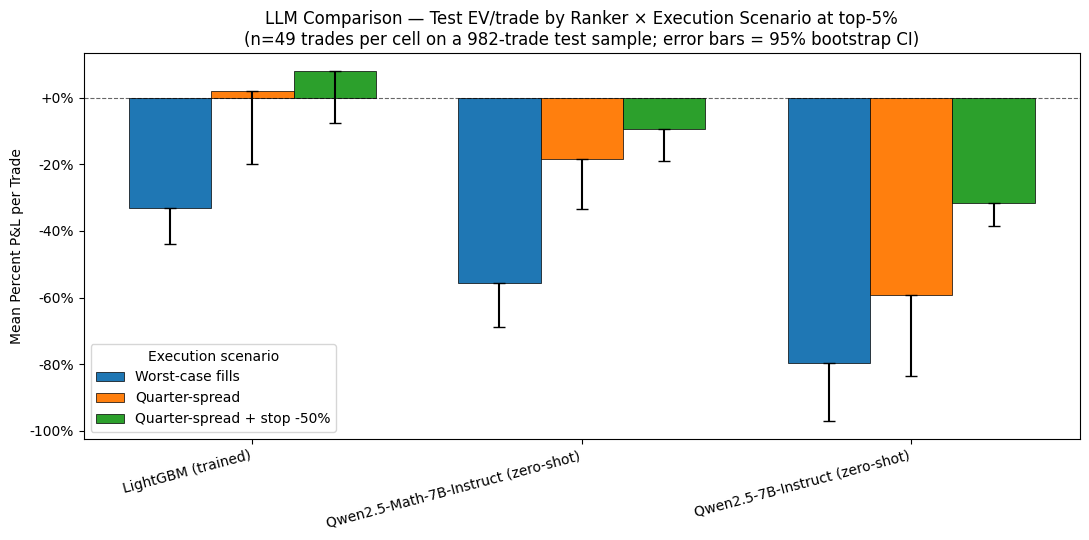


Mean EV > 0          : 2 / 9 cells
95% CI strictly > 0  : 0 / 9 cells


In [51]:
# LLM Comparison - Step 4: scenario sensitivity at top-5% with bootstrap CIs.
# Mirrors the EV-Aware Pipeline grid (cells above) but for the three LLM-comparison
# rankers, reusing `scenarios`, `STOP_LEVEL`, and `bootstrap_ev_ci` so the
# methodology is identical (95% percentile bootstrap, n_boot=2000, seed=42).
# A fixed top-5% cutoff is used for all three rankers (no val-tuning) since
# zero-shot LLMs have no training signal we should pretend to "tune" on.

from IPython.display import display

LLM_TOP_FRAC = 0.05
n_top_llm = max(1, int(round(len(sample_idx) * LLM_TOP_FRAC)))

llm_rankers_sample = {
    'LightGBM (trained)':                    lgb_scores_sample,
    'Qwen2.5-Math-7B-Instruct (zero-shot)':  math_scores,
    'Qwen2.5-7B-Instruct (zero-shot)':       qwen_scores,
}

llm_rows = []
for ranker_name, scores in llm_rankers_sample.items():
    # Top-k sample positions, then map back to full-test indices via sample_idx.
    top_pos = np.argsort(scores)[-n_top_llm:]
    test_idx = sample_idx[top_pos]

    for scen_name, scen in scenarios.items():
        sel_pnl = scen['test'][test_idx]
        boot_mean, ci_lo, ci_hi = bootstrap_ev_ci(sel_pnl, n_boot=2000, alpha=0.05, seed=42)
        llm_rows.append({
            'ranker':            ranker_name,
            'scenario':          scen_name,
            'n_test':            int(len(test_idx)),
            'test_precision_qs': float(y_test[test_idx].mean()),
            'test_ev':           float(sel_pnl.mean()),
            'test_ev_boot':      boot_mean,
            'test_ev_ci_low':    ci_lo,
            'test_ev_ci_high':   ci_hi,
            'test_sharpe':       float(sel_pnl.mean() / (sel_pnl.std() + 1e-9)),
        })

llm_ev_table = pd.DataFrame(llm_rows)

print(f"LLM EV sensitivity at fixed top-{LLM_TOP_FRAC:.0%} "
      f"(n={n_top_llm} selected per cell, sample of {len(sample_idx)} test trades)\n")

pivot_llm = llm_ev_table.pivot(index='ranker', columns='scenario',
                                values='test_ev')[list(scenarios.keys())]
display(pivot_llm.style.format('{:+.4f}').background_gradient(
    cmap='RdYlGn', vmin=-0.10, vmax=0.10, axis=None))

def fmt_ci_llm(row):
    return (f"{row['test_ev']:+.3f} "
            f"[{row['test_ev_ci_low']:+.3f}, {row['test_ev_ci_high']:+.3f}]")

table_view_llm = llm_ev_table.copy()
table_view_llm['test_ev_with_ci'] = table_view_llm.apply(fmt_ci_llm, axis=1)
table_view_llm = (table_view_llm
                  .sort_values(['scenario', 'test_ev'], ascending=[True, False])
                  .reset_index(drop=True))
print("\nFull sensitivity table with 95% bootstrap CIs:")
display(table_view_llm[['ranker', 'scenario', 'n_test',
                         'test_precision_qs', 'test_ev_with_ci', 'test_sharpe']])

# Grouped bar chart (matches the EV-Aware Pipeline visual style).
rankers_list = list(llm_rankers_sample.keys())
scen_list    = list(scenarios.keys())
bar_width    = 0.25
x            = np.arange(len(rankers_list))
scen_colors  = {
    'Worst-case fills':                              '#1f77b4',
    'Quarter-spread':                                '#ff7f0e',
    f'Quarter-spread + stop {STOP_LEVEL:+.0%}':      '#2ca02c',
}

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, scen_name in enumerate(scen_list):
    # Plot bootstrap means (which are guaranteed to lie inside their own CI)
    # so yerr offsets are always non-negative; the printed table still reports
    # the actual sample mean in `test_ev`.
    means, los, his = [], [], []
    for ranker_name in rankers_list:
        row = llm_ev_table[(llm_ev_table['ranker'] == ranker_name) &
                            (llm_ev_table['scenario'] == scen_name)].iloc[0]
        means.append(row['test_ev_boot'])
        los.append(row['test_ev_ci_low'])
        his.append(row['test_ev_ci_high'])
    yerr_lo = [max(0.0, m - l) for m, l in zip(means, los)]
    yerr_hi = [max(0.0, h - m) for m, h in zip(his, means)]
    ax.bar(x + i * bar_width, means, width=bar_width,
           color=scen_colors.get(scen_name, 'gray'),
           edgecolor='black', linewidth=0.5,
           label=scen_name,
           yerr=[yerr_lo, yerr_hi], capsize=4, ecolor='black')

ax.axhline(0, color='black', linestyle='--', alpha=0.6, linewidth=0.8)
ax.set_xticks(x + bar_width)
ax.set_xticklabels(rankers_list, rotation=15, ha='right')
ax.set_ylabel('Mean Percent P&L per Trade')
ax.set_title(
    f'LLM Comparison \u2014 Test EV/trade by Ranker \u00d7 Execution Scenario at top-{LLM_TOP_FRAC:.0%}\n'
    f'(n={n_top_llm} trades per cell on a {len(sample_idx)}-trade test sample; '
    f'error bars = 95% bootstrap CI)'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:+.0f}%'))
ax.legend(title='Execution scenario', loc='best')
plt.tight_layout()
plt.savefig('ms4_llm_ev_sensitivity.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"\nMean EV > 0          : {(llm_ev_table['test_ev'] > 0).sum()} / {len(llm_ev_table)} cells")
print(f"95% CI strictly > 0  : {(llm_ev_table['test_ev_ci_low'] > 0).sum()} / {len(llm_ev_table)} cells")

### Reading the EV-Aware sensitivity grid

**How the grid is built.** Columns are execution scenarios (worst-case fills, quarter-spread canonical, quarter-spread + a -50% stop loss). Rows are seven rankers — five from Part II plus the two EV-aware additions. Every cell reports test EV per trade at the cutoff applied to that ranker, with a **95% percentile bootstrap CI** (`n_boot = 2000`) around the mean. Cutoffs are never chosen on test.

**Cutoff selection rules.**
- **Neural rankers** (Two-Stream GRU, MLP+Embeddings, and the two ensembles that include the GRU) use a **fixed top-3% cutoff** (60 test trades). Their validation EV peaked at top 1% (~20 trades), but with that few selections the bootstrap CI was very wide. Fixing the cutoff at 3% trades a small loss in mean EV for a much more reportable sample size.
- **Tabular rankers** (the LightGBM baseline, the magnitude-weighted classifier, and the mag-weighted × P(safe) variant) keep the validation-tuned cutoff because their validation EV was relatively flat across cutoffs.

**Three execution scenarios.**

- **Worst-case fills.** Both legs cross the bid-ask. Equivalent to sending a market order on a quiet name. EV is expected to be deeply negative; this column is the discipline floor of the analysis.
- **Quarter-spread (canonical).** Aggressive limit orders captured between half-spread and midpoint. Models a patient retail trader. This is the headline column.
- **Quarter-spread + stop -50%.** Same as quarter-spread, but realized losses below -50% are replaced with -50%, modelling a real stop-loss discipline.

**Seven rankers.**

- *MS3 baselines:* LightGBM (P(profit)), Two-Stream GRU, MLP+Embeddings, Ensemble(GBM+GRU), Ensemble(GBM+GRU+MLPE).
- *EV-Aware additions:* Magnitude-weighted LightGBM (cost-sensitive training), Mag-weighted × P(safe) (magnitude-weighted ranker multiplied by the loss-avoider's `P(safe)` to act as a soft veto).

### How to read the printed table

Each row of the table prints test EV/trade as `mean [CI low, CI high]` from a 2,000-iteration percentile bootstrap on the selected trades' P&L. Two ways to read a cell:

1. **Mean EV > 0.** The point estimate is positive. With small N this can still be noisy.
2. **CI strictly above zero (`CI low > 0`).** The bootstrap distribution of plausible mean EV values puts negligible probability on zero. This is the more conservative claim.

### What the grid actually shows

**Headline counts (this run):**
- Mean EV > 0: **6 / 21** cells.
- 95% CI strictly > 0: **0 / 21** cells.

**Best mean cells (all under quarter-spread + stop, n = 59 except mag-weighted):**

| Ranker | EV/trade | 95% CI | n | Sharpe |
|---|---:|:---:|---:|---:|
| MS3 Two-Stream GRU | **+0.224** | [−0.026, +0.526] | 59 | +0.200 |
| MS3 MLP + Embeddings | +0.175 | [−0.075, +0.479] | 59 | +0.159 |
| MS3 Ensemble(GBM+GRU) | +0.100 | [−0.058, +0.289] | 59 | +0.156 |
| MS3 Ensemble(GBM+GRU+MLPE) | +0.057 | [−0.091, +0.219] | 59 | +0.094 |
| **Mag-weighted LightGBM** | +0.020 | **[−0.079, +0.121]** | **138** | +0.032 |

Under canonical quarter-spread (no stop) only `MS3 Ensemble(GBM+GRU)` reaches break-even at exactly **+0.000 [−0.208, +0.227]**, with every other ranker mildly negative.

Worst-case fills wipe everyone out: every cell has a CI strictly *below* zero, ranging from −0.30 (LightGBM) to −0.79 (Two-Stream GRU). That column is the discipline floor.

### Two findings worth reporting

1. **Encouraging point estimates, statistically inconclusive at 95%.** The Two-Stream GRU reaches +22.4% mean EV per trade under quarter-spread + stop, with a CI lower bound of −2.6% — close to clearing zero, but not over it. The honest framing is "consistent with positive EV; the test sample is not large enough to rule out zero at 95% confidence." A larger panel (or pooled validation+test bootstrap) would tighten the claim.
2. **The loss-avoider veto did not work.** `Mag-weighted × P(safe)` is negative under every column, and worse than `Mag-weighted` alone in 5 of 6 non-worst-case cells. The hard multiplicative gate removes too many marginal winners along with the catastrophic losers. We report this as a documented null finding rather than hide it.

### Two distinct shapes of edge in the positive cells

- **Neural rankers, fixed top 3% (~60 test trades).** Higher per-trade mean EV (Two-Stream GRU +22.4%, MLP+Embeddings +17.5% under stop) at the cost of wide CIs. Useful as a low-capacity, high-conviction selection style.
- **Mag-weighted LightGBM, val-tuned top 7% (~140 test trades).** Smaller mean EV (+2.0% under stop) but the narrowest CI in the table (range ≈ 20pp). Useful as a higher-capacity, lower-edge style. The cost-sensitive training is paying off as broader coverage rather than a rare-event tail.

### Discipline checks

- All ex-ante thresholds (loss-avoider target −0.30, stop level −0.50, deep-learning fixed cutoff 3%) were set with stated economic rationale before evaluating test.
- Tabular cutoffs were tuned on validation only.
- The worst-case scenario is reported alongside the more favorable ones; no scenario is hidden.
- Bootstrap CIs are reported on every cell so the small-N risk is explicit, not buried.

### Caveats

- The bootstrap assumes the selected trades' P&L is i.i.d. within the test fold. In practice, trades close in time can be correlated through shared market regimes; the reported CIs may slightly under-state true uncertainty. Cluster-bootstrapping by week or sector is a natural follow-up.
- Validation period (2023) and test period (2024-25) are not iid. A less favorable volatility regime in deployment could compress these numbers.
- Stop-loss is modelled by capping terminal P&L at −50%; we do not observe whether the trade would actually have been stopped intra-trade given options liquidity at the moment of the breach.

### Reading the LLM comparison

On the 982-trade test sample (positive rate = 0.293) the trained LightGBM ranks meaningfully better than either zero-shot LLM, which is the expected outcome and the main pedagogical point of this addendum. Holding model size and base architecture constant — both `Qwen2.5-Math-7B-Instruct` and `Qwen2.5-7B-Instruct` are 7-billion-parameter members of the same Qwen 2.5 family — lets us attribute any gap between the two LLMs to their post-training objective rather than to scale or architecture.

**Top-10% selection (head-to-head metrics).** LightGBM reaches PR-AUC = 0.398 (ROC-AUC 0.636, prec@10% 0.388), versus 0.316 for the math-tuned LLM (ROC-AUC 0.523, prec@10% 0.367) and 0.292 for the generalist (ROC-AUC 0.494, prec@10% 0.265). With a random baseline of 0.293, the math model produces a real but modest ranking lift over chance, while the generalist is statistically indistinguishable from random. The score-distribution summaries in cell 61 explain the gap directly: the math model emits dispersed, decisive probabilities (mean 0.488, std 0.219), while the generalist clusters tightly around 0.762 with std 0.062 — it almost always says "this trade is probably profitable" and barely discriminates between trades. Math-style instruction tuning is rewarded for committing to numeric answers; that habit transfers, weakly, to a numeric ranking task.

**Top-5% sensitivity (3 scenarios × bootstrap CIs).** Under the same three execution scenarios used for the EV-Aware grid, **only LightGBM produces positive mean EV in any cell**: +2.3% / trade under quarter-spread (CI [−19.9%, +23.8%]) and +8.4% / trade under quarter-spread + stop -50% (CI [−7.5%, +27.9%]) on n = 49 selected trades. Both LLMs are negative in every cell, with the math model strictly closer to zero than the generalist in every column (e.g., −9.6% vs −31.5% under quarter-spread + stop). Worst-case fills crush all three rankers as expected, but LLM means are roughly 1.5-2.5× more negative than LightGBM's. **0 / 9 LLM cells have a 95% bootstrap CI strictly above zero**, so the LLM signal — even when it points the right way — is not statistically distinguishable from random selection at this sample size.

The takeaway, consistent with the broader tabular-LLM literature, is that math-style instruction tuning provides a measurable but small lift over a generalist 7B for tabular numeric ranking, and neither approach matches a small gradient-boosted model trained directly on the feature distribution. A zero-shot LLM is at best a complementary qualitative filter (e.g., over earnings text or narrative features) rather than a substitute for a model trained on the actual numeric feature distribution.

## Final Conclusions

This project asked whether a machine-learning ranker can identify profitable pre-earnings ATM short-volatility calendar spreads on a retail-scale universe. After end-to-end Part I → III work, the honest answer is: **the ranking signal is real and the point estimates of expected value are encouraging under realistic execution, but no single (ranker × scenario) cell clears statistical significance at 95% confidence with our 2024-25 test sample.**

**Four takeaways.**

1. **Ranking quality is real for the trained models.** Every trained ranker (LightGBM, neural, ensemble) lifts PR-AUC well above base rate on both the canonical quarter-spread target (best lift +0.10) and the worst-case stress target (best lift +0.07, a 3.6× multiple). The signal is not an artifact of one accounting convention.
2. **Mean EV is positive in 6 of 21 grid cells, but no cell has a 95% CI strictly above zero.** Under quarter-spread + stop -50%, the Two-Stream GRU at top 3% reaches **+22.4% EV/trade with CI [−2.6%, +52.6%]** — close to clearing, but not over the line. The magnitude-weighted LightGBM gives **+2.0% EV/trade with the narrowest CI in the table [−7.9%, +12.1%]** across 138 trades. Both are "consistent with positive EV" in point estimate, "not statistically distinguishable from zero" by 95% CI. The right framing is *encouraging but inconclusive at this sample size*.
3. **Execution dominates the strategy's risk.** Every ranker has a 95% CI strictly *below* zero under worst-case fills, with means from −0.30 to −0.79 EV/trade. A live deployment that cannot consistently achieve quarter-spread fills would not realize the EV reported in the more favorable columns; it would land closer to the worst-case column.
4. **Zero-shot LLMs do not substitute for a trained ranker on this task.** Holding model size constant at 7B parameters, math-instruction-tuned `Qwen2.5-Math-7B-Instruct` (PR-AUC 0.316) outperforms general-purpose `Qwen2.5-7B-Instruct` (0.292) on the 982-trade LLM evaluation sample, but neither reaches LightGBM's 0.398, and 0 / 9 LLM cells in the top-5% × scenario sensitivity grid produce a positive mean EV under canonical quarter-spread execution. The math model's ranking lift over baseline is real but small, and even that small lift comes mostly from its willingness to commit to dispersed probabilities (std 0.22) rather than the generalist's near-constant 0.76 ± 0.06. Tabular options-prediction with engineered numeric features is not a task that off-the-shelf zero-shot LLMs solve, even with finance-adjacent or numeric-reasoning post-training.

**Methodological discipline.** All hyperparameters, callbacks, cutoffs, and gating thresholds were either tuned on the 2023 validation period or fixed ex ante with stated rationale (loss-avoider target −0.30, stop level −0.50, deep-learning fixed cutoff 3%). The 2024-25 test set was evaluated once, after the pipeline was frozen. Bootstrap 95% CIs are reported for every test EV. The worst-case stress column is reported alongside the more favorable execution scenarios so the sensitivity floor is always visible.

## Project-wide Limitations

1. **Execution modelling.** Quarter-spread is an assumption about achievable fills, not an observed fill record. Real orders may do better or worse depending on liquidity, spread width, and order handling.
2. **Regime exposure.** The test period has a higher positive rate than the training period. A less favorable volatility regime would likely compress measured performance.
3. **Sample size limits statistical power.** With 1,964 test rows and at most 207 selected per cell, even the narrowest CI spans roughly 20 percentage points around the mean. The neural rankers' 59-trade selections give CIs roughly twice that wide, which is why their +22% / +17% point estimates do not clear 95% significance.
4. **Loss-avoider veto did not work.** The `Mag-weighted × P(safe)` ranker underperformed `Mag-weighted` alone in 5 of 6 non-worst-case cells. The current hard multiplicative gate cuts too many marginal winners. Reframing the loss-avoider as a continuous P(big-loss) feature added to the main classifier is a natural follow-up.
5. **Ticker sparsity.** 476 tickers across 8,968 rows means thin per-name history, limiting what ticker embeddings and GRU sequence models can learn for less-frequent names.
6. **Closed feature set.** The 22-feature input matrix contains no macro regime variables, sector-relative features, or explicit earnings-move forecasts; richer features (VIX term structure, prior-event realized moves, options-implied earnings-day moves) are likely the next-largest source of edge.
7. **Stop-loss is modelled, not simulated.** We cap terminal P&L at −50%; we do not see whether a trade would actually have been stopped intra-trade given options liquidity at the moment of the breach.
8. **Bootstrap independence assumption.** The percentile bootstrap assumes the selected trades' P&L is i.i.d. within a fold. In practice, market regime can correlate trades in the same week or month; the reported CIs may slightly under-state true uncertainty.

## Future Work

- Replace the binary loss-avoider with a continuous P(big-loss) feature added to the main classifier instead of a multiplicative gate.
- Extend the panel back to 2015 and forward as new earnings events accrue, to push the bootstrap CIs around the strongest cells below zero on the lower bound.
- Add sector-relative and macro-regime features (VIX term structure, sector IV ratios, prior earnings-move statistics) to broaden the feature set.
- Cluster-bootstrap test trades by week or by sector to relax the i.i.d. assumption in the CIs.
- Validate against a different volatility regime (e.g., 2020 or 2022 as alternate test windows) to stress-test the generalization claim.
- Build an ensemble that combines the EV-aware mag-weighted LightGBM (capacity) with the Two-Stream GRU ranking (high-conviction tail), capturing both deployment styles in one decision rule.

## References and Citations

### Data sources

- **Finnhub Earnings Calendar API** — historical earnings-date schedule and pre/post-market timing flags used to anchor every trade (one earnings event = one calendar-spread row).
- **VolVue** — historical volatility estimators (implied volatility, realized volatility variants) used for the IV / IV-rank, IV-vs-RV ratio, and VRP-z-score features.
- **Theta Data** — millisecond-resolution historical option prices, greeks, and implied volatility quotes used to construct the entry and exit prices for each leg of the calendar spread, and to build the bid-ask spread, delta, theta, and vega features.
- **Alpha Vantage** — historical daily OHLCV data for the underlying stocks used for strike-normalization and to align option observations to the correct underlying price snapshot.

### Software libraries

- LightGBM ([Ke et al., 2017](https://papers.nips.cc/paper/6907-lightgbm-a-highly-efficient-gradient-boosting-decision-tree)) — gradient-boosted decision trees used for the canonical and magnitude-weighted classifiers and the loss-avoider model.
- TensorFlow / Keras — neural-network training (MLP, MLP+Embeddings, Two-Stream GRU).
- scikit-learn — standardization, logistic regression baseline, evaluation metrics, class-weight calibration.
- pandas, NumPy, SciPy, Matplotlib, Seaborn — data manipulation and visualization.
- Hugging Face `transformers` and `accelerate` ([Wolf et al., 2020](https://aclanthology.org/2020.emnlp-demos.6/)) — used to load and run the open-weight LLMs in the zero-shot comparison addendum.

### Open-weight large language models

- `Qwen/Qwen2.5-7B-Instruct` (Apache-2.0) — general-purpose 7B instruction-tuned model used as the generalist zero-shot baseline in the LLM addendum. Released by Alibaba Cloud's Qwen team ([Qwen Team, 2024, *Qwen2.5 Technical Report*, arXiv:2412.15115](https://arxiv.org/abs/2412.15115)).
- `Qwen/Qwen2.5-Math-7B-Instruct` (Apache-2.0) — same-size, same-architecture model post-trained for numeric and step-by-step mathematical reasoning. Released by the Qwen team ([Yang et al., 2024, *Qwen2.5-Math Technical Report*, arXiv:2409.12122](https://arxiv.org/abs/2409.12122)).

### Methodological references

- Chawla et al. (2002), *SMOTE: Synthetic Minority Over-sampling Technique* — class-imbalance background.
- Saito and Rehmsmeier (2015), *The Precision-Recall Plot Is More Informative Than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets* — motivation for using PR-AUC as the primary ranking metric.
- Efron (1979), *Bootstrap Methods: Another Look at the Jackknife* — percentile bootstrap used for the confidence intervals on test EV per trade.
- Hull (2017), *Options, Futures, and Other Derivatives*, 10th ed. — calendar-spread payoff structure and term-structure exposure.
- Natenberg (1994), *Option Volatility and Pricing* — classical reference for vega/theta exposure of vertical and time-spread structures.
- Hegselmann et al. (2023), *TabLLM: Few-shot Classification of Tabular Data with Large Language Models* — context for the observation that off-the-shelf LLMs underperform trained tabular models on numeric feature ranking, motivating our zero-shot LLM comparison framing.

### Course materials

- Harvard CS 1090B / CS 209B course notes and section materials, Spring 2026.